# Experiment results

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts/run_experiment.py").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.run_experiment import (
    GIP_PARAMETER_FIELDS, NADS_PARAMETER_FIELDS, NETWORK_PARAMETER_FIELDS,
    ExperimentConfig, config_from_row, load_results, load_year_model, validate_saved_seeds,
)

configured_results_dir = os.environ.get("INFLUENCE_RESULTS_DIR")
RESULTS_DIR = (
    Path(configured_results_dir).expanduser().resolve()
    if configured_results_dir
    else PROJECT_ROOT / "results"
)
RESULTS_PATH = RESULTS_DIR / "results.csv"
from src.gip_model import (
    GIPParameters, gip, company_activity,
)
from src.model_identity import evaluation_cache_key, input_fingerprint

PARAMETER_COLUMNS = [
    "alpha", "seed_budget",
    *NETWORK_PARAMETER_FIELDS, *GIP_PARAMETER_FIELDS, *NADS_PARAMETER_FIELDS,
]
RESULT_FILTERS = {}  # Example: {"stress_level": 0.0, "eps": 0.01}; None selects no operational guard.

RESULTS_PATH


PosixPath('/Users/matteobergamaschi/Desktop/rete_ipl_git/results/results.csv')

## National alpha and seed-budget experiment

### Load and validate

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"No results found at {RESULTS_PATH}")

results = load_results(RESULTS_PATH)
for grouped_column in (
    "network_parameters", "gip_parameters", "nads_parameters",
    "graph_metadata", "model_metadata", "run_metadata",
):
    expanded = pd.json_normalize(results[grouped_column].map(json.loads))
    for name in expanded.columns:
        results[name] = expanded[name].to_numpy()
for name in PARAMETER_COLUMNS:
    if name not in results.columns:
        results[name] = None
for parameter, value in RESULT_FILTERS.items():
    if parameter not in ["year", "input_fingerprint", *PARAMETER_COLUMNS]:
        raise ValueError(f"Unknown result filter: {parameter}")
    matches = results[parameter].isna() if value is None else results[parameter].eq(value)
    results = results.loc[matches].copy()
if results.empty:
    raise ValueError("No completed rows match RESULT_FILTERS")

other_parameters = ["input_fingerprint", *[name for name in PARAMETER_COLUMNS if name not in ("alpha", "seed_budget")]]
confounded = [name for name in other_parameters
              if results.groupby("year")[name].nunique(dropna=False).gt(1).any()]
if confounded:
    raise ValueError(f"Set RESULT_FILTERS to hold these settings fixed within each year: {confounded}")
for column in ["start_list", "finish_list"]:
    results[column] = results[column].map(json.loads)

INSTANCE_COLUMNS = ["year", "input_fingerprint", *PARAMETER_COLUMNS]
VARYING_PARAMETERS = [column for column in PARAMETER_COLUMNS if results[column].nunique(dropna=False) > 1]
FIXED_PARAMETERS = [column for column in PARAMETER_COLUMNS if column not in VARYING_PARAMETERS]
YEARS = sorted(results["year"].astype(int).unique())

results["spread_gain"] = results["finish_spread"] - results["start_spread"]
results["spread_gain_pct"] = 100 * results["spread_gain"] / results["start_spread"]

def start_finish_metrics(row: pd.Series) -> pd.Series:
    start = set(int(value) for value in row["start_list"])
    finish = set(int(value) for value in row["finish_list"])
    return pd.Series({
        "retained_seeds": len(start & finish),
        "replaced_seeds": len(start - finish),
    })

results = pd.concat([results, results.apply(start_finish_metrics, axis=1)], axis=1)
municipalities = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "node_parameters.csv",
    usecols=["year", "municipality_id", "municipality_name"],
)
municipality_names = (
    municipalities.drop_duplicates(["year", "municipality_id"])
    .set_index(["year", "municipality_id"])["municipality_name"]
    .to_dict()
)

checks = pd.Series({
    "one row per year and full parameter instance": not results.duplicated(INSTANCE_COLUMNS).any(),
    "finite spread values": np.isfinite(results[["start_spread", "finish_spread"]]).all().all(),
    "finish spread is at least start spread": results["finish_spread"].ge(results["start_spread"]).all(),
    "start-list lengths match seed budget": results.apply(lambda row: len(row["start_list"]) == row["seed_budget"], axis=1).all(),
    "finish-list lengths match seed budget": results.apply(lambda row: len(row["finish_list"]) == row["seed_budget"], axis=1).all(),
}, name="passed")
display(checks.to_frame().style.map(lambda passed: "color: #1b7f3a" if passed else "color: #b42318"))
assert checks.all(), checks[~checks]


,passed
one row per year and full parameter instance,True
finite spread values,True
finish spread is at least start spread,True
start-list lengths match seed budget,True
finish-list lengths match seed budget,True


In [3]:
varying_values = pd.DataFrame({
    "values": [results[column].drop_duplicates().tolist() for column in VARYING_PARAMETERS],
    "count": [results[column].nunique(dropna=False) for column in VARYING_PARAMETERS],
}, index=VARYING_PARAMETERS)
fixed_values = results[FIXED_PARAMETERS].iloc[0].rename("value").to_frame() if FIXED_PARAMETERS else pd.DataFrame()
expected_rows = len(YEARS) * int(np.prod([results[column].nunique(dropna=False) for column in VARYING_PARAMETERS]))

overview = pd.Series({
    "saved rows": len(results),
    "full-grid rows expected": expected_rows,
    "grid complete": len(results) == expected_rows,
    "years": YEARS,
    "varied hyperparameters": VARYING_PARAMETERS,
}, name="value")
display(overview.to_frame())
display(Markdown("### Varied hyperparameters — these effects can be compared"))
display(varying_values)
display(Markdown("### Fixed hyperparameters — this experiment cannot estimate their effects"))
display(fixed_values)


,value
saved rows,126
full-grid rows expected,126
grid complete,True
years,"[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]"
varied hyperparameters,"[alpha, seed_budget]"


### Varied hyperparameters — these effects can be compared

,values,count
alpha,"[0.05, 0.1, 0.2]",3
seed_budget,"[10, 20, 40]",3


### Fixed hyperparameters — this experiment cannot estimate their effects

,value
min_edge_size,2
edge_weight_beta,0.500
node_weight_beta,0.500
edge_weight_mean,1.000
node_weight_mean,1.000
h0,1.000
l0,1.000
theta_l,2.000
theta_h,50.000
gamma,0.100


### Spread outcomes

In [4]:
outcome_columns = [
    "year", "alpha", "seed_budget", "diffusion_iterations", "stopping_reason", "start_spread", "finish_spread",
    "spread_gain", "spread_gain_pct", "retained_seeds", "replaced_seeds",
]
display(results[outcome_columns].sort_values(["year", "alpha", "seed_budget"]).reset_index(drop=True))


,year,alpha,seed_budget,diffusion_iterations,stopping_reason,start_spread,finish_spread,spread_gain,spread_gain_pct,retained_seeds,replaced_seeds
0,2010,0.050,10,6,tolerance_reached,"5,779.019","9,436.033","3,657.013",63.281,0,10
1,2010,0.050,20,6,tolerance_reached,"7,593.875","11,922.725","4,328.850",57.004,2,18
2,2010,0.050,40,6,tolerance_reached,"7,941.297","13,864.828","5,923.531",74.591,6,34
3,2010,0.100,10,8,tolerance_reached,"14,147.681","21,526.174","7,378.492",52.153,0,10
4,2010,0.100,20,8,tolerance_reached,"17,774.601","25,496.990","7,722.389",43.446,2,18
...,...,...,...,...,...,...,...,...,...,...,...
121,2023,0.100,20,8,tolerance_reached,"19,611.251","27,967.350","8,356.099",42.609,3,17
122,2023,0.100,40,8,tolerance_reached,"21,637.266","33,248.523","11,611.257",53.663,8,32
123,2023,0.200,10,13,tolerance_reached,"52,313.617","66,180.199","13,866.582",26.507,1,9
124,2023,0.200,20,13,tolerance_reached,"57,740.739","74,534.375","16,793.636",29.085,3,17


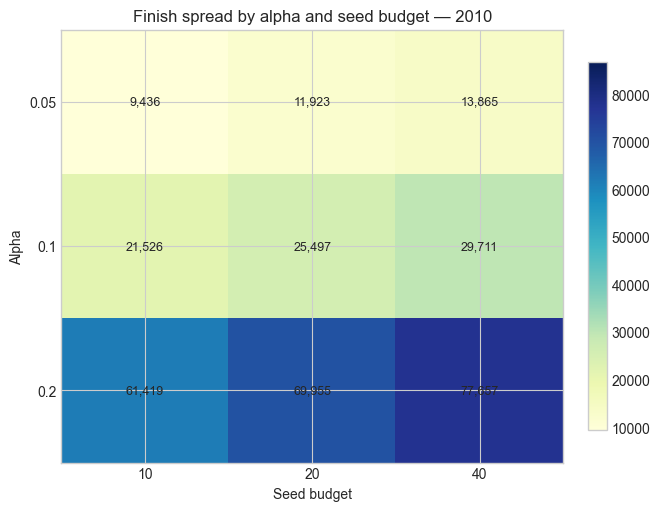

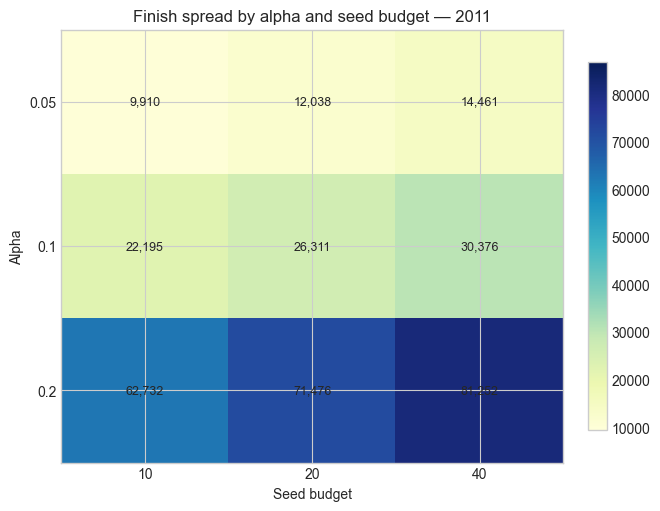

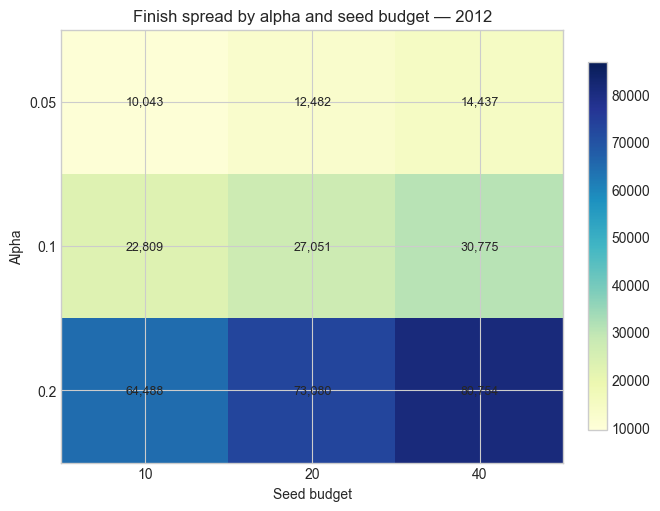

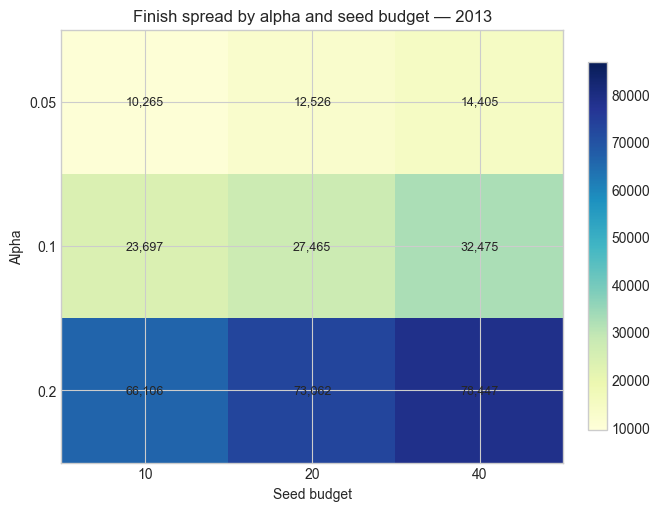

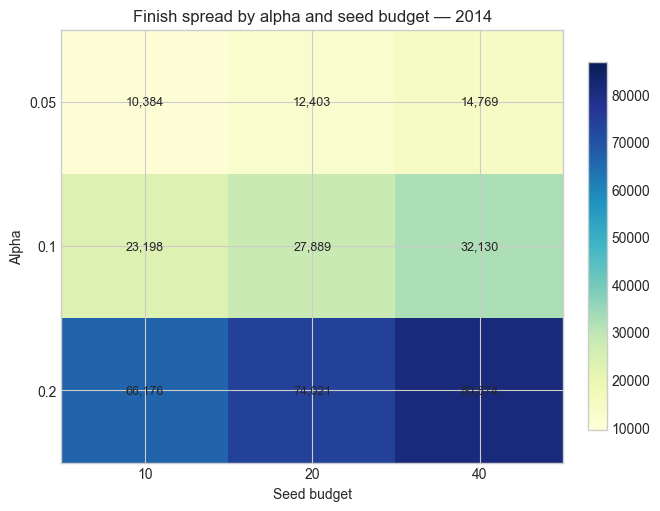

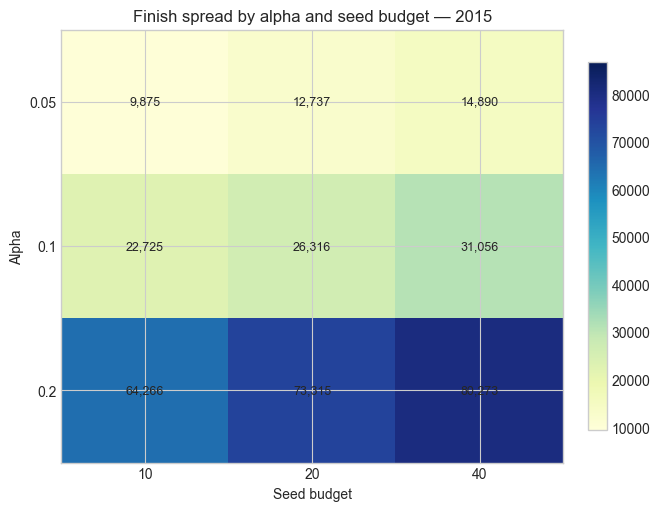

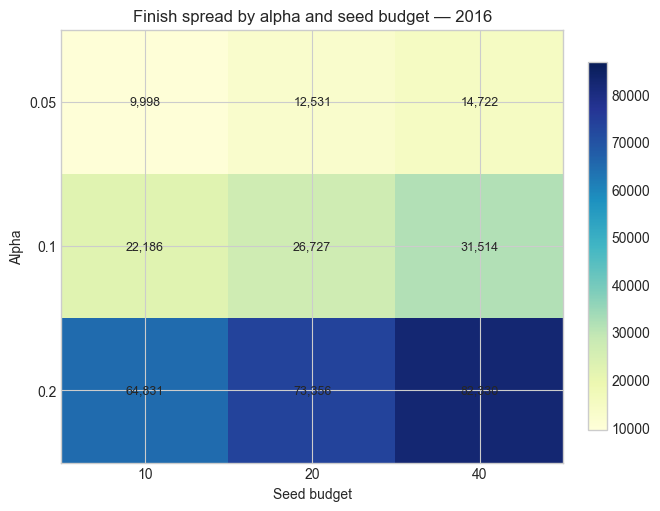

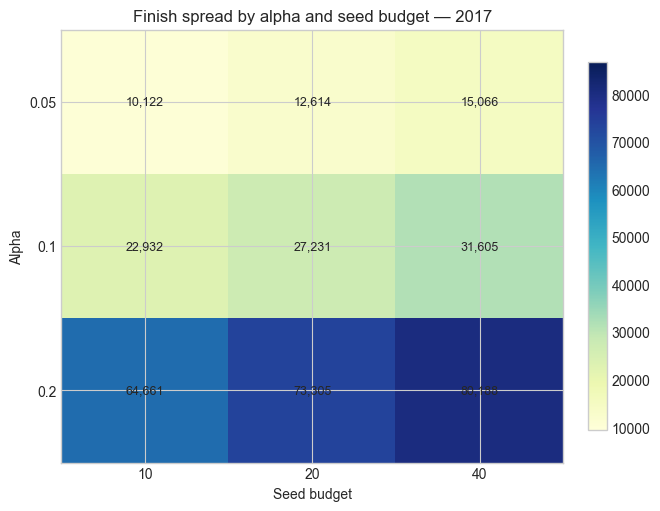

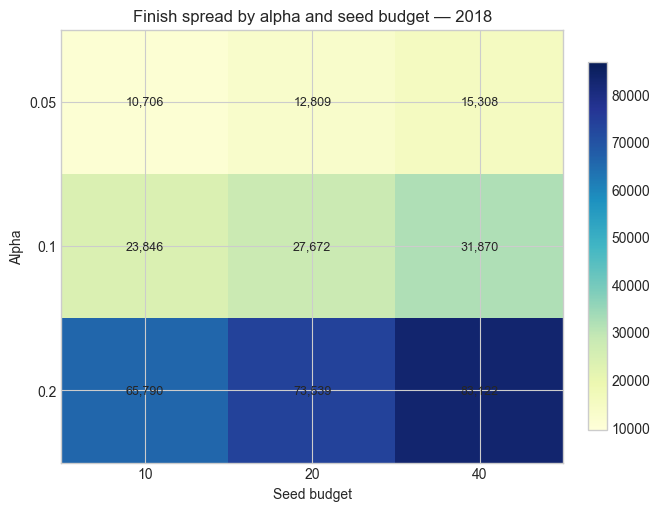

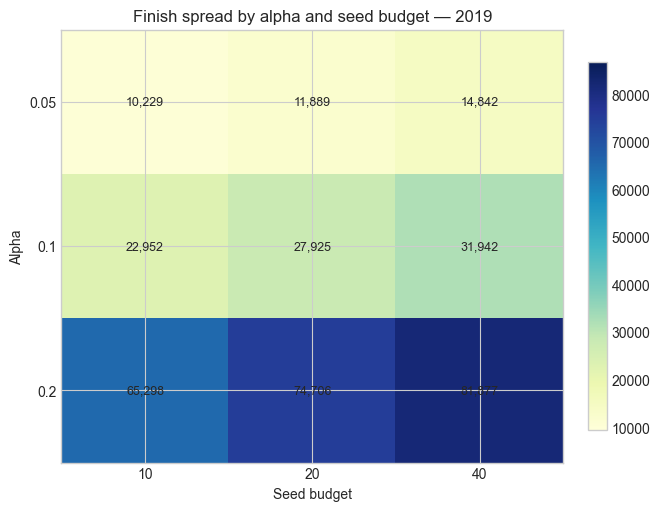

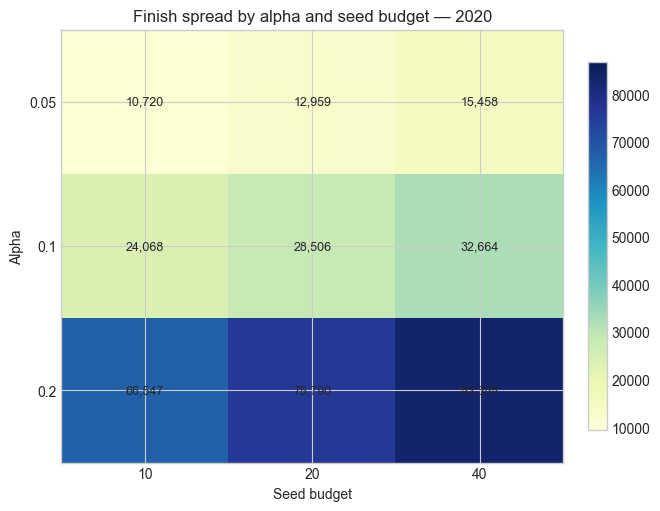

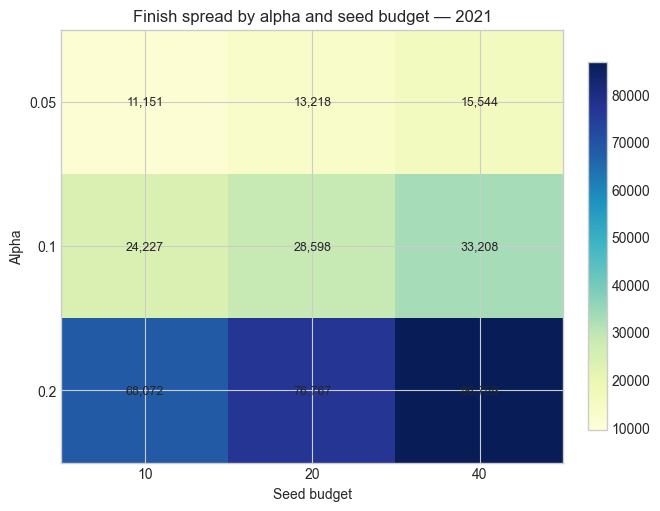

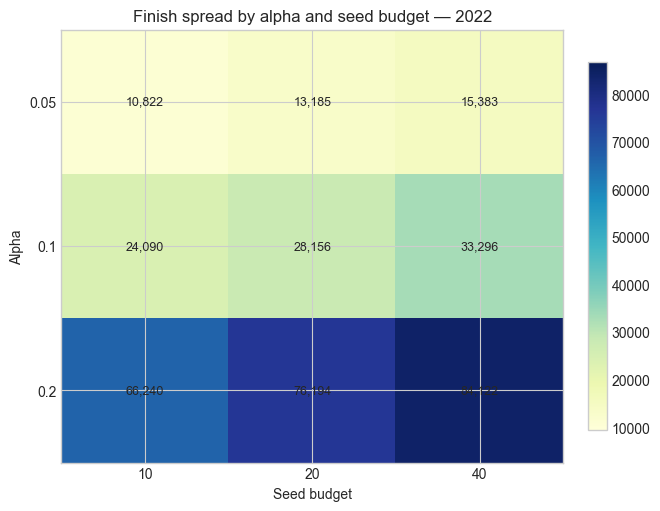

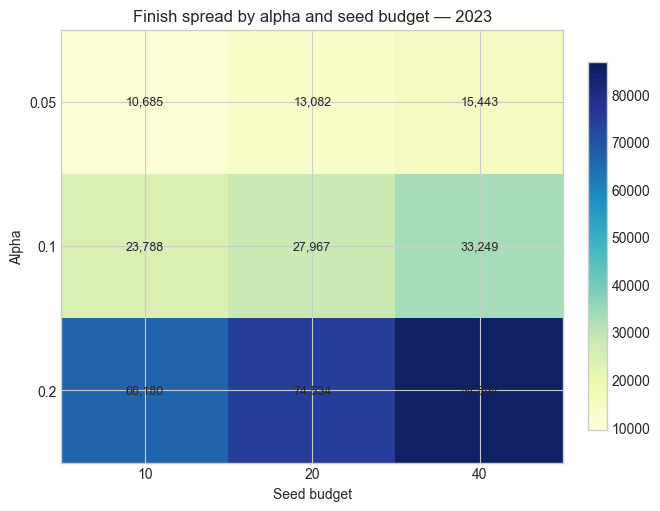

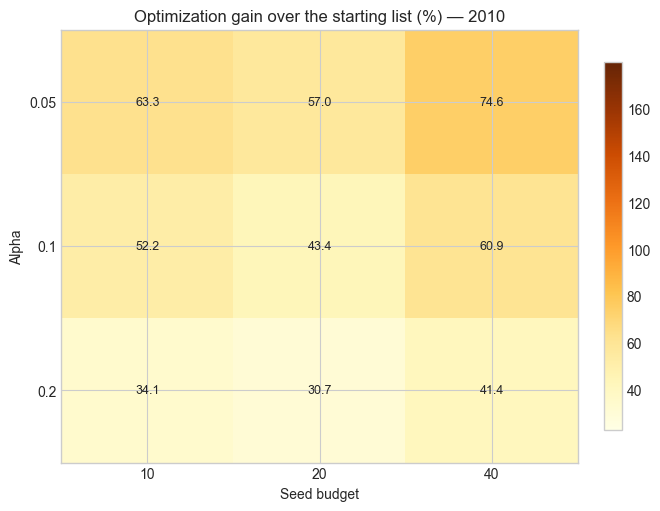

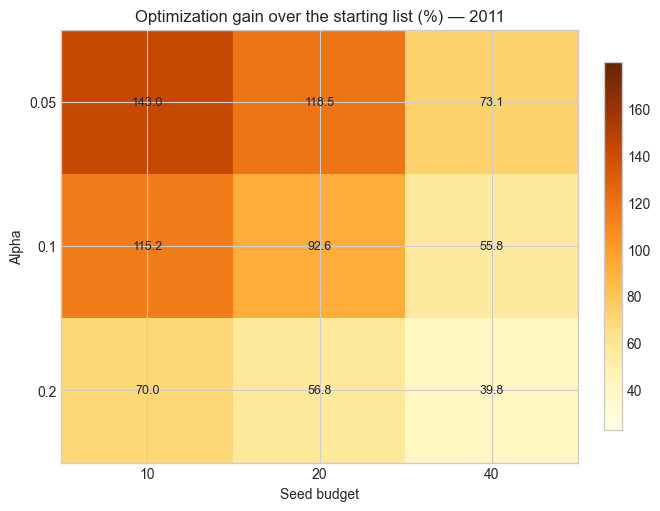

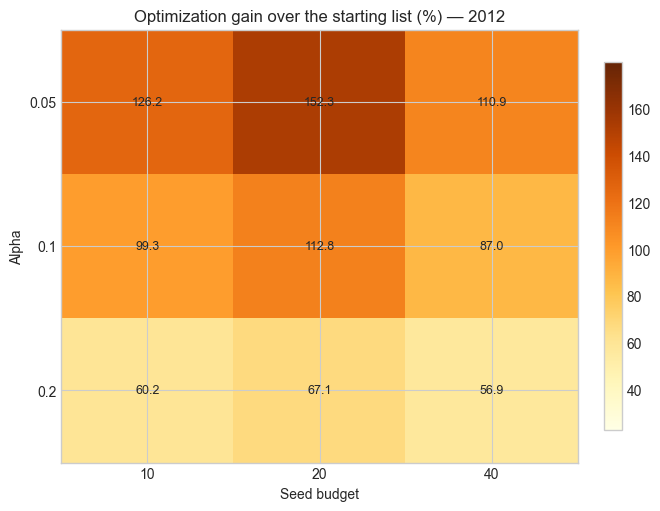

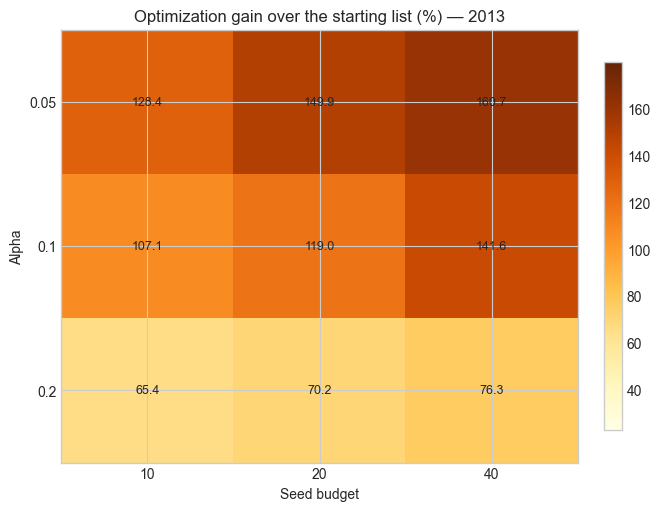

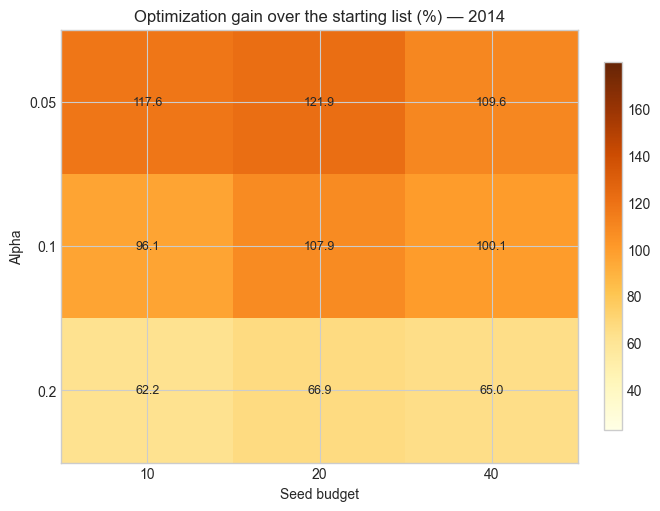

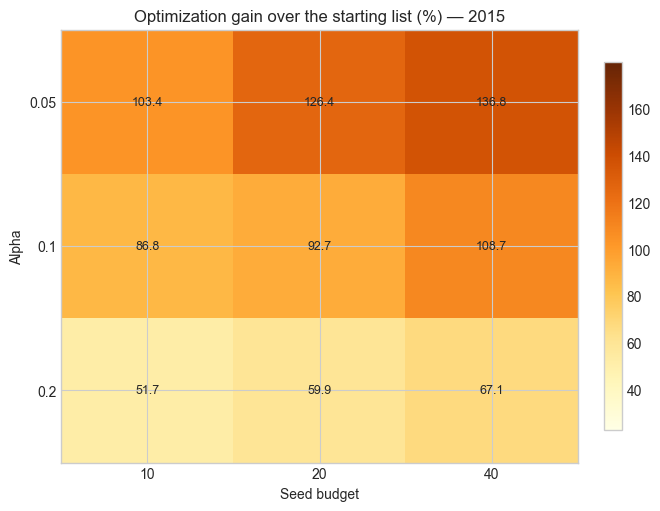

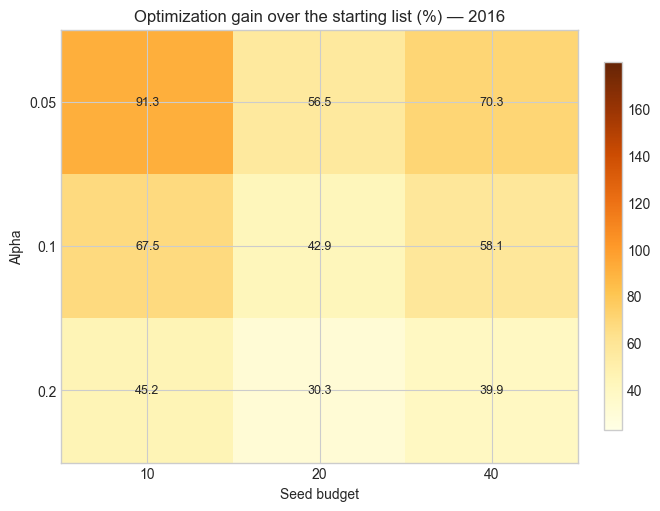

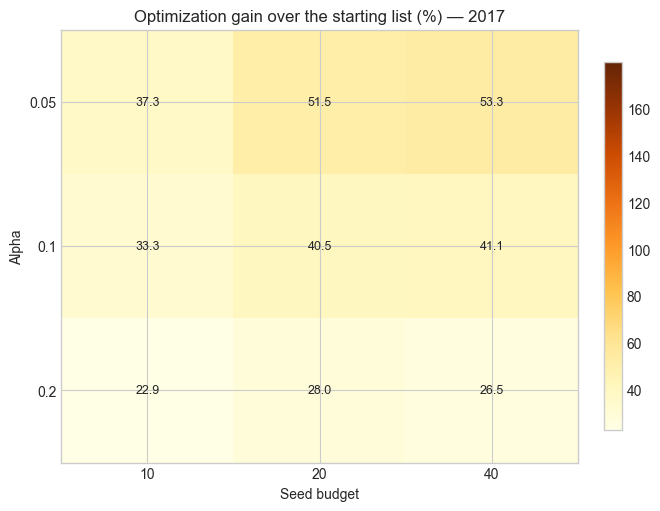

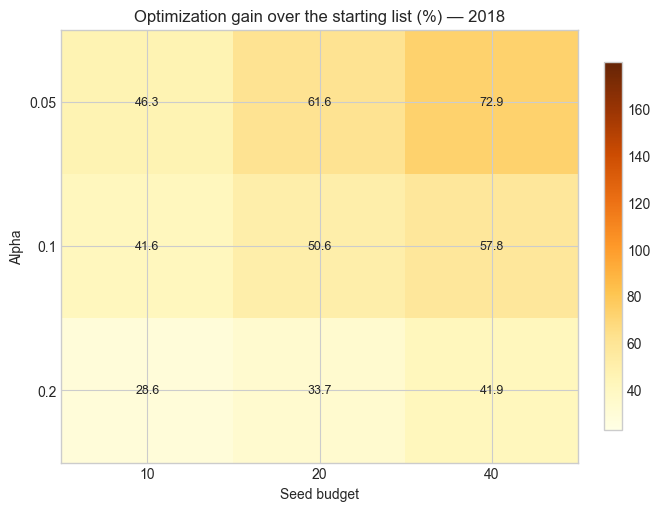

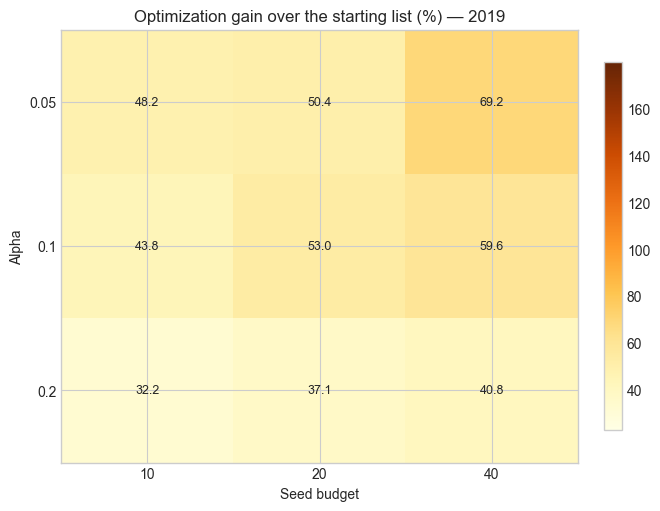

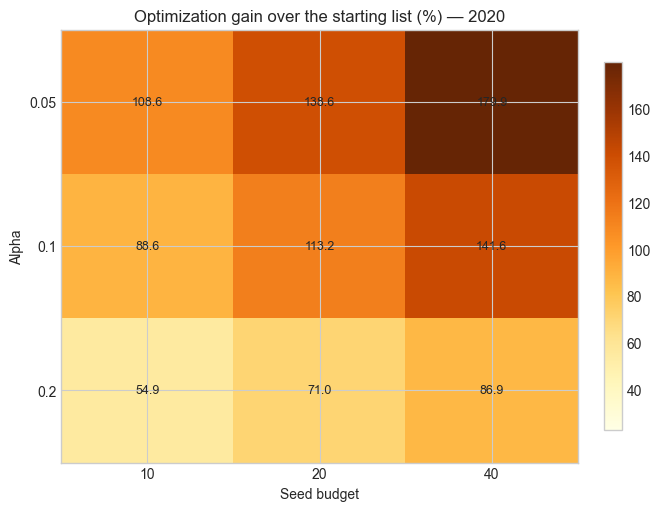

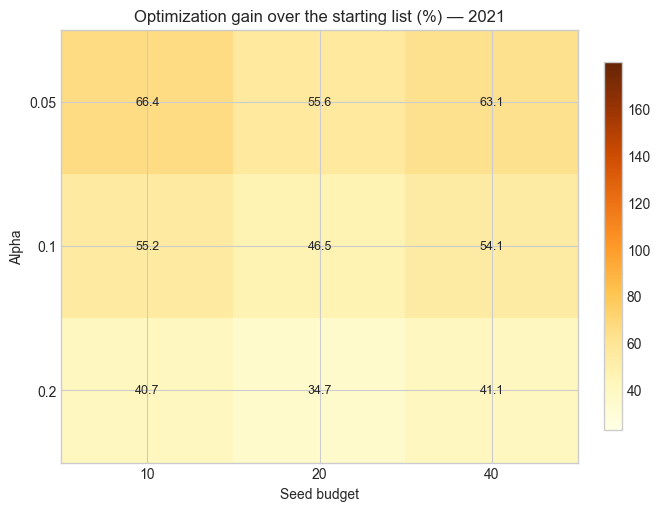

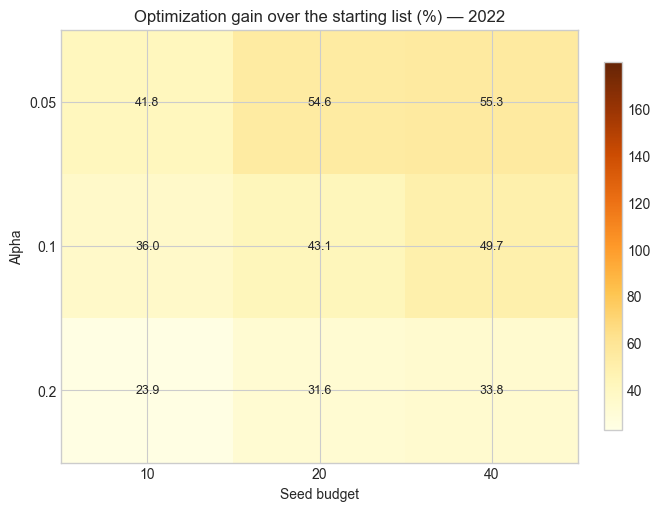

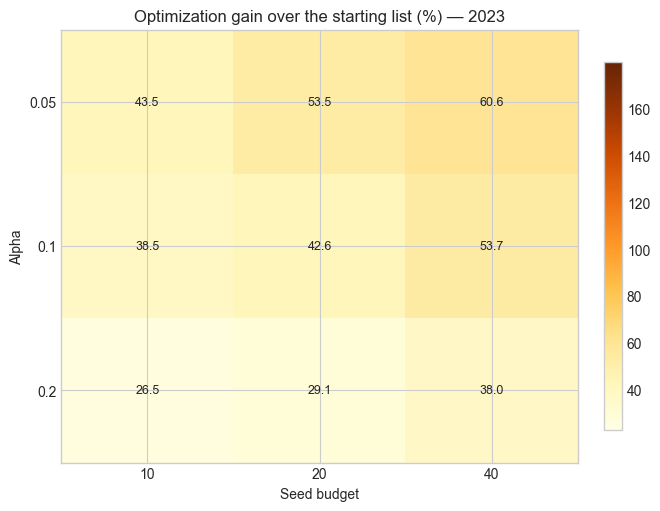

In [5]:
def parameter_heatmaps(metric: str, title: str, cmap: str, number_format: str) -> None:
    color_min = results[metric].min()
    color_max = results[metric].max()
    for year in YEARS:
        fig, axis = plt.subplots(figsize=(6.5, 5), constrained_layout=True)
        grid = (
            results.loc[results["year"].eq(year)]
            .pivot(index="alpha", columns="seed_budget", values=metric)
            .sort_index().sort_index(axis=1)
        )
        image = axis.imshow(grid.to_numpy(), aspect="auto", cmap=cmap, vmin=color_min, vmax=color_max)
        axis.set_xticks(np.arange(len(grid.columns)), labels=grid.columns)
        axis.set_yticks(np.arange(len(grid.index)), labels=grid.index)
        axis.set(xlabel="Seed budget", ylabel="Alpha", title=f"{title} — {year}")
        for row_index in range(len(grid.index)):
            for column_index in range(len(grid.columns)):
                value = grid.iloc[row_index, column_index]
                if pd.notna(value):
                    axis.text(column_index, row_index, format(value, number_format), ha="center", va="center", fontsize=9)
        fig.colorbar(image, ax=axis, shrink=0.85)
        plt.show()

parameter_heatmaps("finish_spread", "Finish spread by alpha and seed budget", "YlGnBu", ",.0f")
parameter_heatmaps("spread_gain_pct", "Optimization gain over the starting list (%)", "YlOrBr", ".1f")


### Hyperparameter effects and interactions

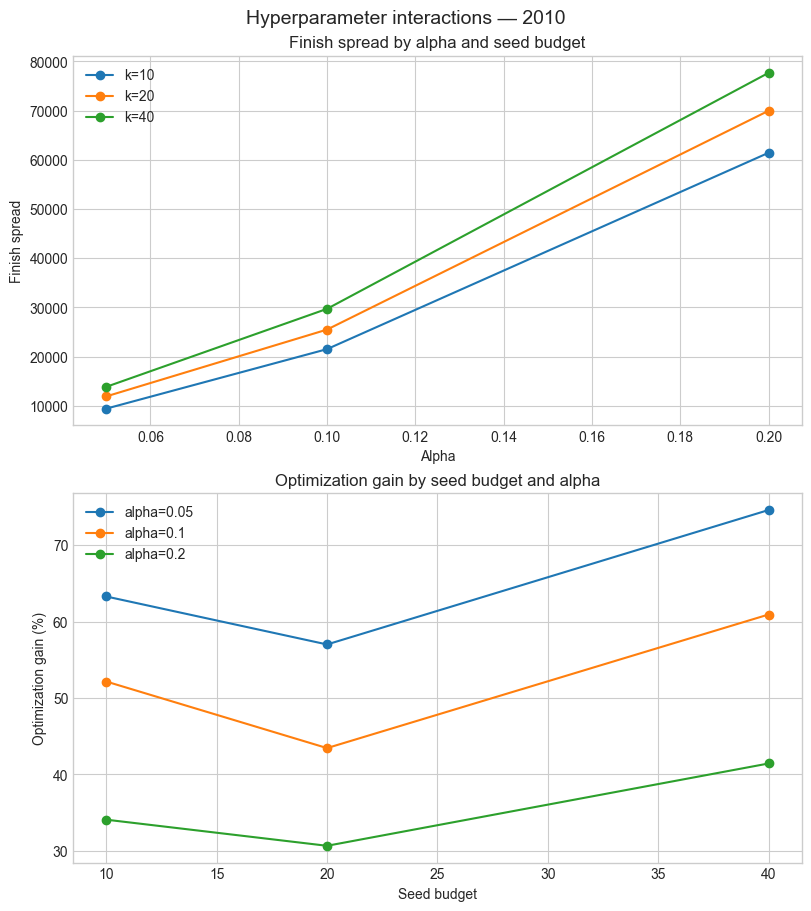

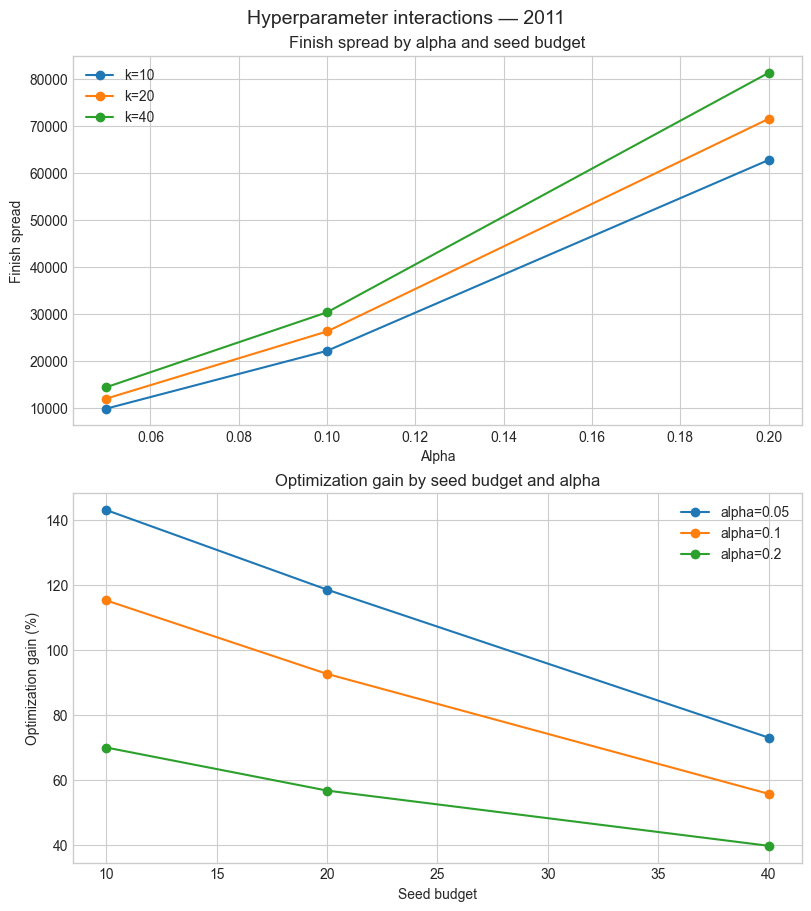

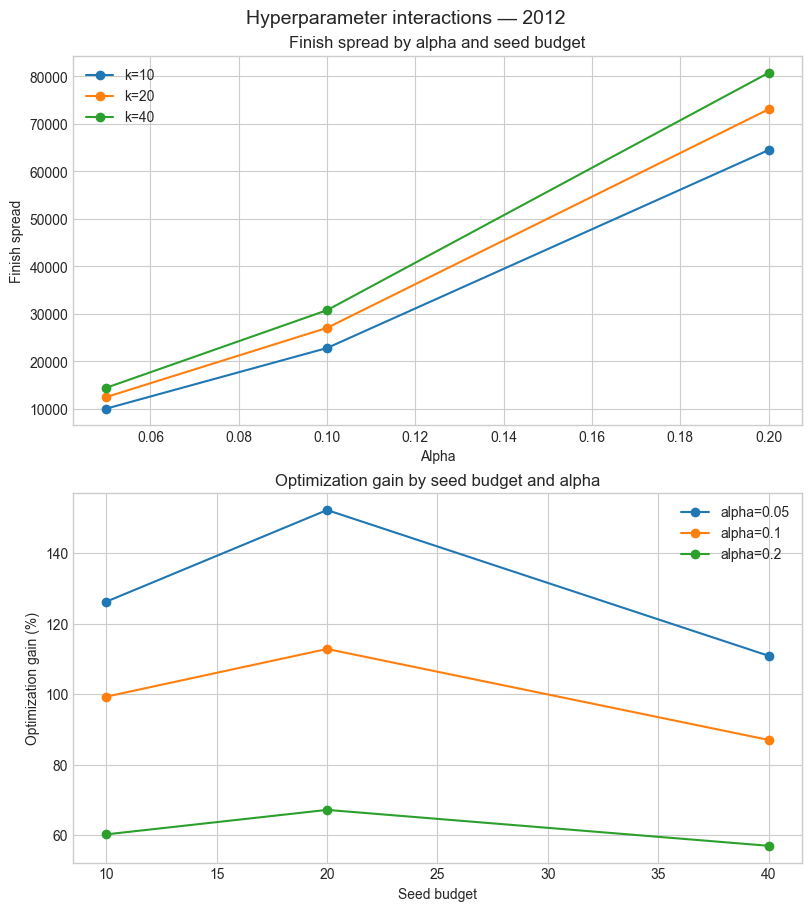

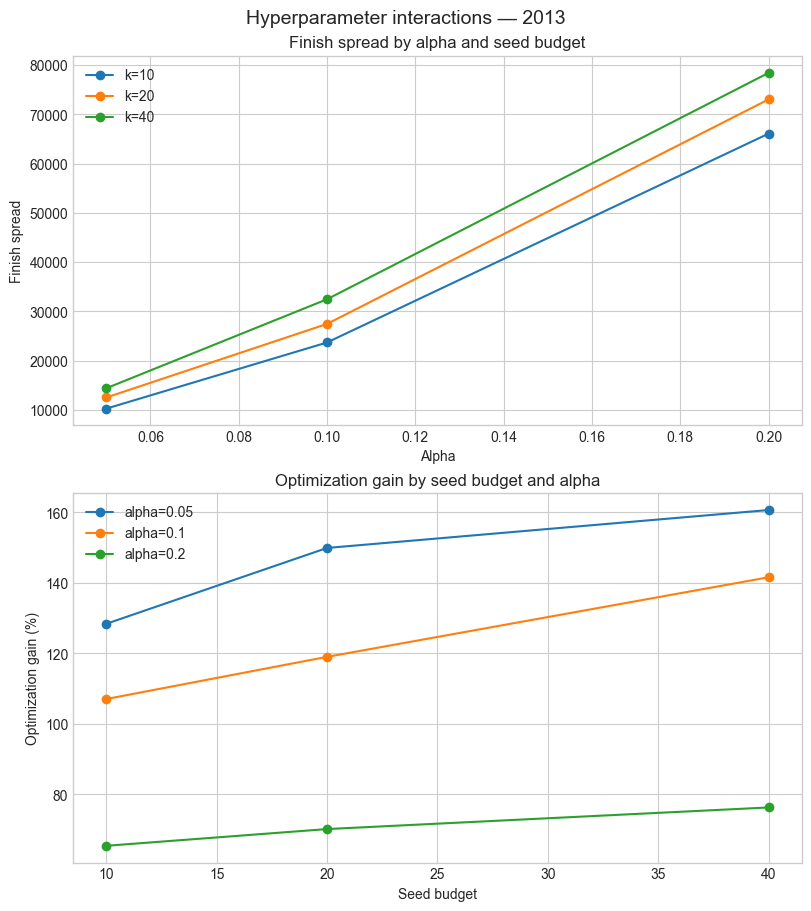

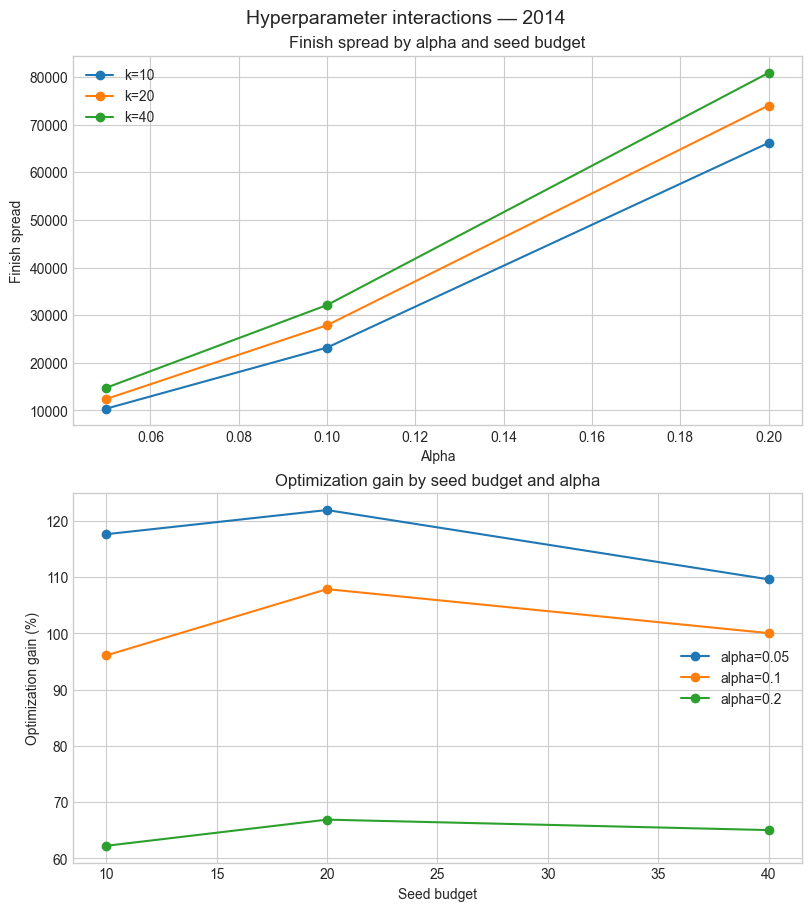

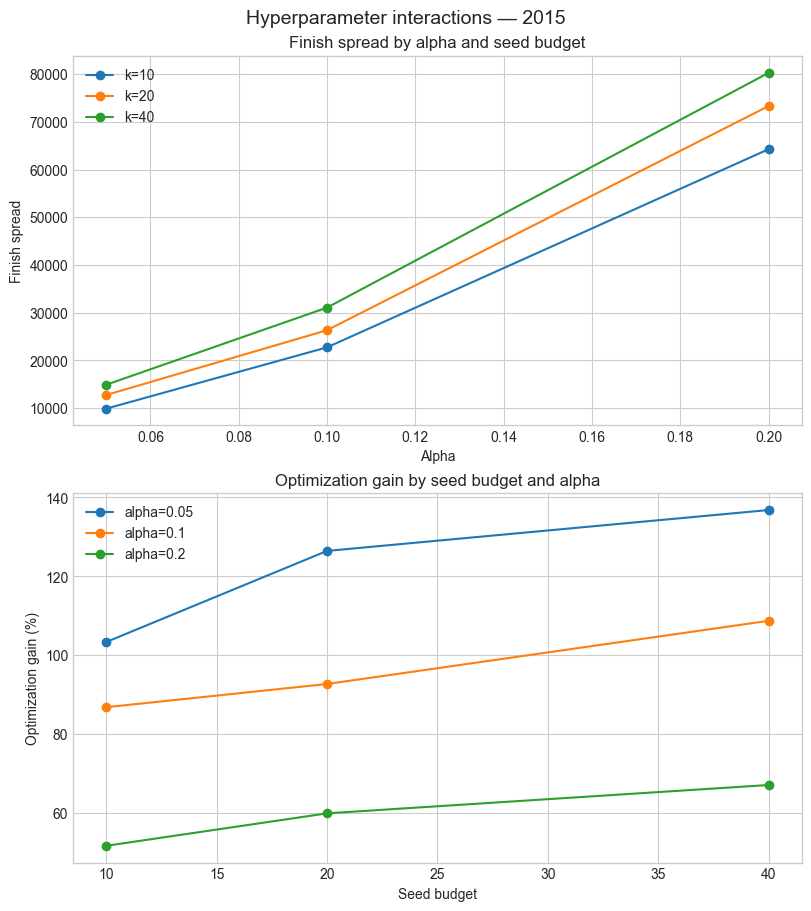

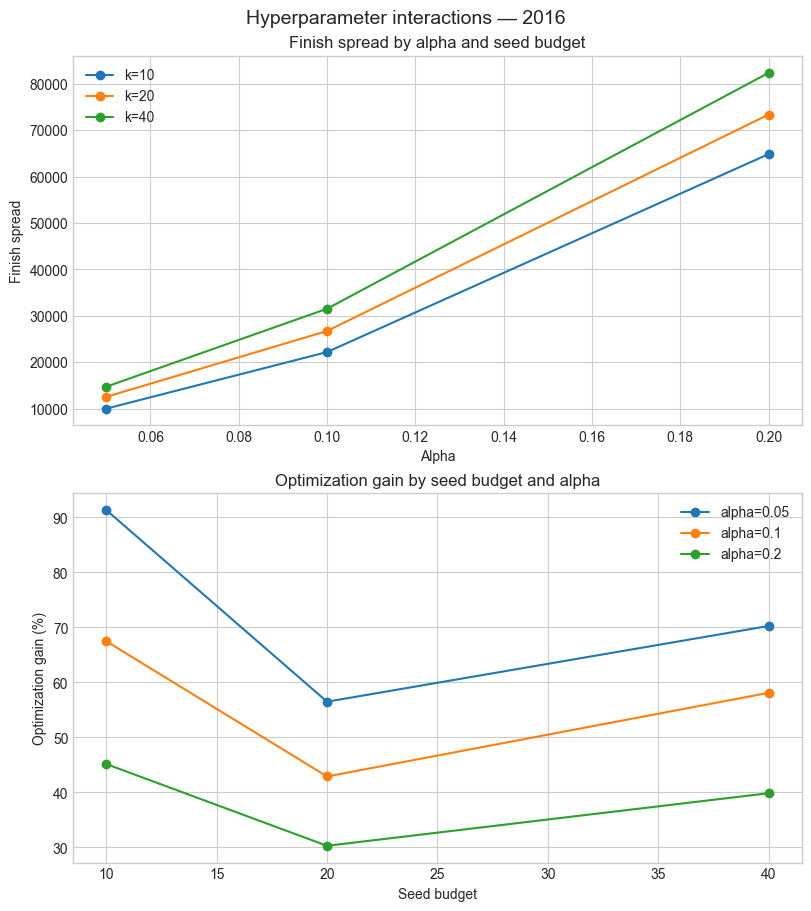

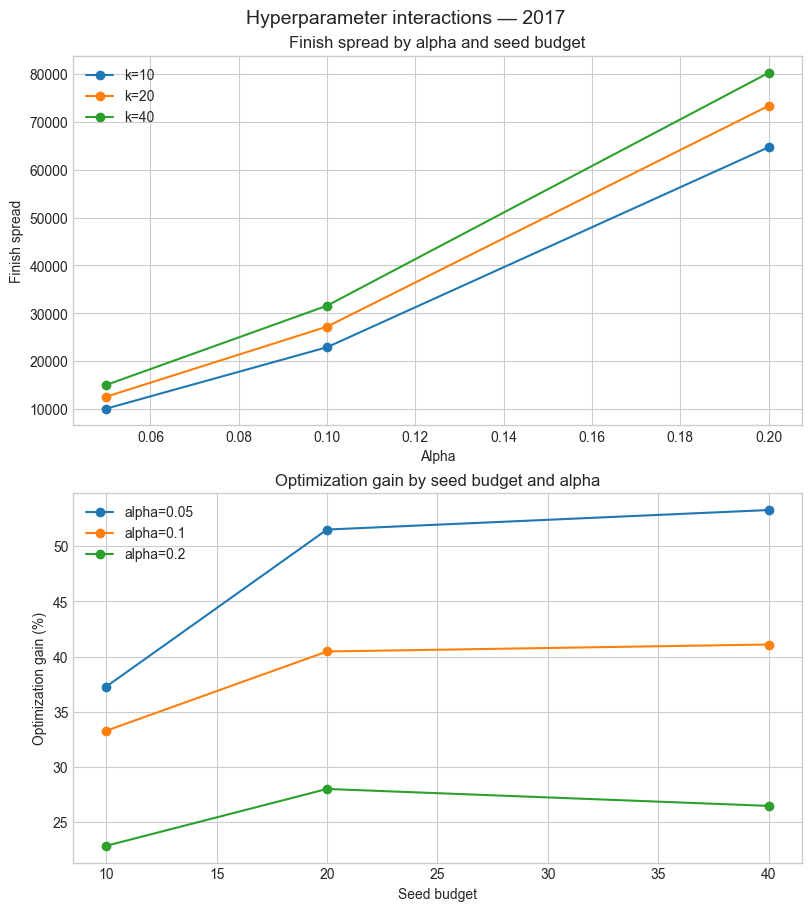

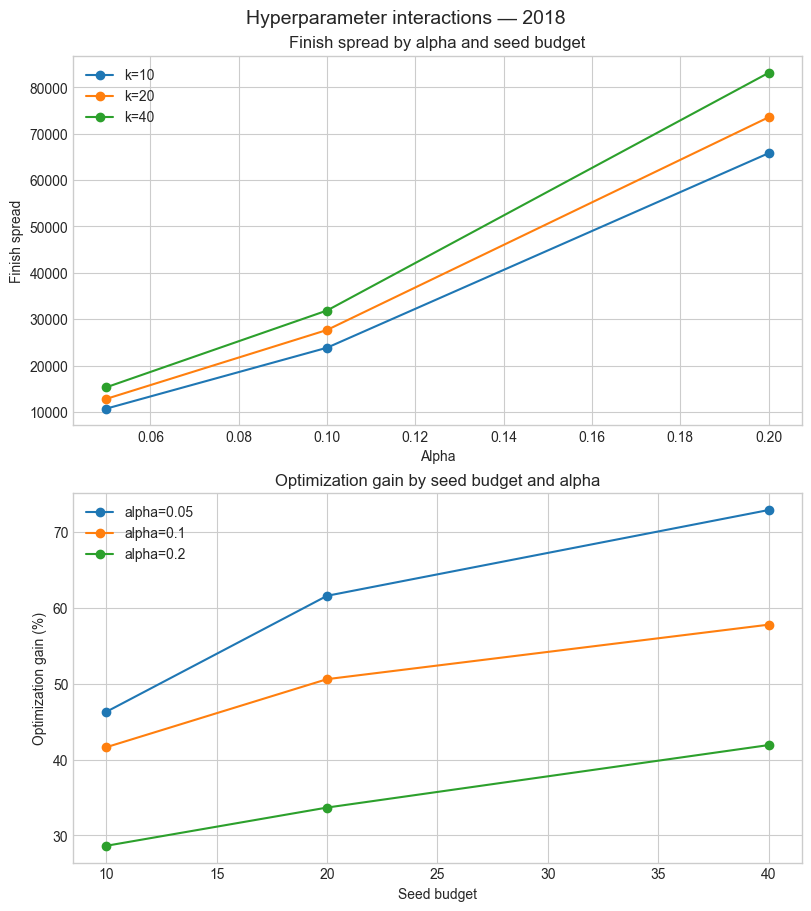

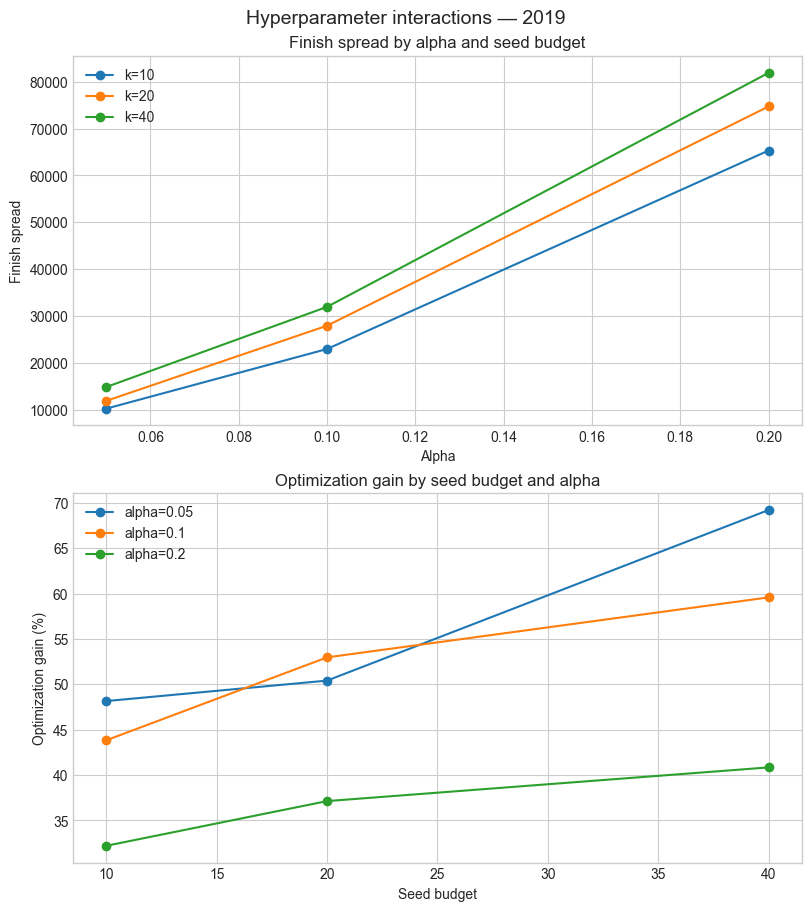

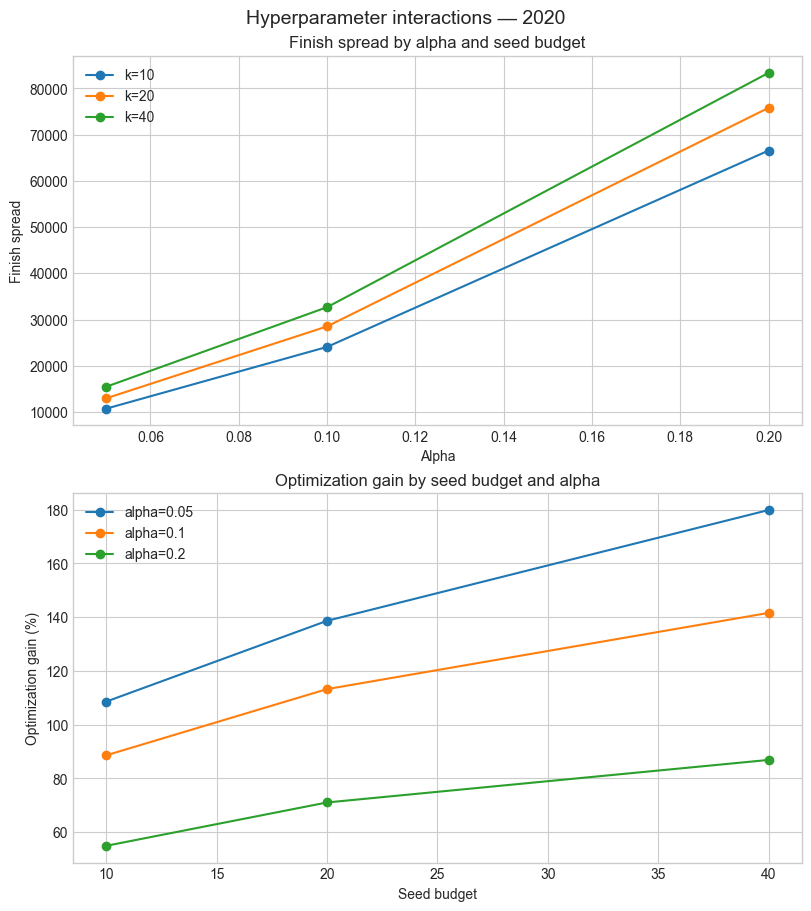

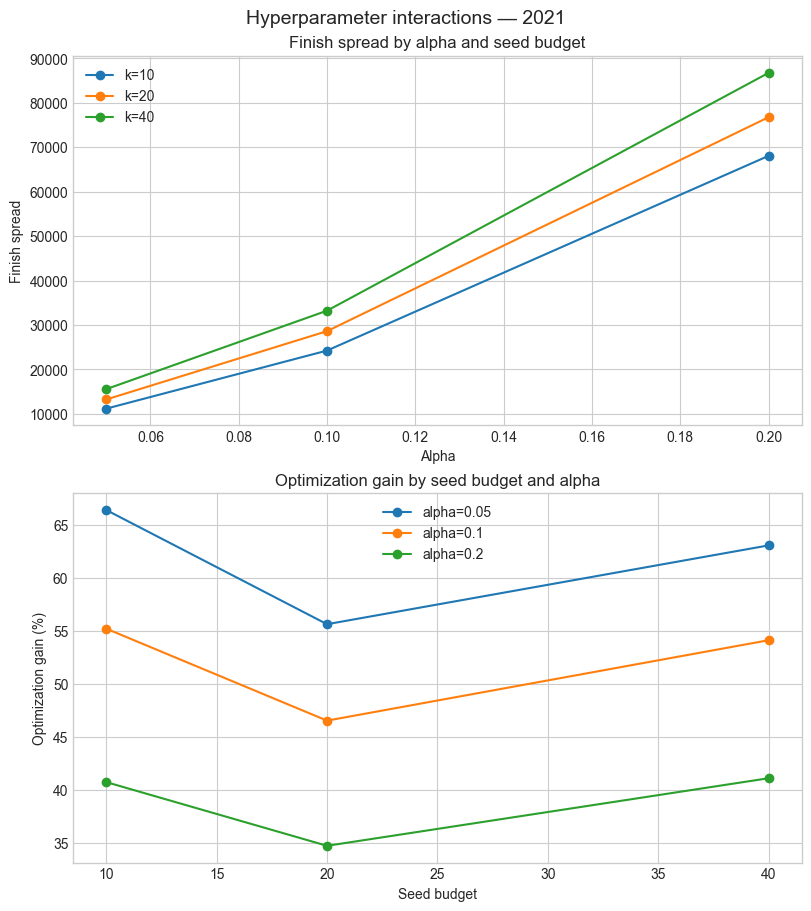

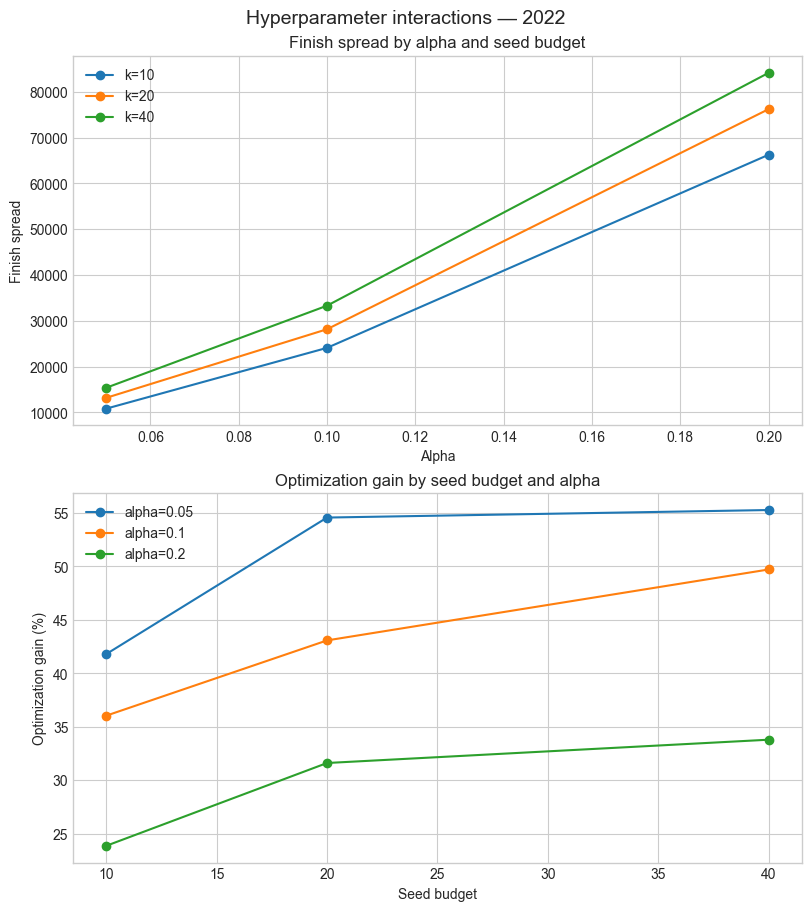

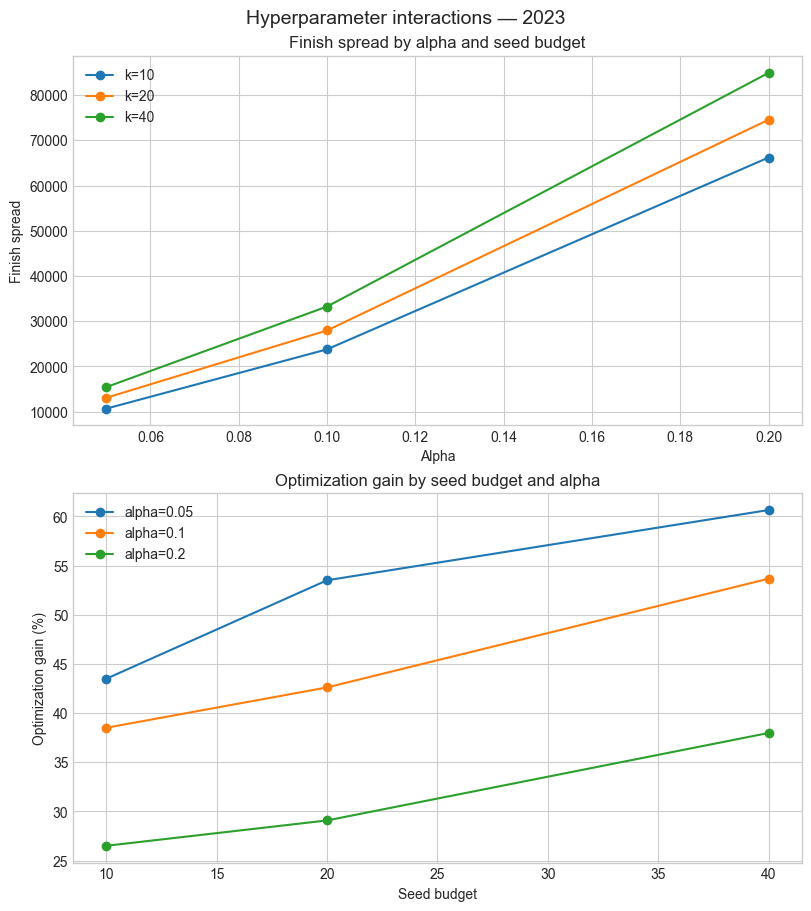

In [6]:
for year in YEARS:
    fig, axes = plt.subplots(2, 1, figsize=(8, 9), constrained_layout=True)
    year_data = results.loc[results["year"].eq(year)]
    for budget, group in year_data.groupby("seed_budget"):
        group = group.sort_values("alpha")
        axes[0].plot(group["alpha"], group["finish_spread"], marker="o", label=f"k={budget}")
    for alpha, group in year_data.groupby("alpha"):
        group = group.sort_values("seed_budget")
        axes[1].plot(group["seed_budget"], group["spread_gain_pct"], marker="o", label=f"alpha={alpha:g}")
    axes[0].set(xlabel="Alpha", ylabel="Finish spread", title="Finish spread by alpha and seed budget")
    axes[1].set(xlabel="Seed budget", ylabel="Optimization gain (%)", title="Optimization gain by seed budget and alpha")
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(f"Hyperparameter interactions — {year}", fontsize=14)
    plt.show()

In [7]:
alpha_effect_rows = []
for (year, budget), group in results.groupby(["year", "seed_budget"]):
    ordered = group.sort_values("alpha")
    low, high = ordered.iloc[0], ordered.iloc[-1]
    alpha_effect_rows.append({
        "year": year,
        "seed_budget": budget,
        "alpha_low": low["alpha"],
        "alpha_high": high["alpha"],
        "finish_spread_change": high["finish_spread"] - low["finish_spread"],
        "finish_spread_change_pct": 100 * (high["finish_spread"] / low["finish_spread"] - 1),
        "optimization_gain_change_pp": high["spread_gain_pct"] - low["spread_gain_pct"],
    })

budget_effect_rows = []
for (year, alpha), group in results.groupby(["year", "alpha"]):
    ordered = group.sort_values("seed_budget")
    low, high = ordered.iloc[0], ordered.iloc[-1]
    budget_effect_rows.append({
        "year": year,
        "alpha": alpha,
        "budget_low": int(low["seed_budget"]),
        "budget_high": int(high["seed_budget"]),
        "finish_spread_change": high["finish_spread"] - low["finish_spread"],
        "finish_spread_change_pct": 100 * (high["finish_spread"] / low["finish_spread"] - 1),
        "optimization_gain_change_pp": high["spread_gain_pct"] - low["spread_gain_pct"],
    })

display(Markdown("### Change from the lowest to highest alpha, holding year and seed budget fixed"))
display(pd.DataFrame(alpha_effect_rows))
display(Markdown("### Change from the smallest to largest seed budget, holding year and alpha fixed"))
display(pd.DataFrame(budget_effect_rows))

### Change from the lowest to highest alpha, holding year and seed budget fixed

,year,seed_budget,alpha_low,alpha_high,finish_spread_change,finish_spread_change_pct,optimization_gain_change_pp
0,2010,10,0.050,0.200,"51,982.920",550.898,-29.202
1,2010,20,0.050,0.200,"58,032.537",486.739,-26.342
2,2010,40,0.050,0.200,"63,791.999",460.099,-33.161
3,2011,10,0.050,0.200,"52,821.703",532.998,-72.950
4,2011,20,0.050,0.200,"59,437.877",493.741,-61.726
5,2011,40,0.050,0.200,"66,790.310",461.851,-33.242
6,2012,10,0.050,0.200,"54,445.273",542.133,-66.070
7,2012,20,0.050,0.200,"60,598.101",485.473,-85.137
8,2012,40,0.050,0.200,"66,317.088",459.347,-53.955
9,2013,10,0.050,0.200,"55,841.212",543.999,-62.990


### Change from the smallest to largest seed budget, holding year and alpha fixed

,year,alpha,budget_low,budget_high,finish_spread_change,finish_spread_change_pct,optimization_gain_change_pp
0,2010,0.050,10,40,"4,428.795",46.935,11.311
1,2010,0.100,10,40,"8,184.617",38.022,8.767
2,2010,0.200,10,40,"16,237.874",26.438,7.352
3,2011,0.050,10,40,"4,551.151",45.923,-69.899
4,2011,0.100,10,40,"8,180.597",36.857,-59.401
5,2011,0.200,10,40,"18,519.758",29.522,-30.191
6,2012,0.050,10,40,"4,394.482",43.758,-15.359
7,2012,0.100,10,40,"7,966.536",34.928,-12.278
8,2012,0.200,10,40,"16,266.297",25.224,-3.244
9,2013,0.050,10,40,"4,139.847",40.330,32.280


### Mean influence over time

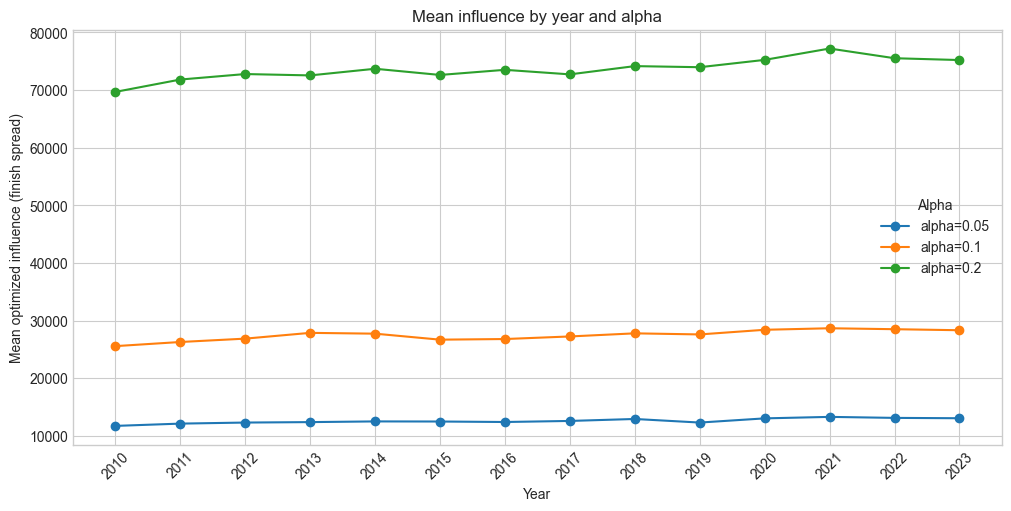

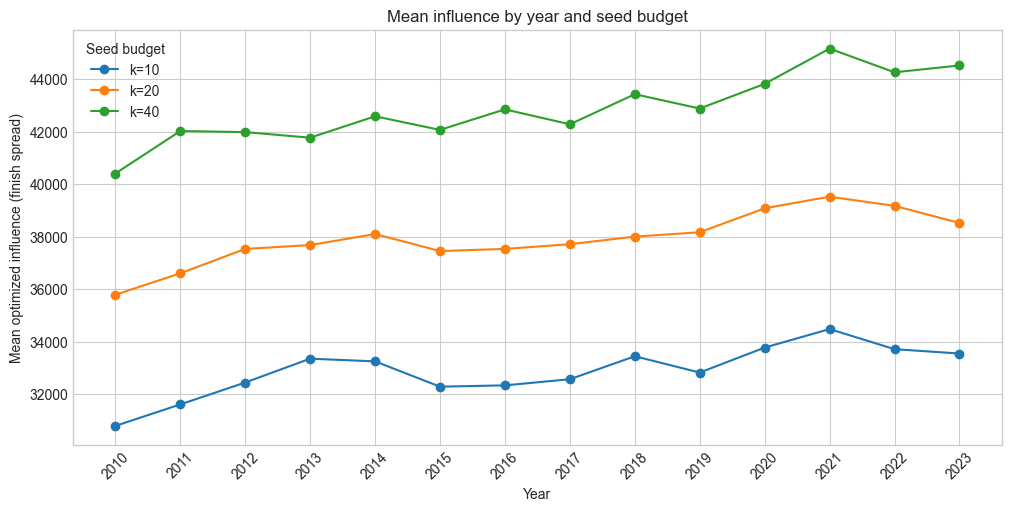

In [8]:
mean_influence_by_alpha = (
    results.groupby(["year", "alpha"], as_index=False)["finish_spread"]
    .mean()
    .rename(columns={"finish_spread": "mean_influence"})
)
mean_influence_by_budget = (
    results.groupby(["year", "seed_budget"], as_index=False)["finish_spread"]
    .mean()
    .rename(columns={"finish_spread": "mean_influence"})
)

fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
for alpha, group in mean_influence_by_alpha.groupby("alpha"):
    group = group.sort_values("year")
    axis.plot(group["year"], group["mean_influence"], marker="o", label=f"alpha={alpha:g}")
axis.set(xlabel="Year", ylabel="Mean optimized influence (finish spread)", title="Mean influence by year and alpha")
axis.set_xticks(YEARS)
axis.tick_params(axis="x", rotation=45)
axis.legend(title="Alpha")
plt.show()

fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
for budget, group in mean_influence_by_budget.groupby("seed_budget"):
    group = group.sort_values("year")
    axis.plot(group["year"], group["mean_influence"], marker="o", label=f"k={int(budget)}")
axis.set(xlabel="Year", ylabel="Mean optimized influence (finish spread)", title="Mean influence by year and seed budget")
axis.set_xticks(YEARS)
axis.tick_params(axis="x", rotation=45)
axis.legend(title="Seed budget")
plt.show()


In [9]:
display(mean_influence_by_alpha.pivot(index="year", columns="alpha", values="mean_influence"))
display(mean_influence_by_budget.pivot(index="year", columns="seed_budget", values="mean_influence"))

alpha,0.050,0.100,0.200
year,,,
2010,"11,741.195","25,577.985","69,677.014"
2011,"12,136.672","26,294.047","71,819.969"
2012,"12,320.775","26,878.257","72,774.262"
2013,"12,398.513","27,878.874","72,538.180"
2014,"12,518.805","27,738.805","73,690.634"
2015,"12,500.896","26,699.197","72,617.616"
2016,"12,416.778","26,808.974","73,505.835"
2017,"12,600.705","27,255.899","72,717.897"
2018,"12,941.059","27,795.997","74,150.303"


seed_budget,10,20,40
year,,,
2010,"30,793.720","35,791.659","40,410.815"
2011,"31,612.549","36,608.422","42,029.718"
2012,"32,446.516","37,537.825","41,988.954"
2013,"33,355.991","37,683.962","41,775.613"
2014,"33,252.489","38,104.565","42,591.189"
2015,"32,288.754","37,456.055","42,072.901"
2016,"32,338.251","37,537.884","42,855.452"
2017,"32,571.900","37,716.397","42,286.205"
2018,"33,447.389","38,006.649","43,433.321"


### Objective-call totals

,year,alpha,seed_budget,search_objective_calls,search_elapsed_seconds,search_restarts,calls_per_second
0,2010,0.050,10,90616,300.002,2,302.052
1,2010,0.050,20,89515,300.003,1,298.381
2,2010,0.050,40,86191,300.005,1,287.299
3,2010,0.100,10,74074,300.000,3,246.913
4,2010,0.100,20,69338,300.005,1,231.123
...,...,...,...,...,...,...,...
121,2023,0.100,20,93776,300.004,2,312.583
122,2023,0.100,40,89752,300.003,2,299.170
123,2023,0.200,10,60982,300.004,2,203.270
124,2023,0.200,20,61311,300.003,2,204.368


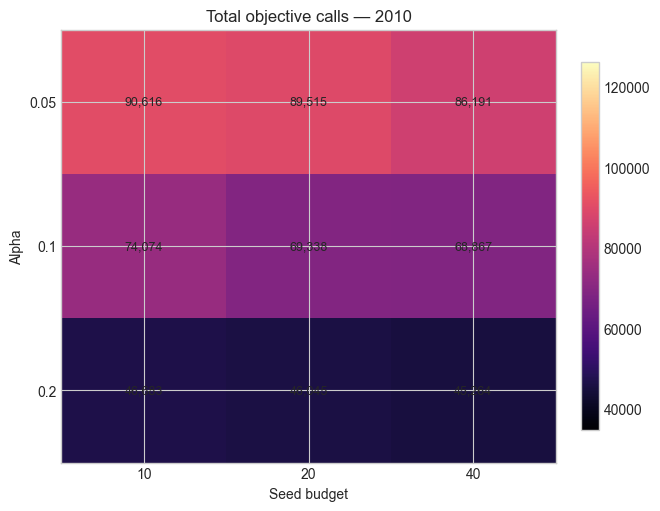

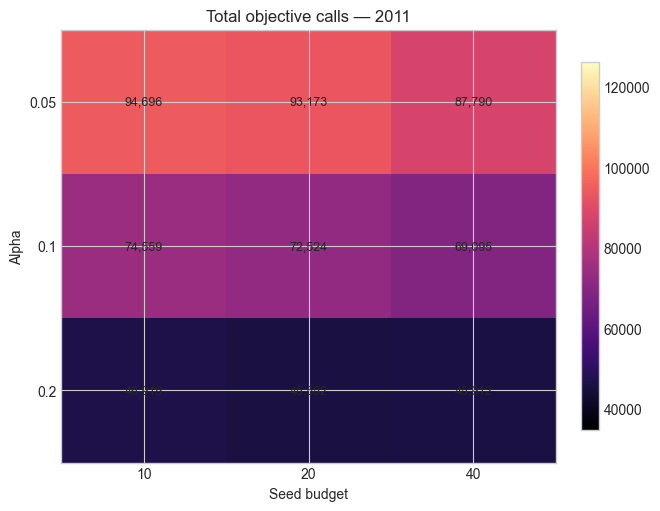

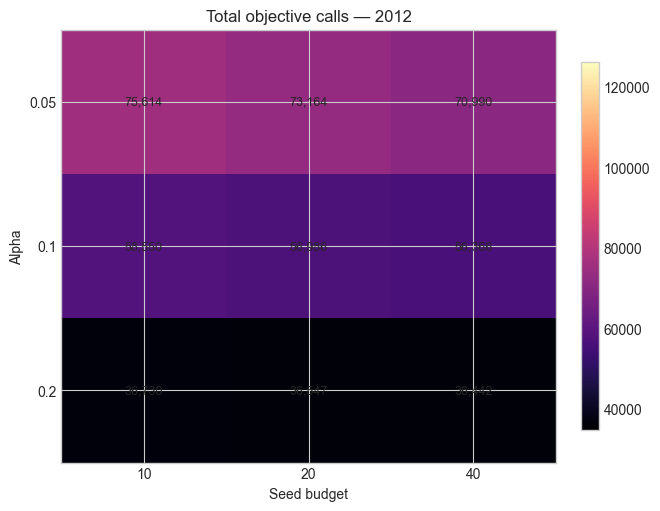

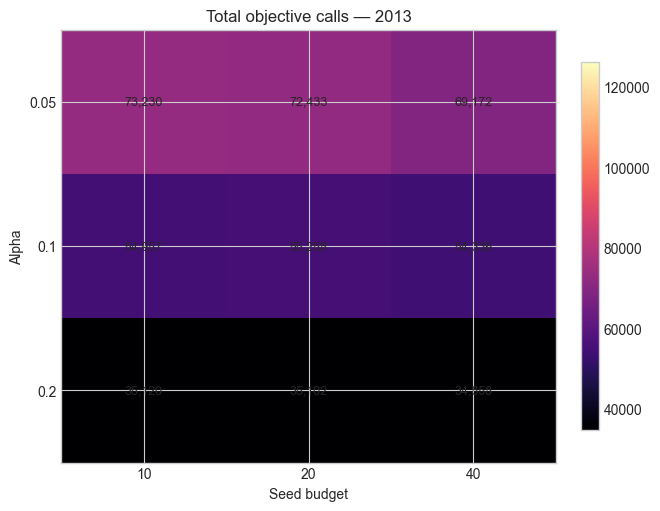

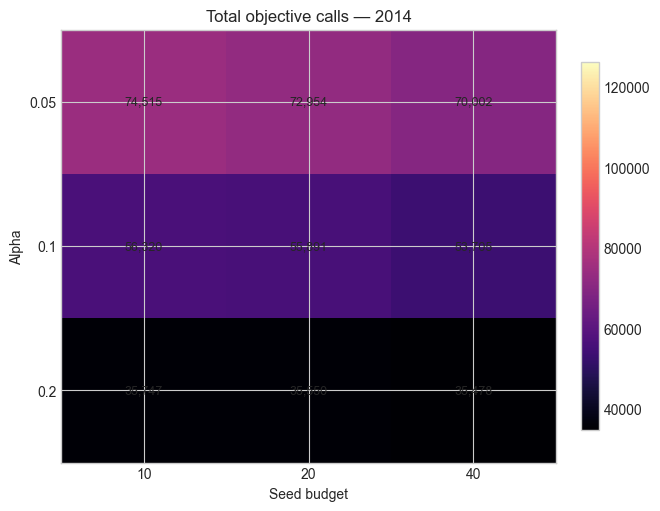

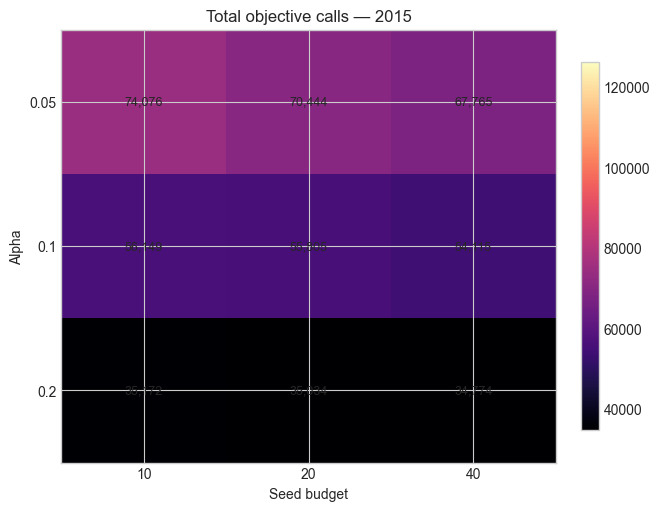

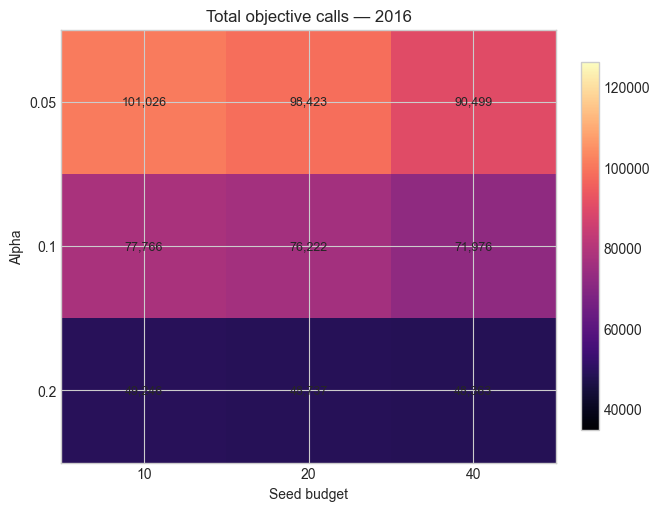

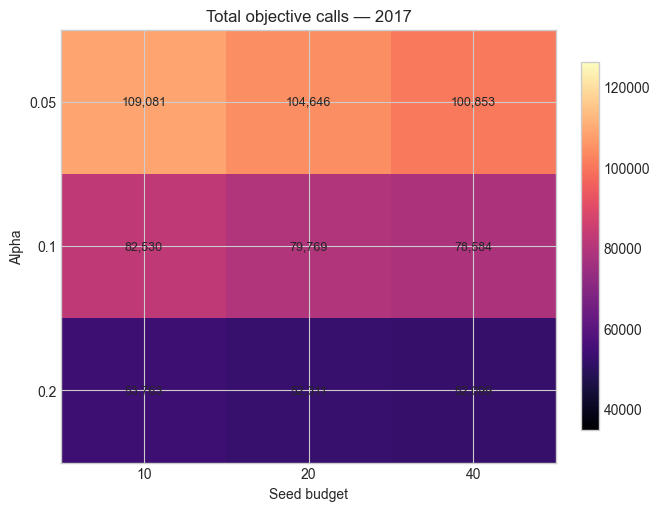

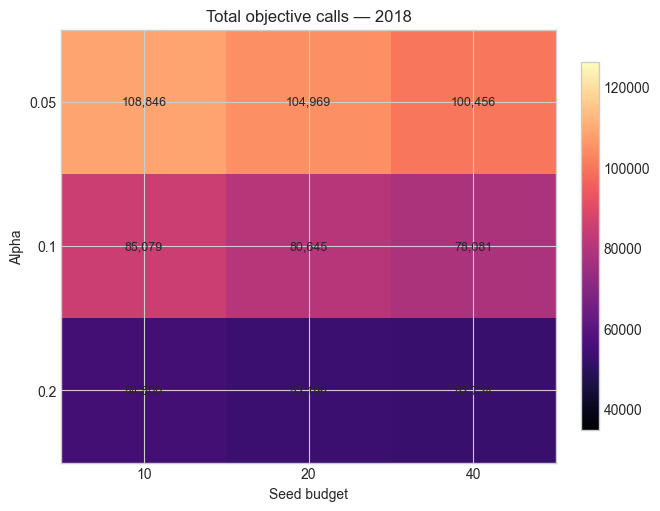

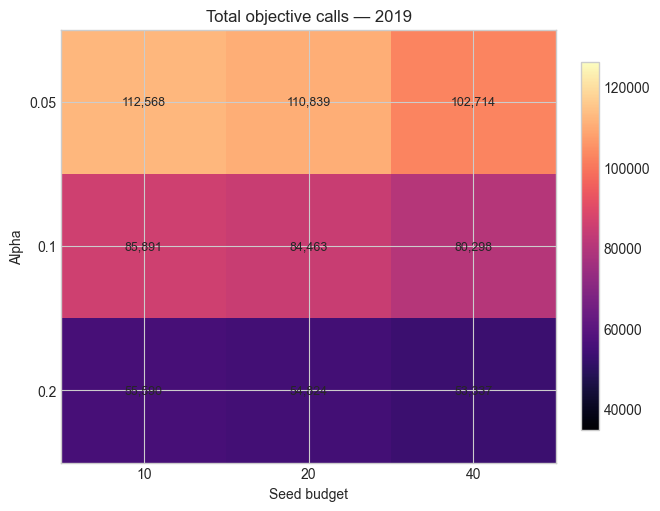

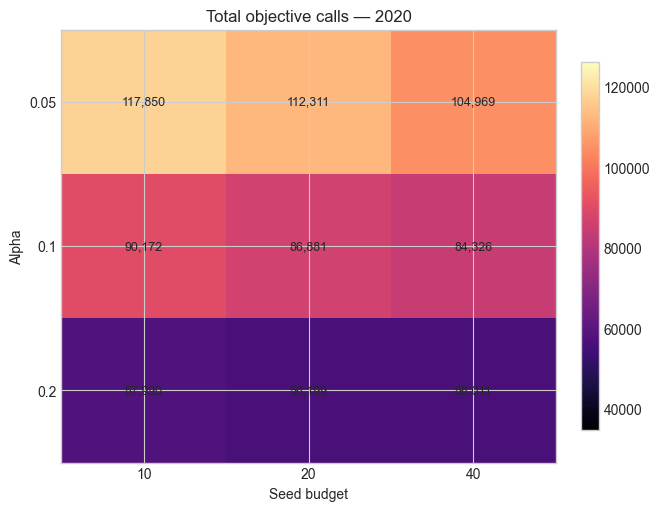

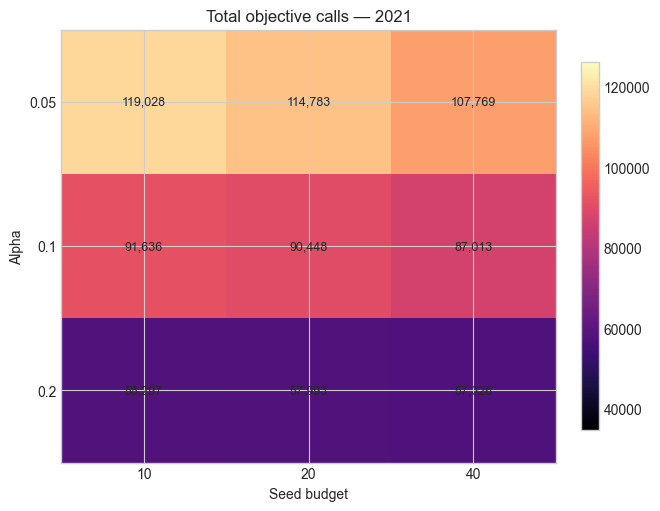

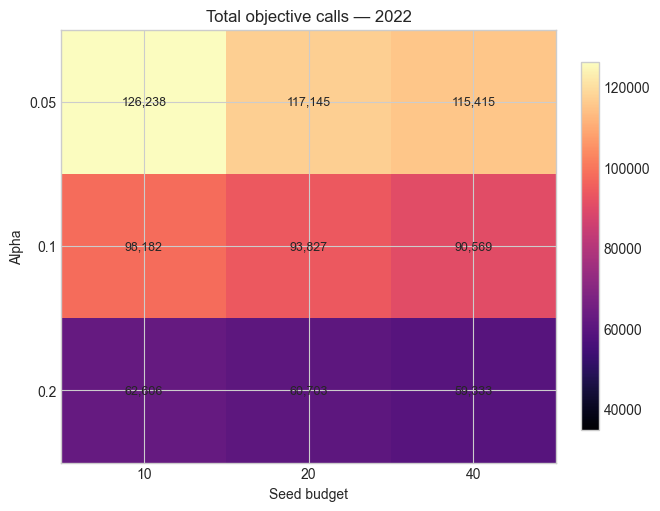

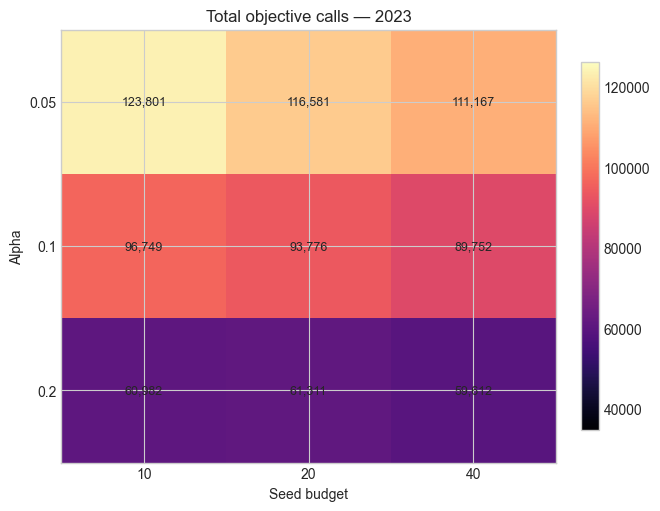

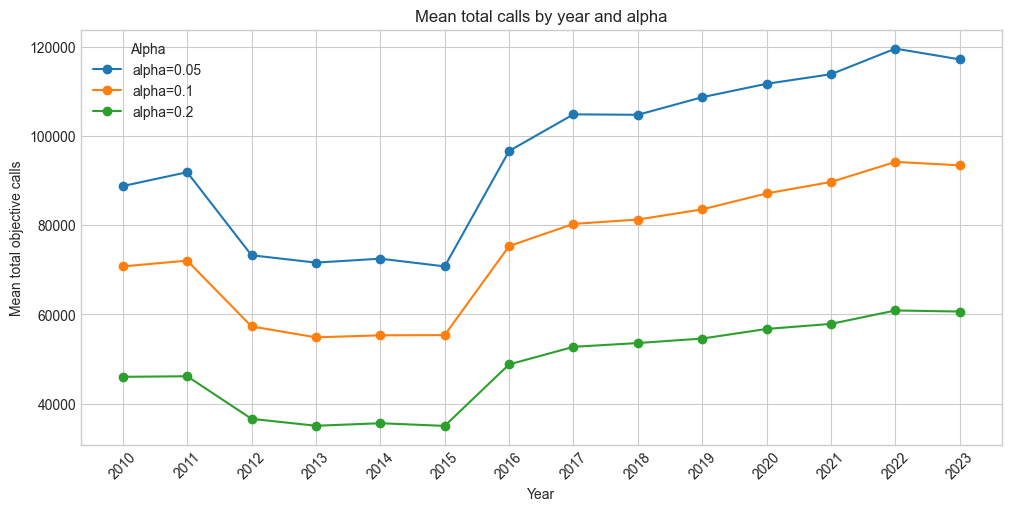

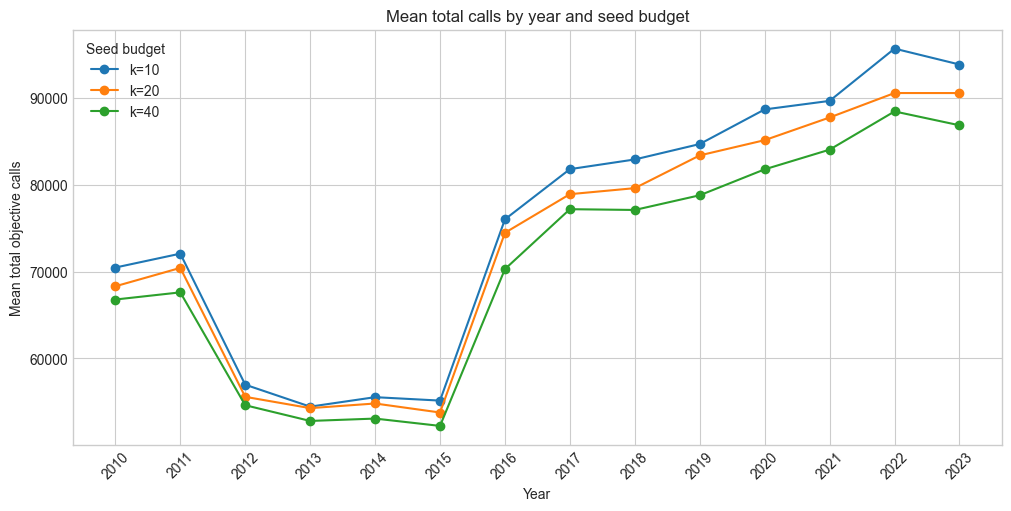

In [10]:
required_call_columns = {"search_objective_calls", "search_elapsed_seconds", "search_restarts"}
missing_call_columns = sorted(required_call_columns - set(results.columns))
if missing_call_columns:
    raise ValueError(f"Run metadata is missing objective-call fields: {missing_call_columns}")

results["calls_per_second"] = results["search_objective_calls"] / results["search_elapsed_seconds"]
call_summary = results[[
    "year", "alpha", "seed_budget", "search_objective_calls",
    "search_elapsed_seconds", "search_restarts", "calls_per_second",
]].sort_values(["year", "alpha", "seed_budget"])
display(call_summary.reset_index(drop=True))

parameter_heatmaps("search_objective_calls", "Total objective calls", "magma", ",.0f")

mean_calls_by_alpha = results.groupby(["year", "alpha"], as_index=False)["search_objective_calls"].mean()
mean_calls_by_budget = results.groupby(["year", "seed_budget"], as_index=False)["search_objective_calls"].mean()

fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
for alpha, group in mean_calls_by_alpha.groupby("alpha"):
    group = group.sort_values("year")
    axis.plot(group["year"], group["search_objective_calls"], marker="o", label=f"alpha={alpha:g}")
axis.set(xlabel="Year", ylabel="Mean total objective calls", title="Mean total calls by year and alpha")
axis.set_xticks(YEARS)
axis.tick_params(axis="x", rotation=45)
axis.legend(title="Alpha")
plt.show()

fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
for budget, group in mean_calls_by_budget.groupby("seed_budget"):
    group = group.sort_values("year")
    axis.plot(group["year"], group["search_objective_calls"], marker="o", label=f"k={int(budget)}")
axis.set(xlabel="Year", ylabel="Mean total objective calls", title="Mean total calls by year and seed budget")
axis.set_xticks(YEARS)
axis.tick_params(axis="x", rotation=45)
axis.legend(title="Seed budget")
plt.show()

### Optimization history by objective calls

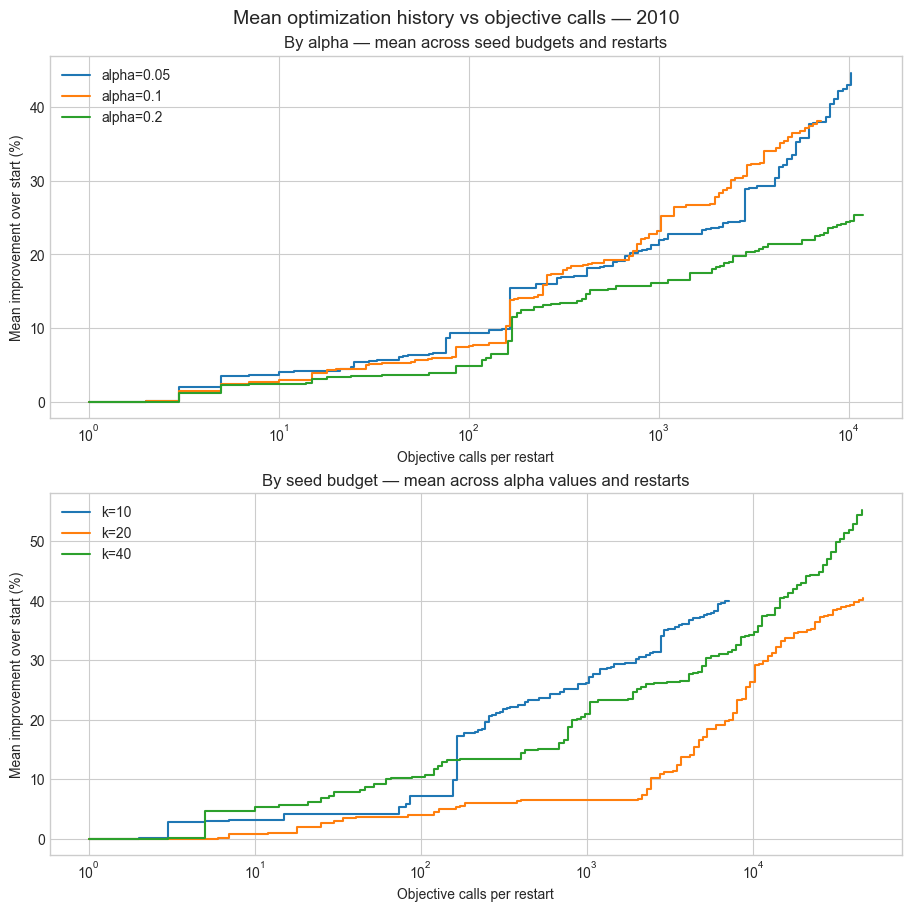

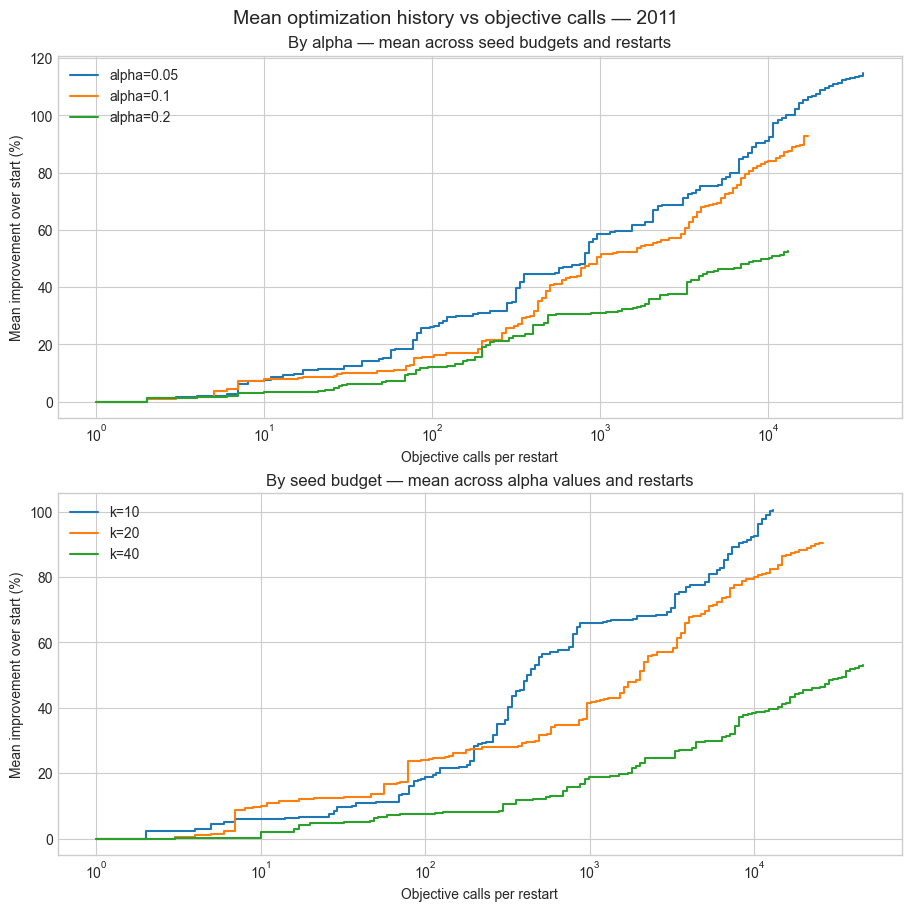

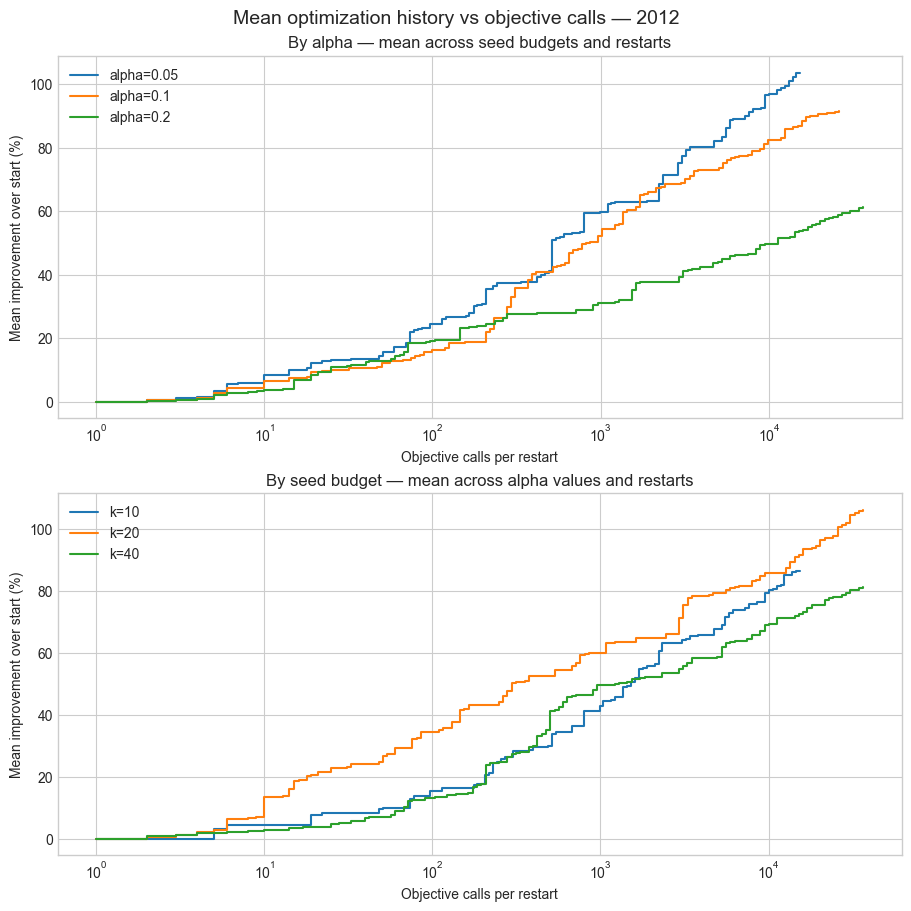

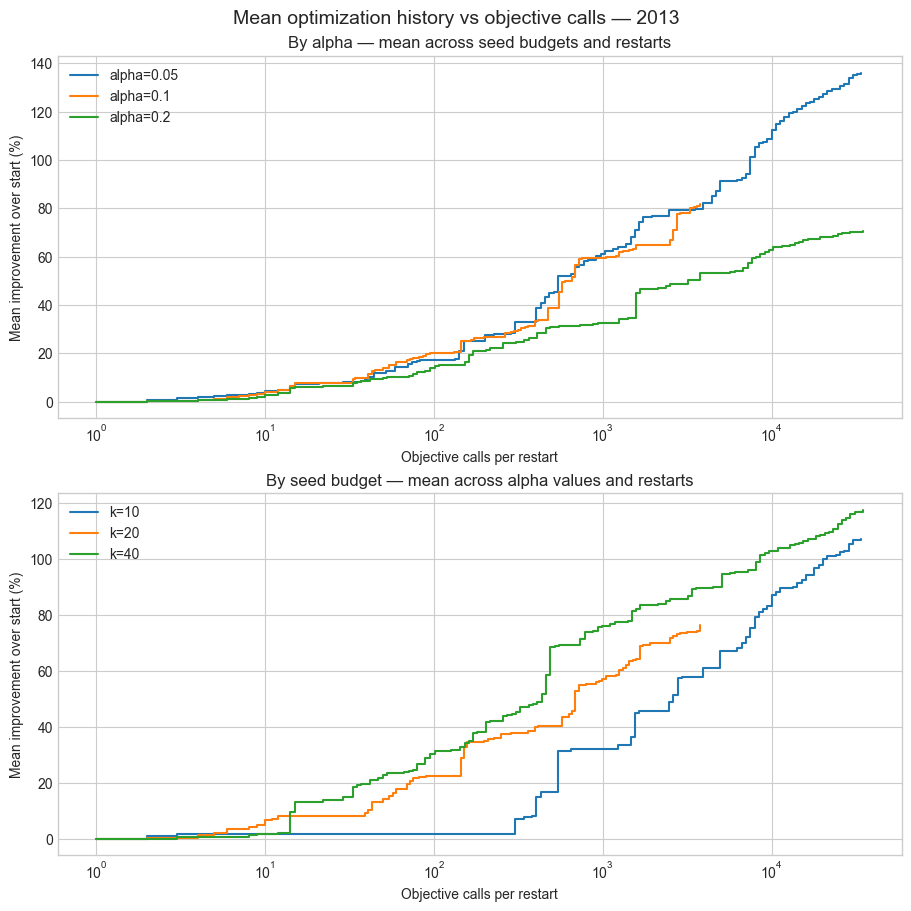

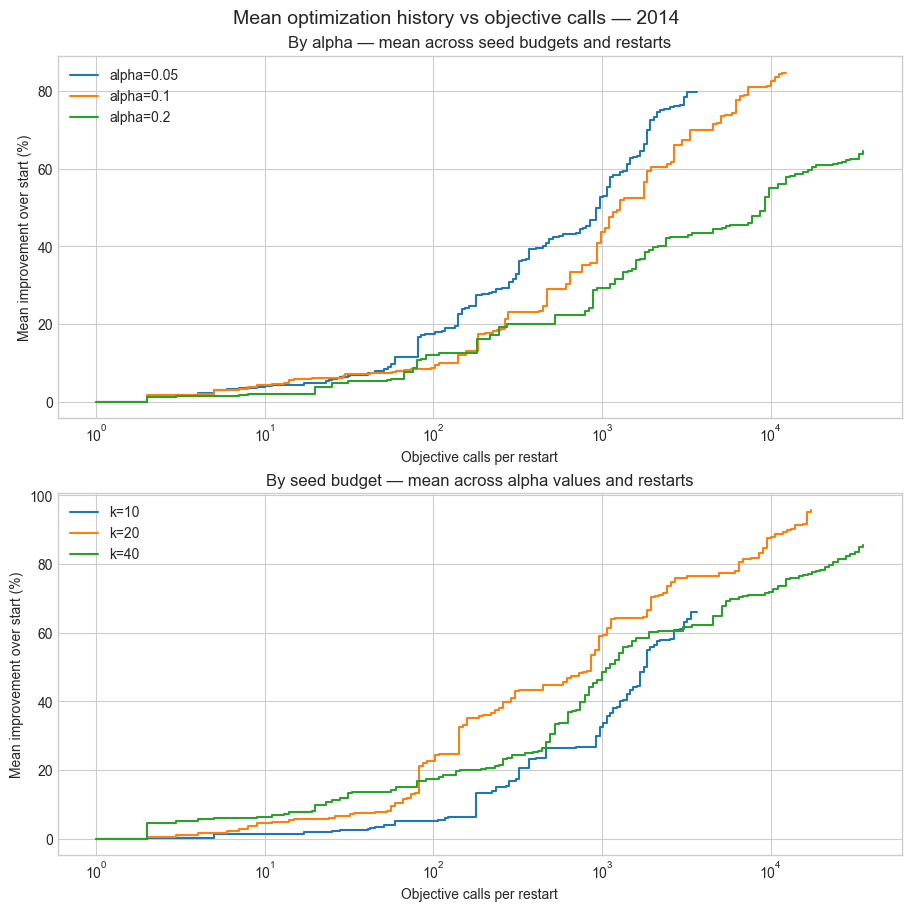

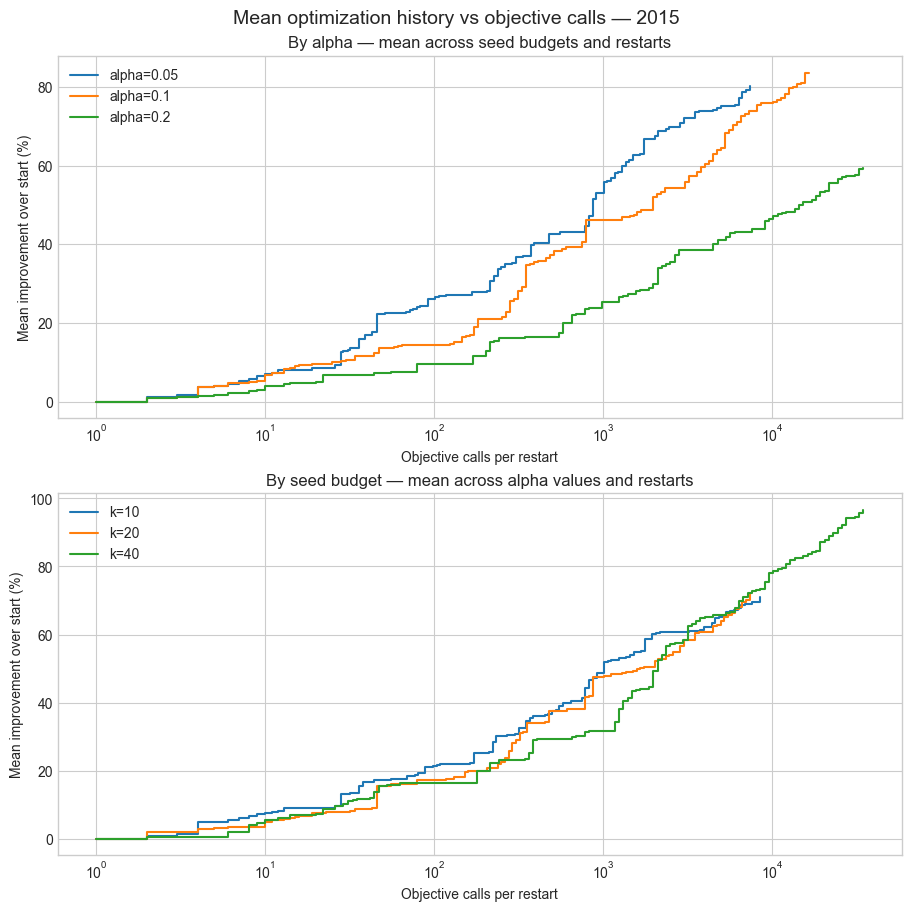

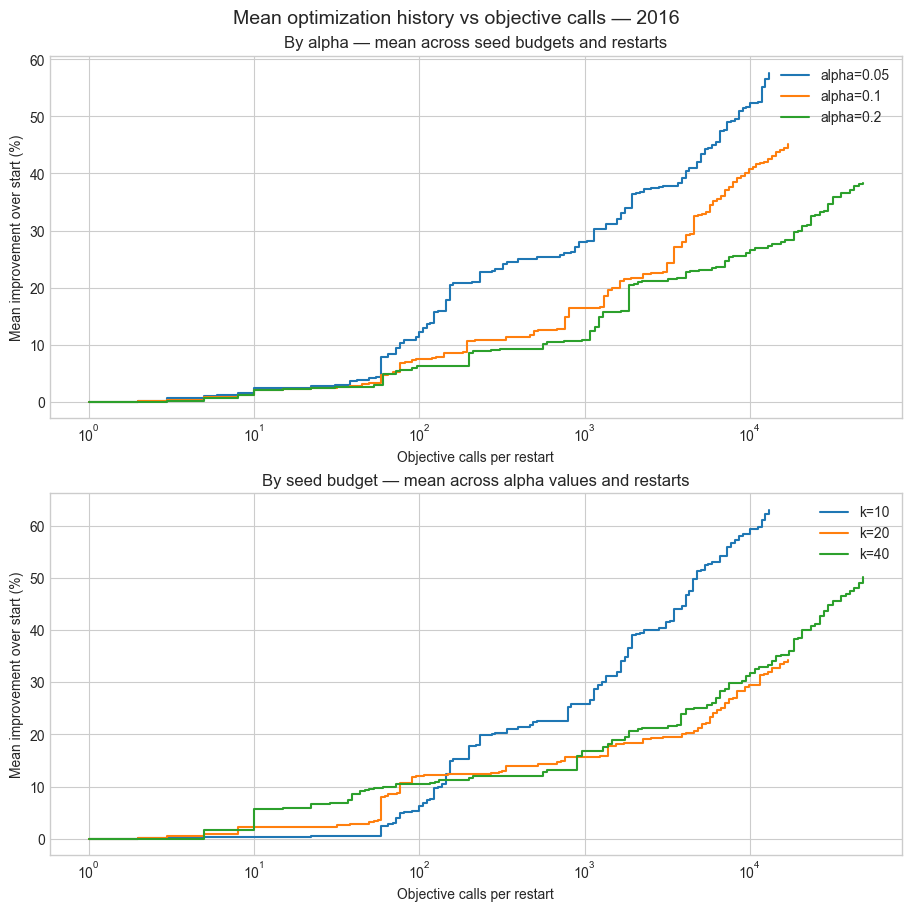

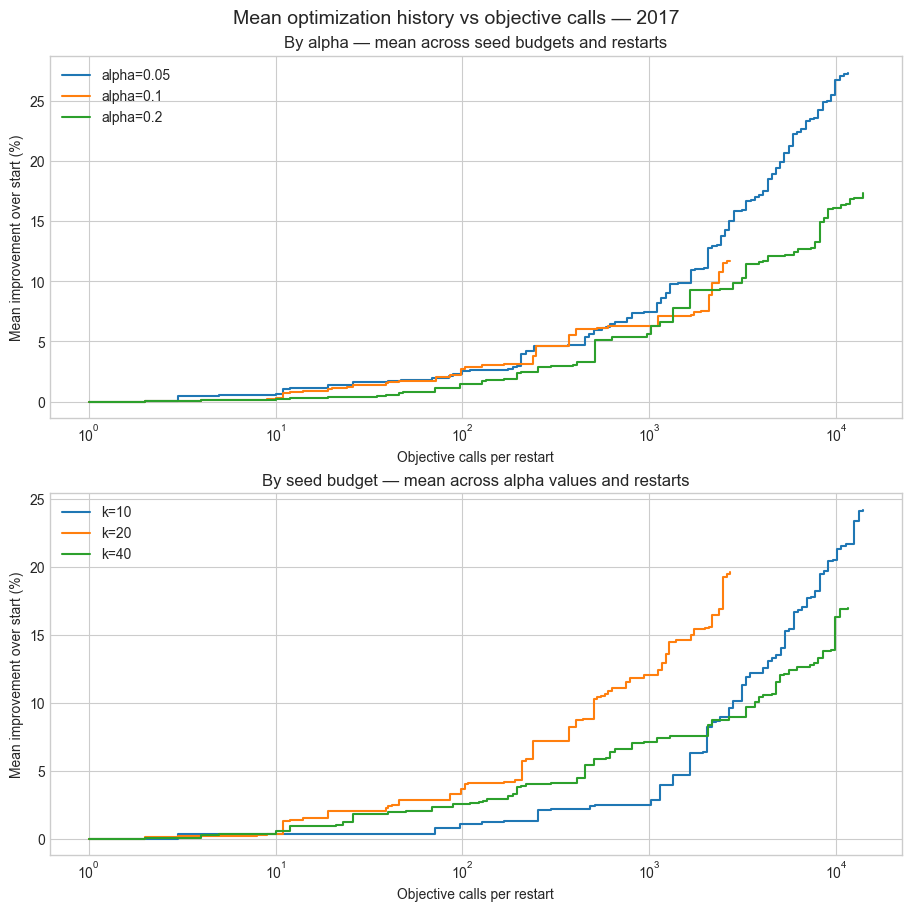

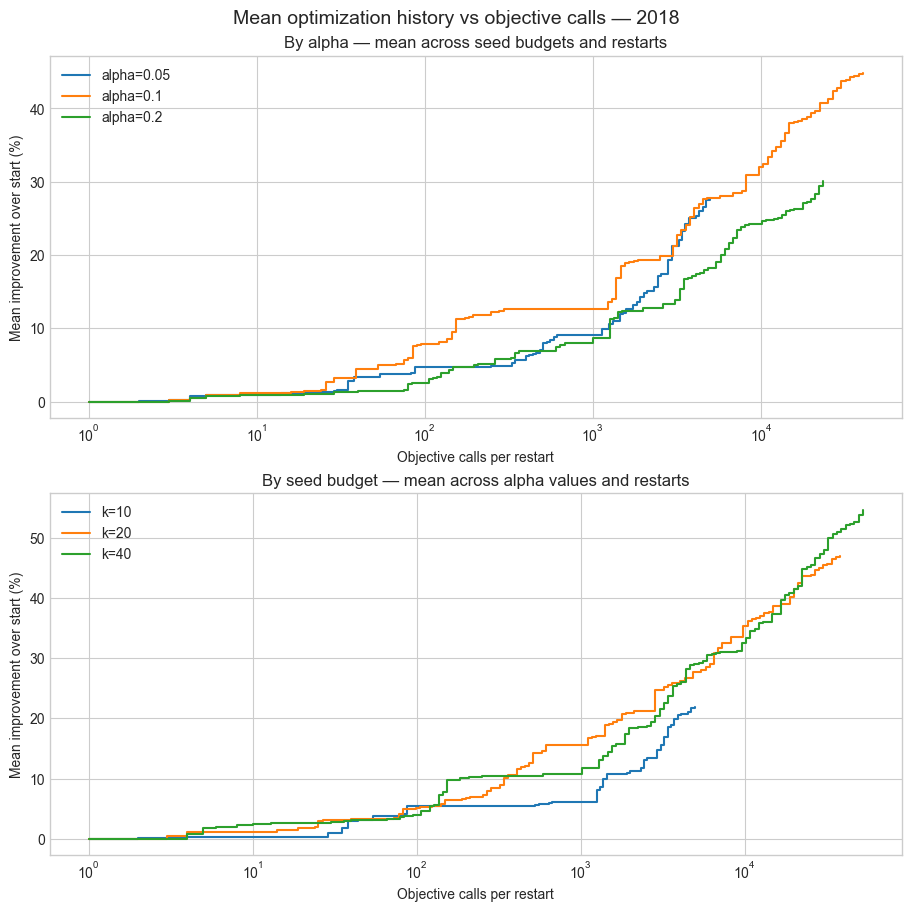

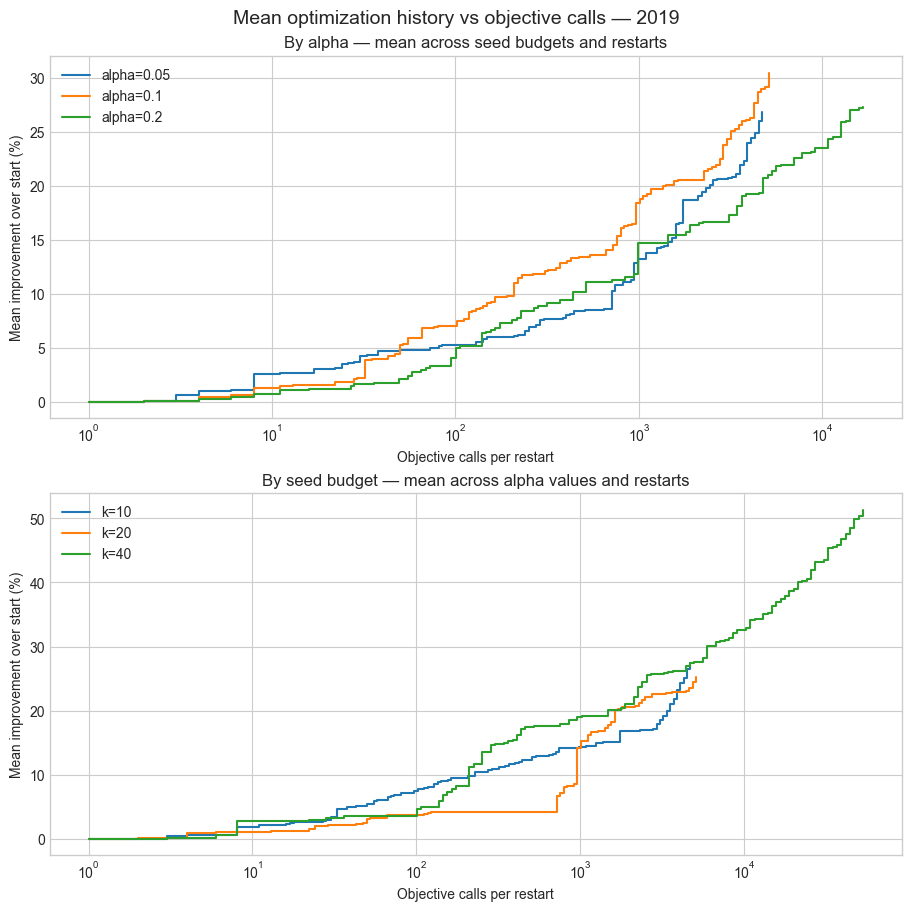

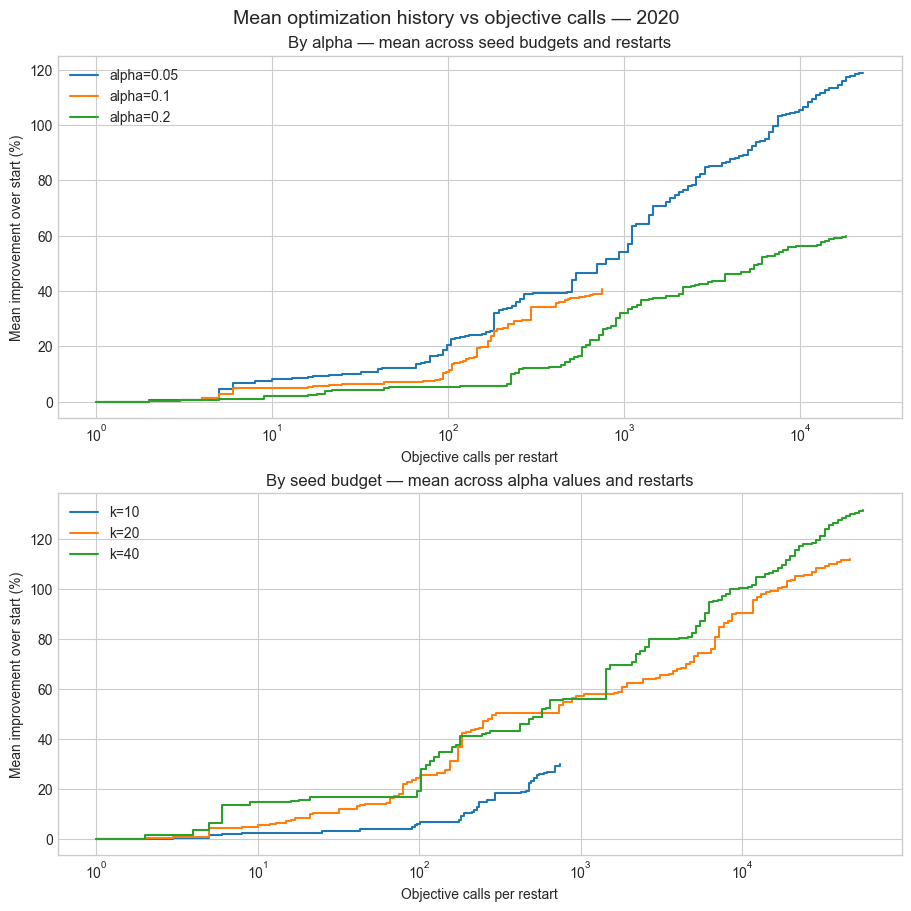

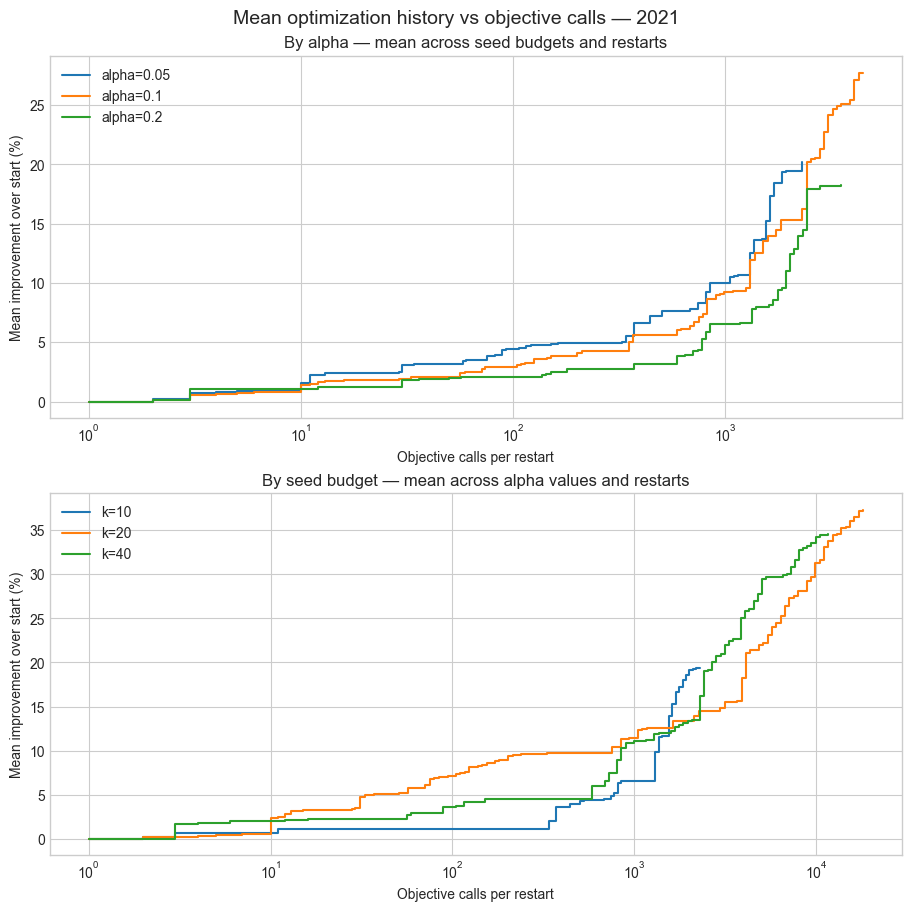

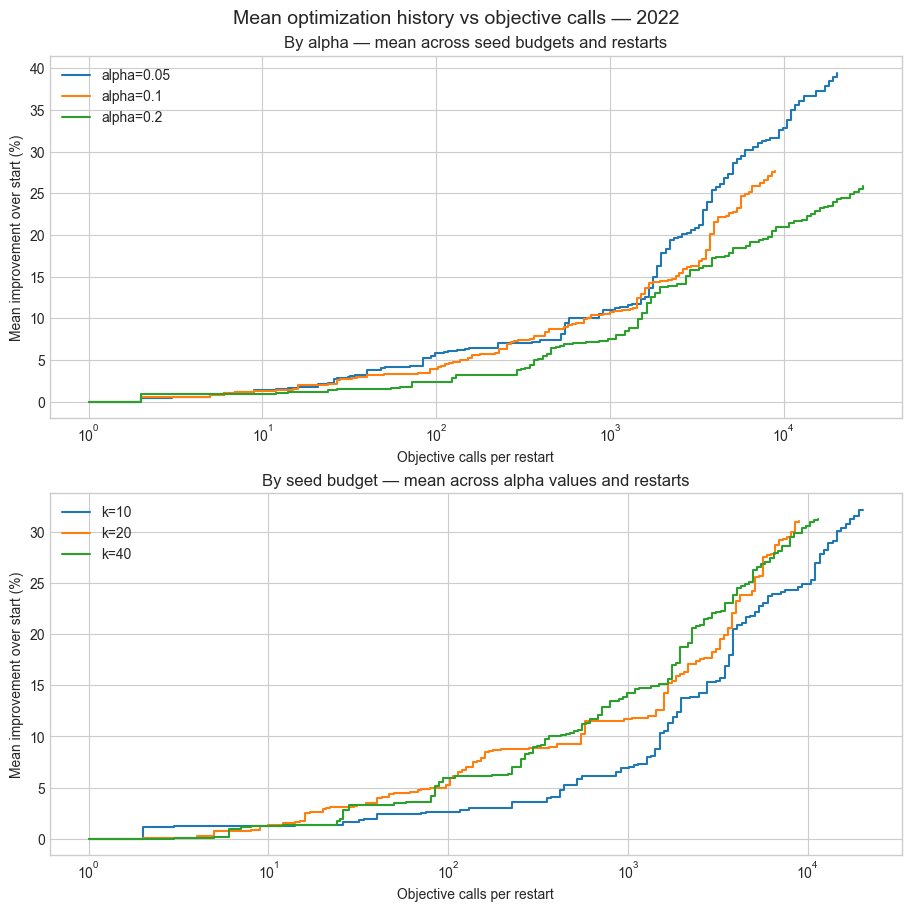

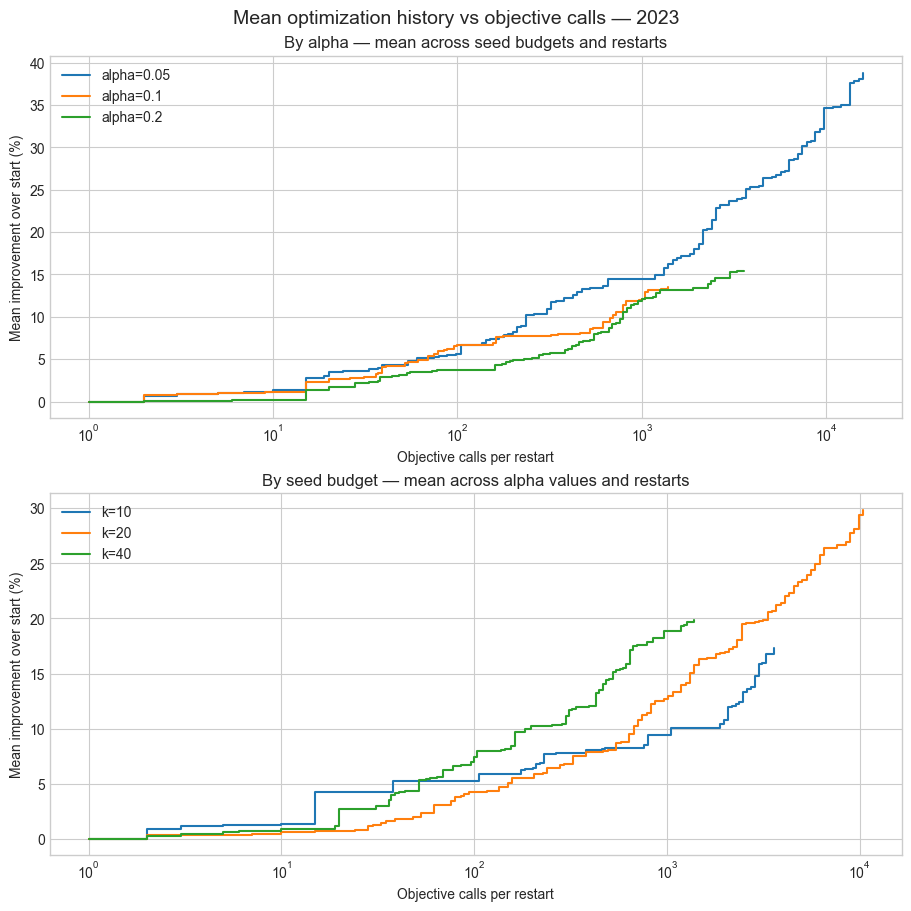

In [11]:
history_search_records = []
for result_index, row in results.iterrows():
    for search in json.loads(row["nads_history"]):
        events = search["events"]
        if not events:
            continue
        event_calls = np.asarray([event["call"] for event in events], dtype=int)
        event_values = np.asarray([event["value"] for event in events], dtype=float)
        history_search_records.append({
            "result_index": int(result_index),
            "year": int(row["year"]),
            "alpha": float(row["alpha"]),
            "seed_budget": int(row["seed_budget"]),
            "search_number": int(search["search_number"]),
            "objective_calls": int(search["objective_calls"]),
            "event_calls": event_calls,
            "improvement_pct": 100 * (event_values / float(row["start_spread"]) - 1),
        })

def mean_history_curve(records: list[dict[str, object]], grid_points: int = 180) -> tuple[np.ndarray, np.ndarray]:
    common_max_calls = min(record["objective_calls"] for record in records)
    call_grid = np.unique(np.geomspace(1, common_max_calls, grid_points).astype(int))
    sampled_histories = []
    for record in records:
        positions = np.searchsorted(record["event_calls"], call_grid, side="right") - 1
        positions = np.maximum(positions, 0)
        sampled_histories.append(record["improvement_pct"][positions])
    return call_grid, np.mean(sampled_histories, axis=0)

for year in YEARS:
    year_records = [record for record in history_search_records if record["year"] == year]
    fig, axes = plt.subplots(2, 1, figsize=(9, 9), constrained_layout=True)
    for alpha in sorted({record["alpha"] for record in year_records}):
        records = [record for record in year_records if record["alpha"] == alpha]
        call_grid, mean_curve = mean_history_curve(records)
        axes[0].step(call_grid, mean_curve, where="post", label=f"alpha={alpha:g}")
    for budget in sorted({record["seed_budget"] for record in year_records}):
        records = [record for record in year_records if record["seed_budget"] == budget]
        call_grid, mean_curve = mean_history_curve(records)
        axes[1].step(call_grid, mean_curve, where="post", label=f"k={budget}")
    axes[0].set(xlabel="Objective calls per restart", ylabel="Mean improvement over start (%)", title="By alpha — mean across seed budgets and restarts")
    axes[1].set(xlabel="Objective calls per restart", ylabel="Mean improvement over start (%)", title="By seed budget — mean across alpha values and restarts")
    for axis in axes:
        axis.set_xscale("log")
        axis.legend()
    fig.suptitle(f"Mean optimization history vs objective calls — {year}", fontsize=14)
    plt.show()

### Municipality selection trends

,municipality_id,municipality_name,appearances,years,alpha_values,seed_budgets,mean_rank,selection_rate_pct
0,1199250158,COMUNE DI MILANO,126,14,3,3,1.079,100.000
1,147990923,COMUNE DI CAGLIARI,118,14,3,3,16.500,93.651
2,215150236,COMUNE DI VERONA,110,14,3,3,2.973,87.302
3,145920351,COMUNE DI REGGIO NELL'EMILIA,106,14,3,3,2.283,84.127
4,514490010,COMUNE DI TORINO,96,14,3,3,9.531,76.190
5,168650307,COMUNE DI UDINE,86,13,3,3,7.674,68.254
6,389240219,COMUNE DI BOLZANO,84,14,3,3,13.619,66.667
7,80034840167,COMUNE DI BERGAMO,74,14,3,3,7.595,58.730
8,80015010723,COMUNE DI BARI,71,11,3,3,21.099,56.349
9,2438750586,ROMA CAPITALE,70,12,3,3,9.157,55.556


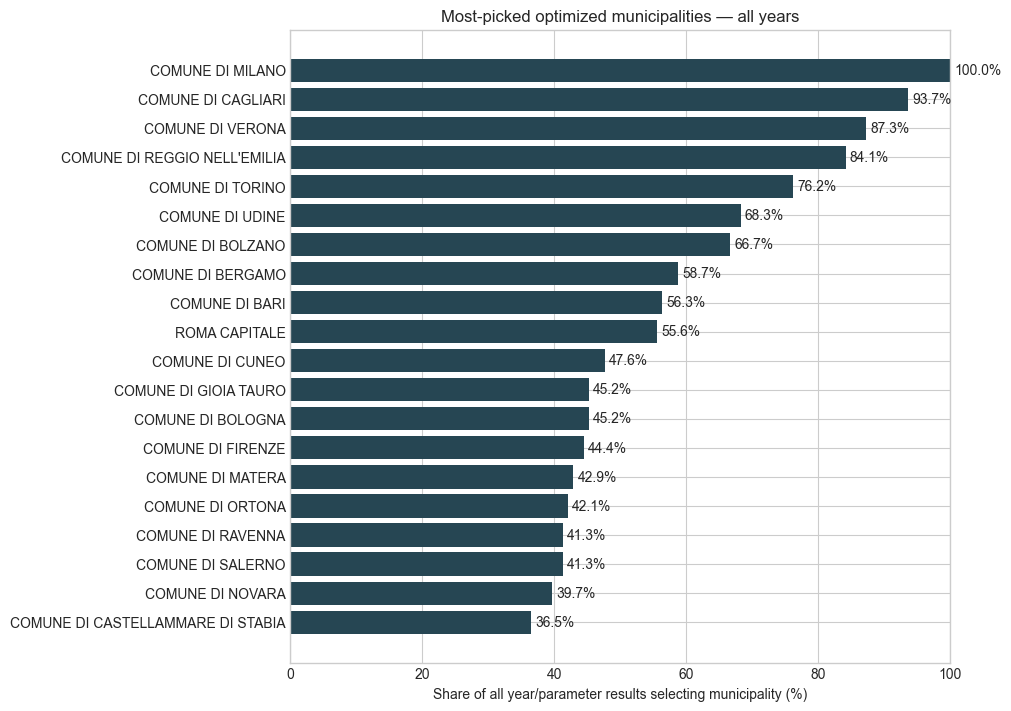

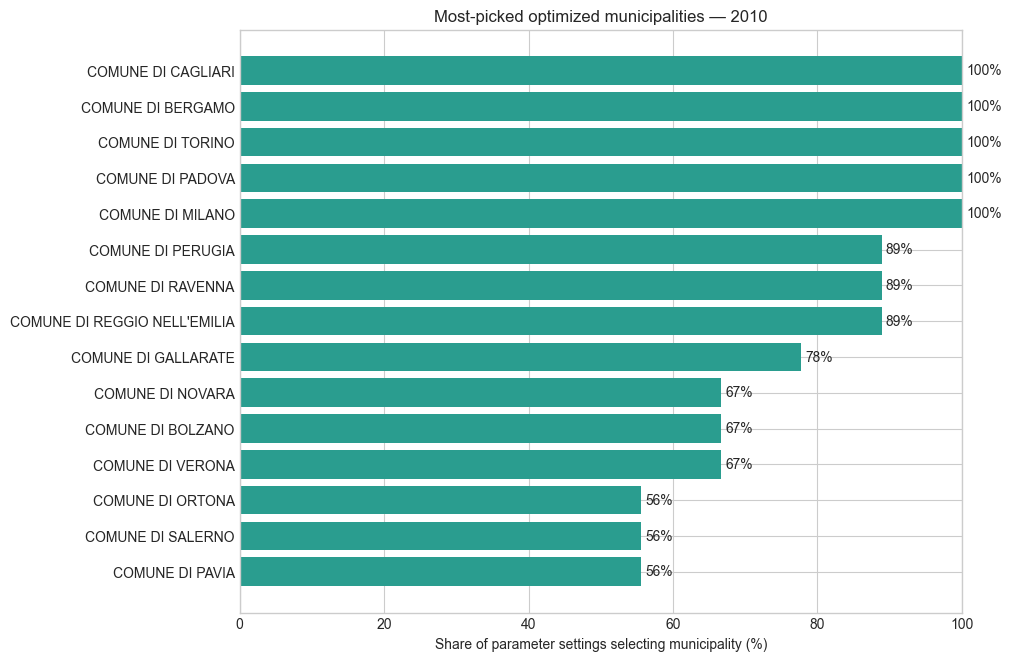

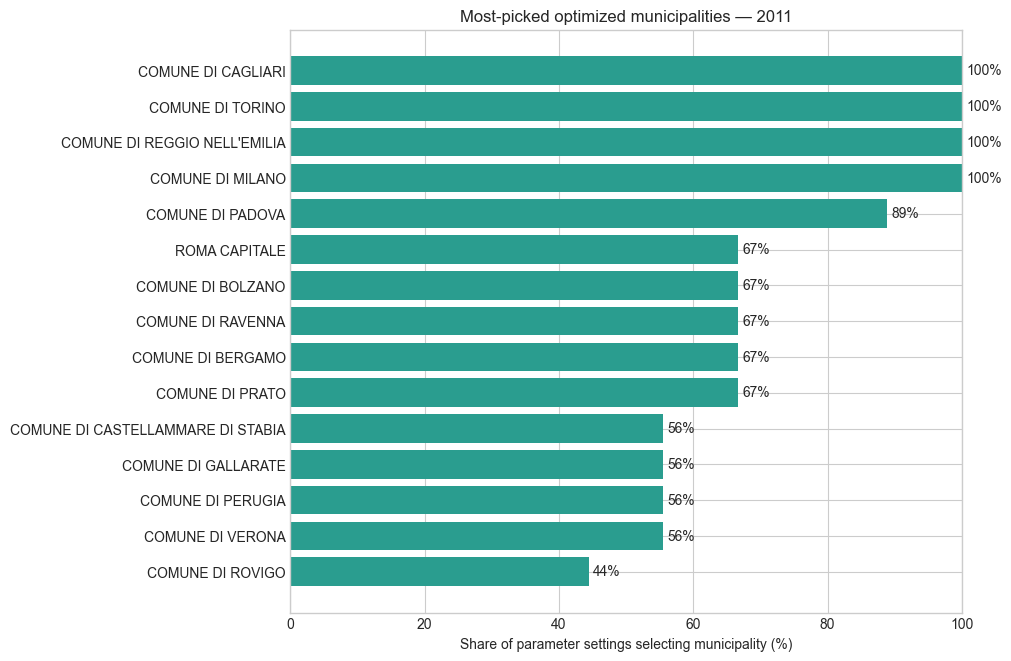

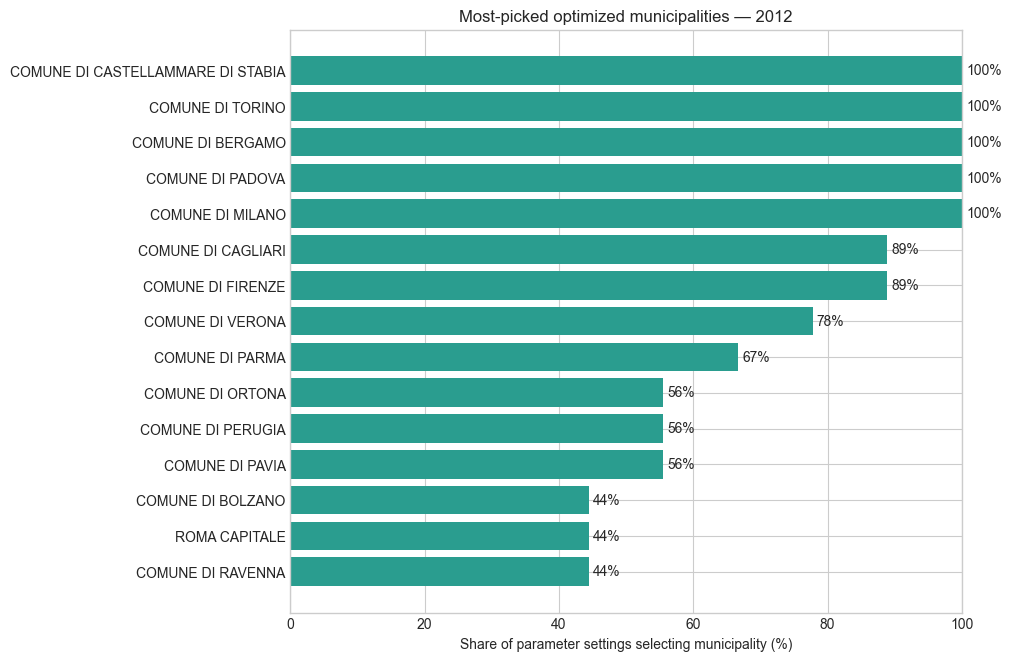

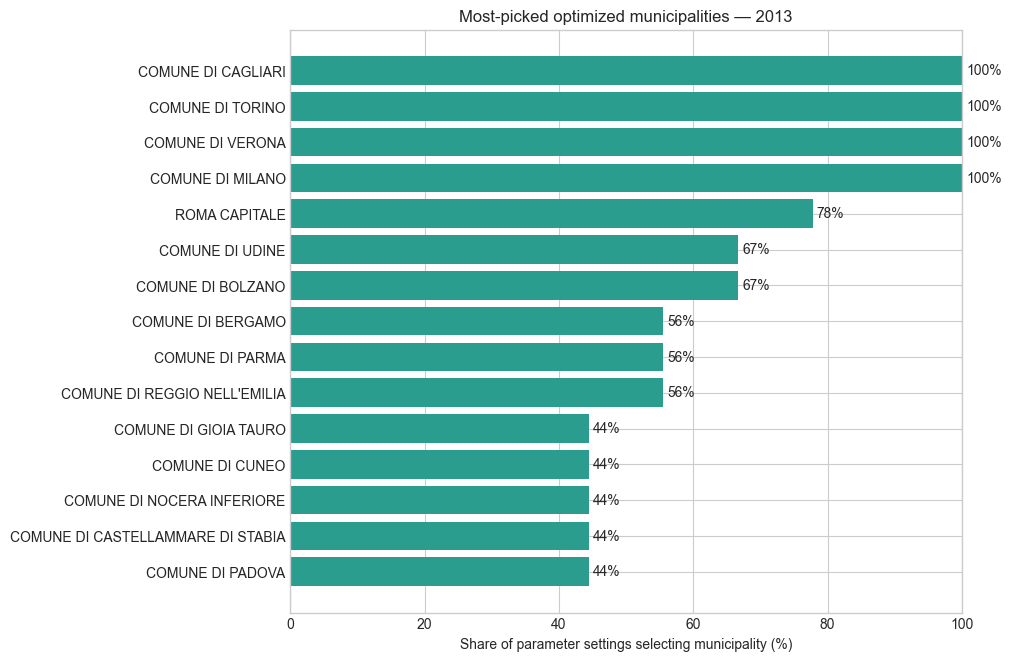

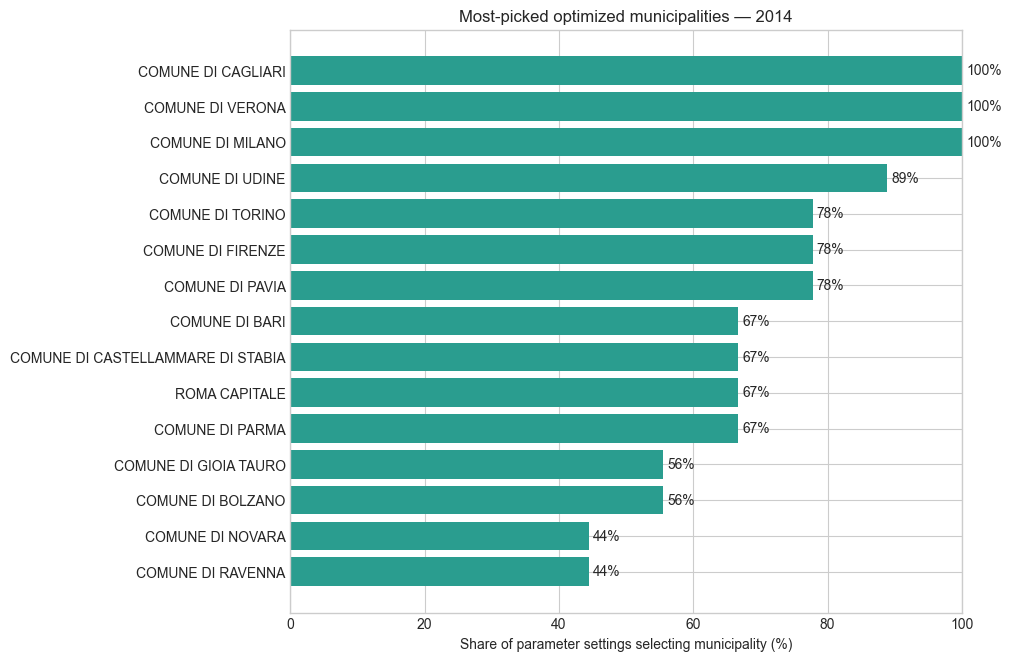

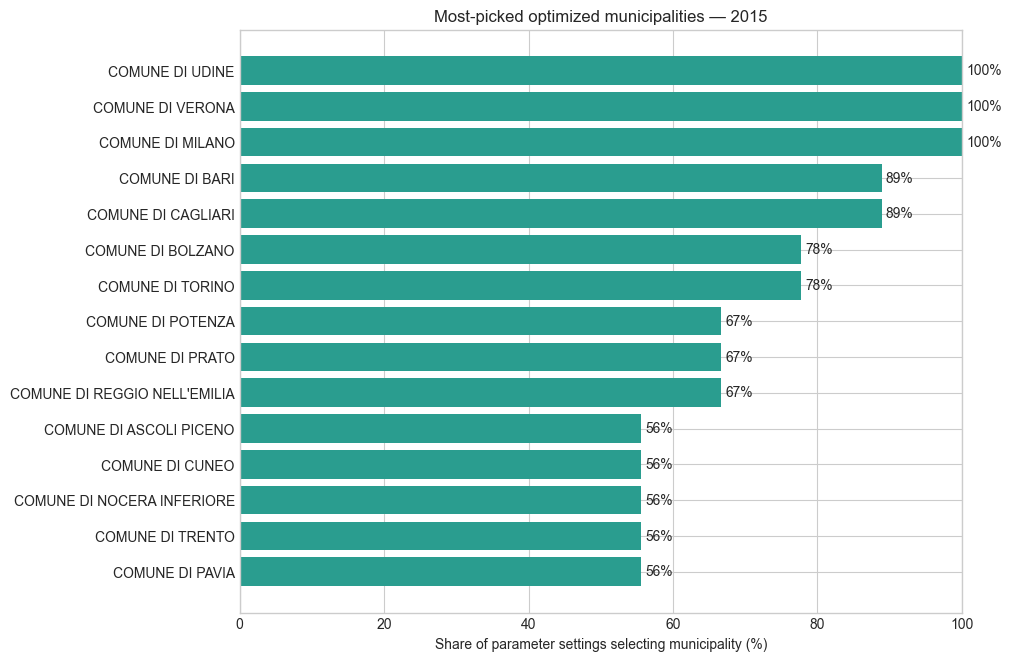

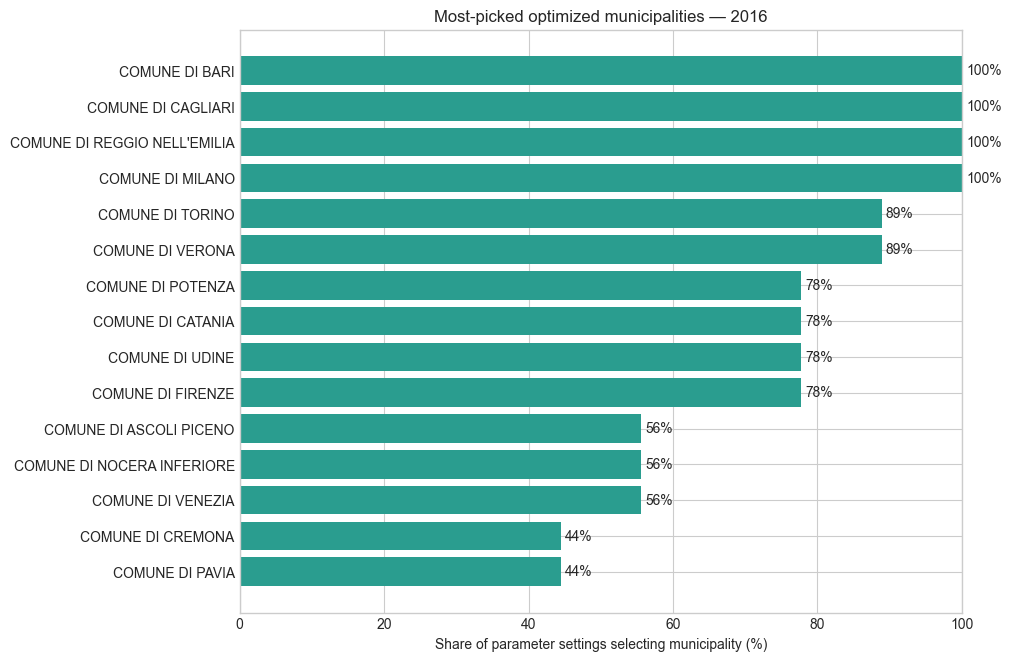

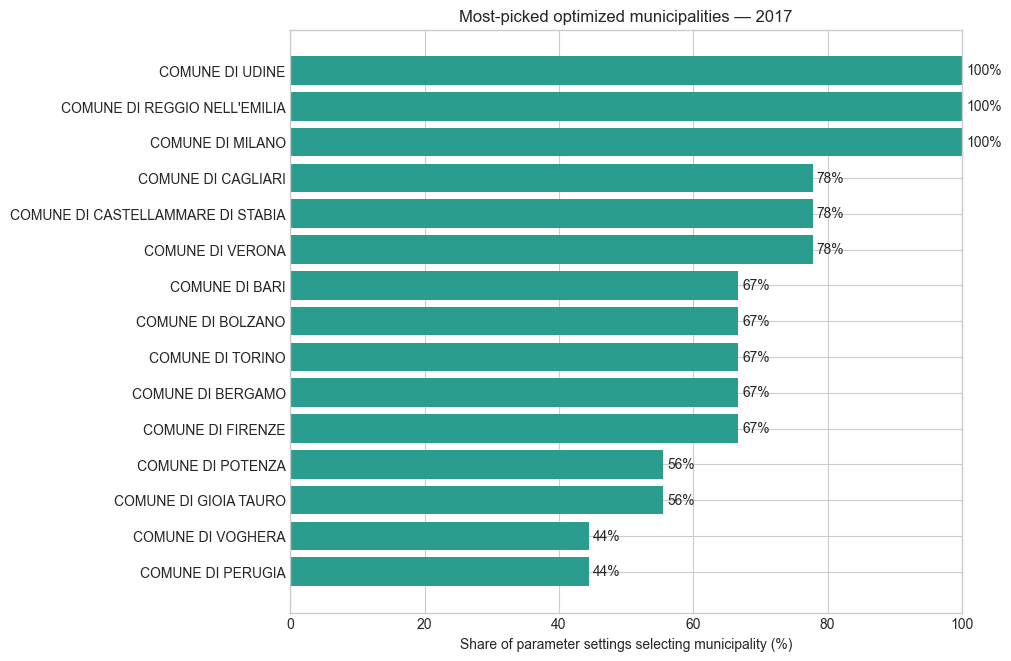

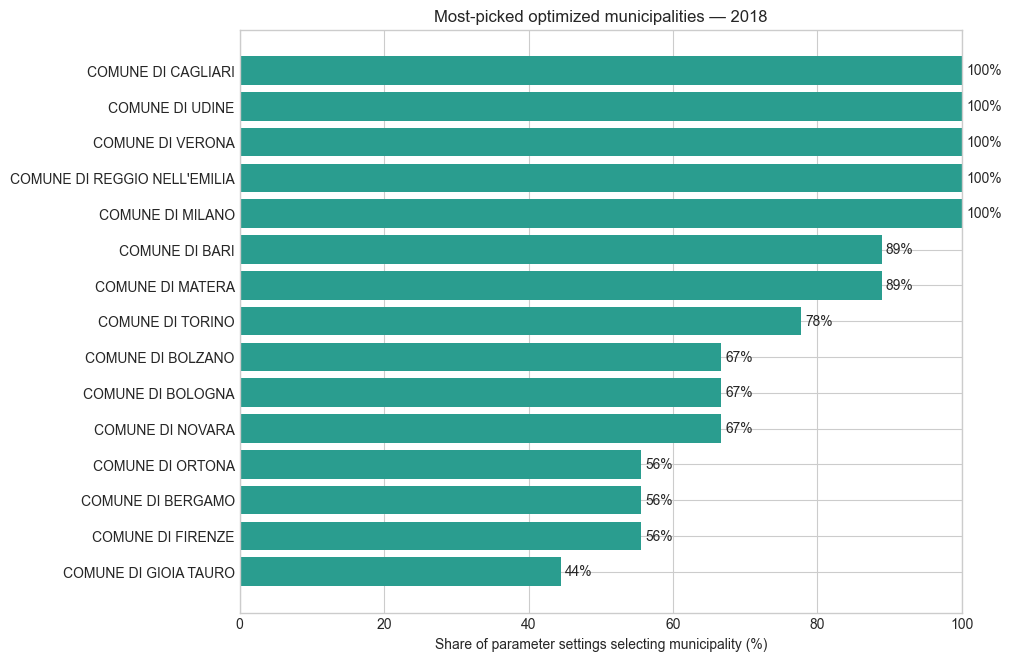

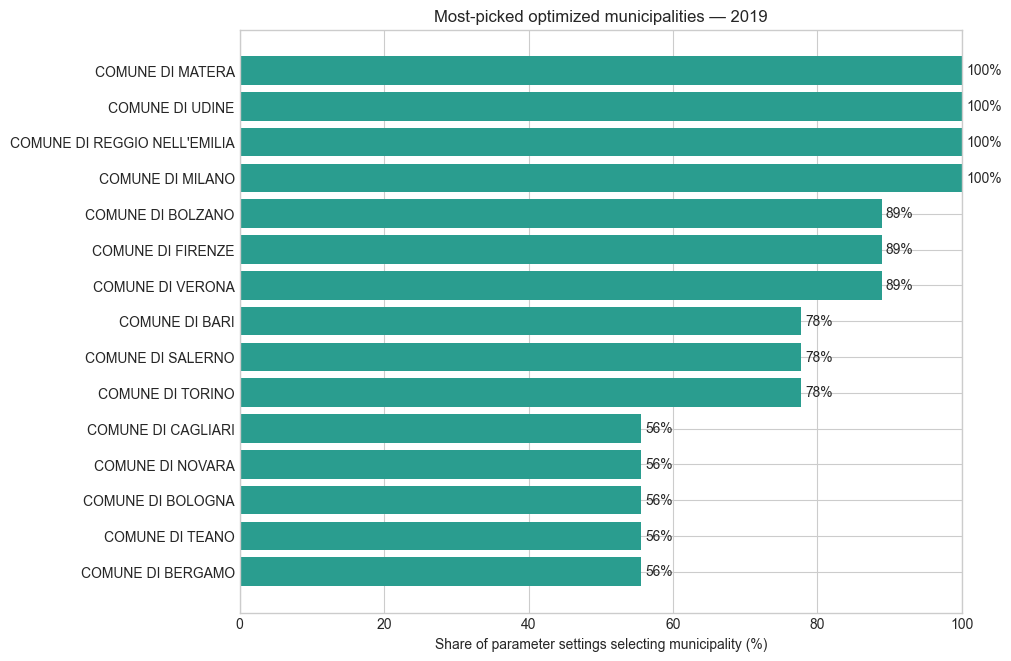

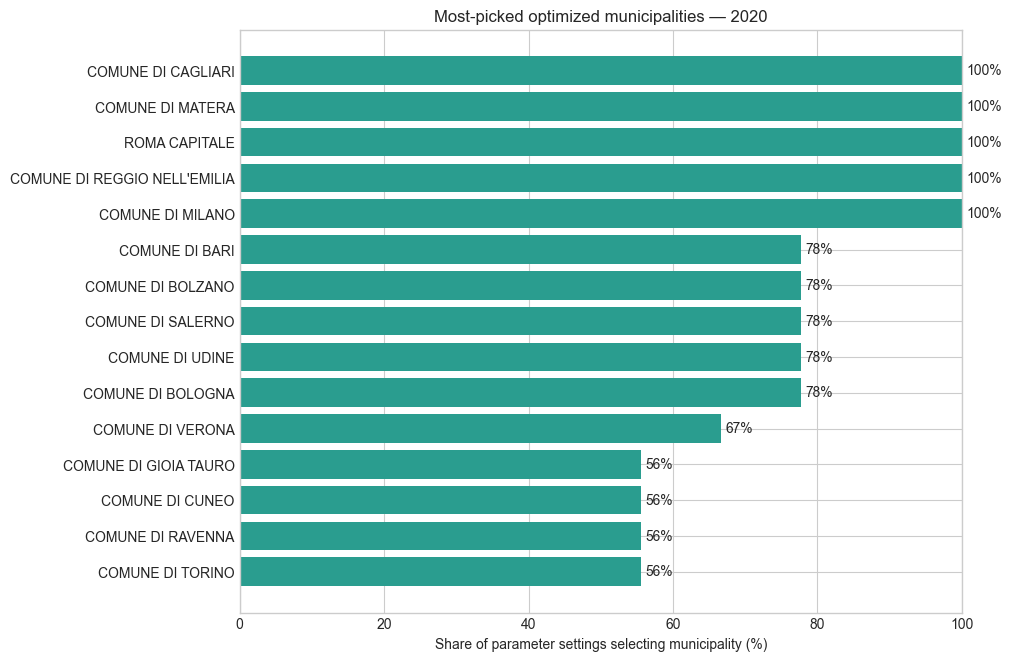

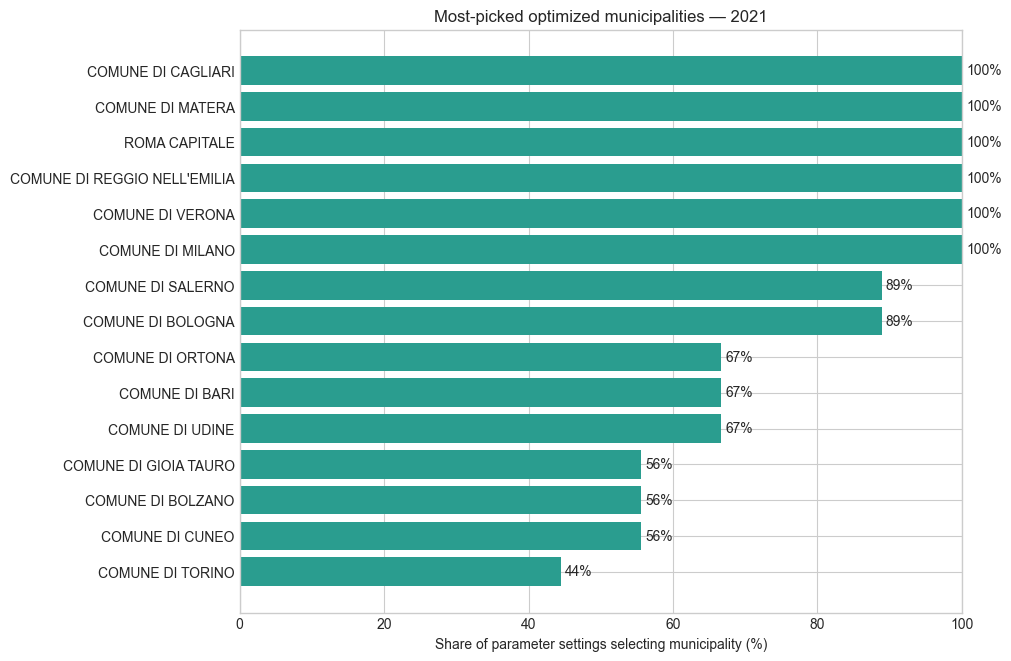

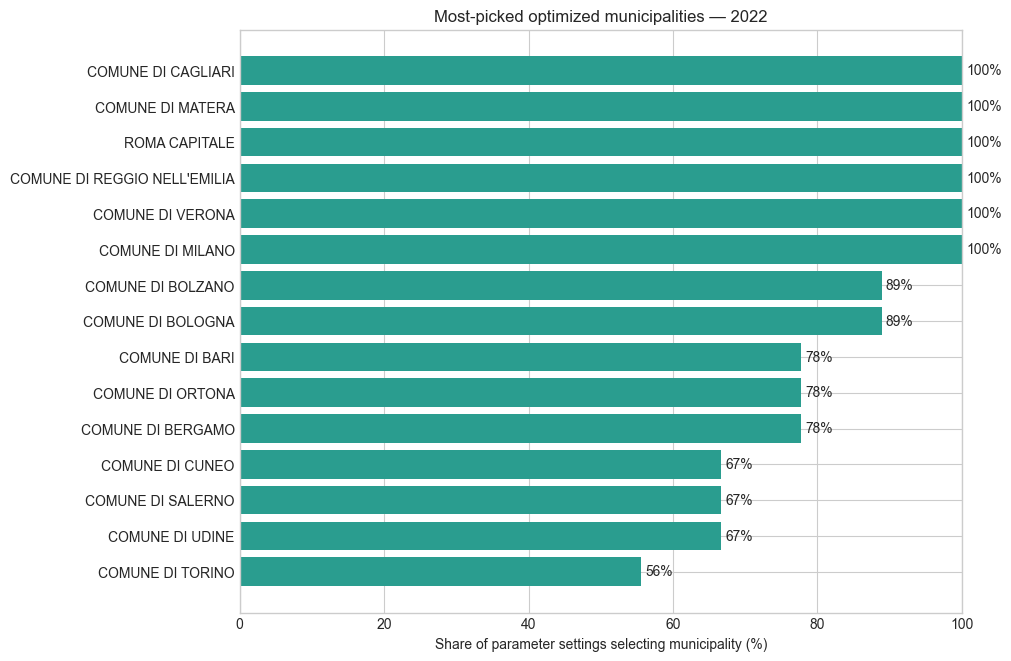

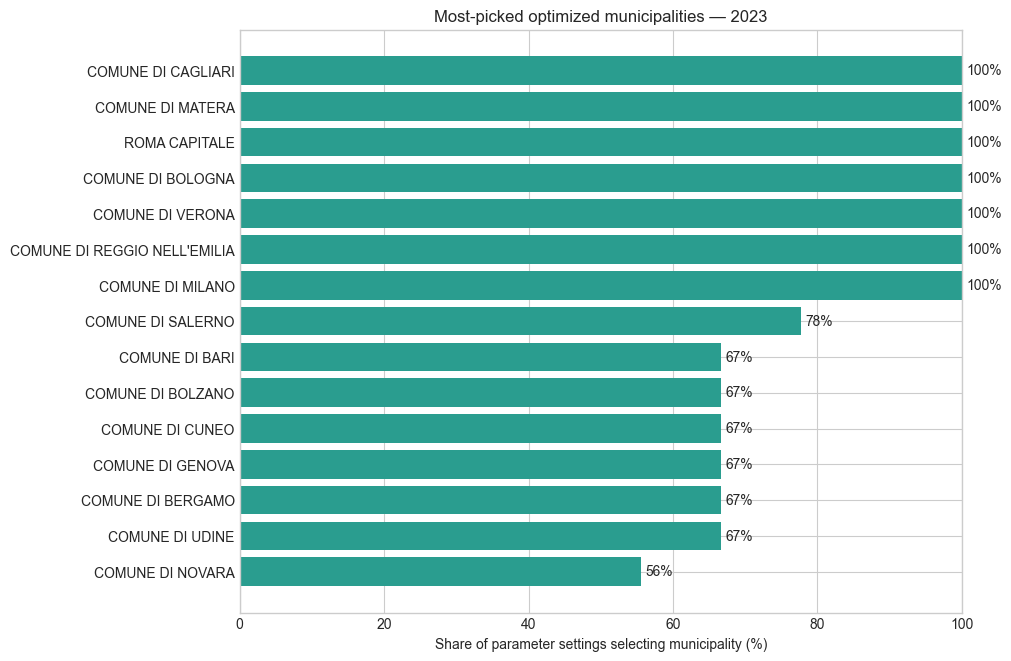

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
COMUNE DI MILANO [1199250158],100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
COMUNE DI CAGLIARI [147990923],100.000,100.000,88.889,100.000,100.000,88.889,100.000,77.778,100.000,55.556,100.000,100.000,100.000,100.000
COMUNE DI VERONA [215150236],66.667,55.556,77.778,100.000,100.000,100.000,88.889,77.778,100.000,88.889,66.667,100.000,100.000,100.000
COMUNE DI REGGIO NELL'EMILIA [145920351],88.889,100.000,33.333,55.556,33.333,66.667,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
COMUNE DI TORINO [514490010],100.000,100.000,100.000,100.000,77.778,77.778,88.889,66.667,77.778,77.778,55.556,44.444,55.556,44.444
COMUNE DI UDINE [168650307],22.222,22.222,0.000,66.667,88.889,100.000,77.778,100.000,100.000,100.000,77.778,66.667,66.667,66.667
COMUNE DI BOLZANO [389240219],66.667,66.667,44.444,66.667,55.556,77.778,44.444,66.667,66.667,88.889,77.778,55.556,88.889,66.667
COMUNE DI BERGAMO [80034840167],100.000,66.667,100.000,55.556,11.111,44.444,44.444,66.667,55.556,55.556,44.444,33.333,77.778,66.667
COMUNE DI BARI [80015010723],0.000,0.000,11.111,0.000,66.667,88.889,100.000,66.667,88.889,77.778,77.778,66.667,77.778,66.667
ROMA CAPITALE [2438750586],0.000,66.667,44.444,77.778,66.667,44.444,11.111,0.000,44.444,22.222,100.000,100.000,100.000,100.000


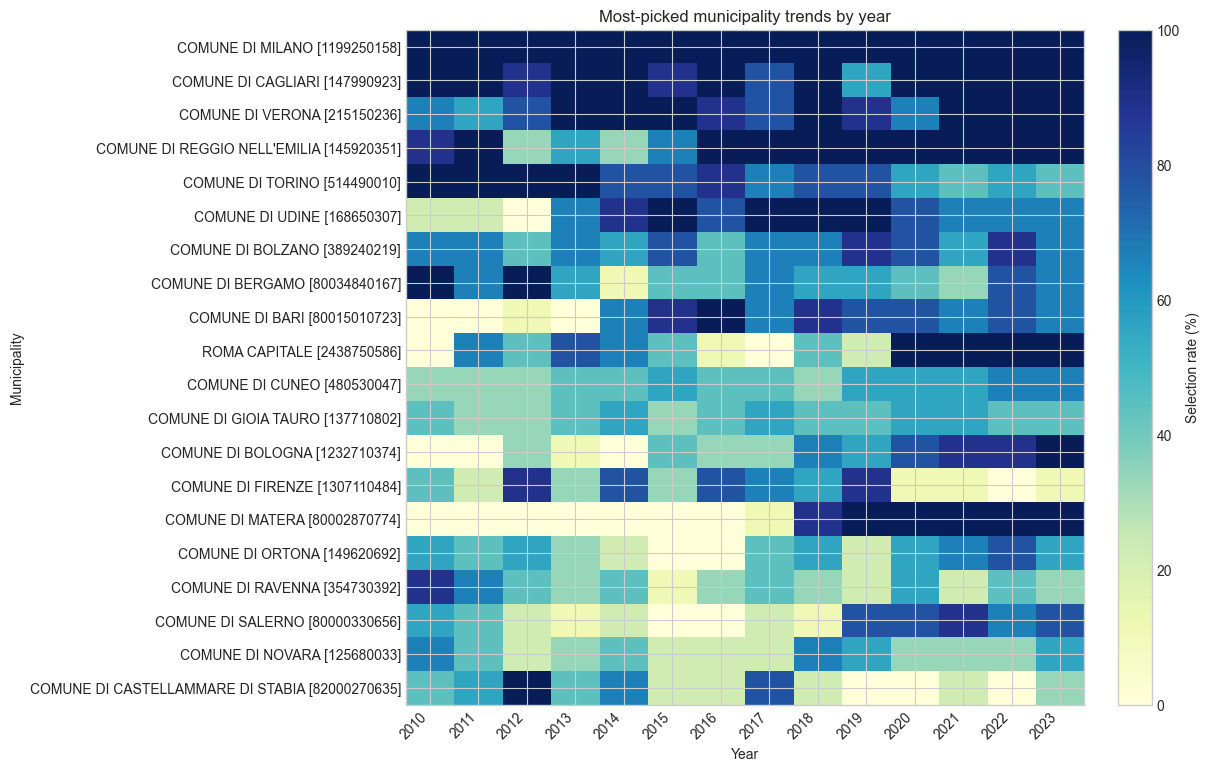

In [12]:
selection_entries = []
for result_index, row in results.iterrows():
    for rank, municipality_id in enumerate(row["finish_list"], start=1):
        municipality_id = int(municipality_id)
        selection_entries.append({
            "result_index": int(result_index),
            "year": int(row["year"]),
            "alpha": row["alpha"],
            "seed_budget": int(row["seed_budget"]),
            "municipality_id": municipality_id,
            "rank": rank,
        })
selections = pd.DataFrame(selection_entries)
municipality_latest_names = (
    municipalities.sort_values("year")
    .drop_duplicates("municipality_id", keep="last")
    .set_index("municipality_id")["municipality_name"]
    .to_dict()
)
municipality_summary = (
    selections.groupby("municipality_id")
    .agg(
        appearances=("result_index", "size"),
        years=("year", "nunique"),
        alpha_values=("alpha", "nunique"),
        seed_budgets=("seed_budget", "nunique"),
        mean_rank=("rank", "mean"),
    )
    .reset_index()
    .sort_values(["appearances", "years", "mean_rank"], ascending=[False, False, True])
)
municipality_summary.insert(1, "municipality_name", municipality_summary["municipality_id"].map(municipality_latest_names).fillna("unknown"))
municipality_summary["selection_rate_pct"] = 100 * municipality_summary["appearances"] / len(results)
display(municipality_summary.head(25).reset_index(drop=True))

aggregate_plot = municipality_summary.head(20).sort_values("selection_rate_pct")
fig, axis = plt.subplots(figsize=(10, 7), constrained_layout=True)
axis.barh(aggregate_plot["municipality_name"], aggregate_plot["selection_rate_pct"], color="#264653")
axis.set(title="Most-picked optimized municipalities — all years", xlabel="Share of all year/parameter results selecting municipality (%)", xlim=(0, 100))
axis.bar_label(axis.containers[0], fmt="%.1f%%", padding=3)
plt.show()

year_parameter_rows = results.groupby("year").size().rename("parameter_rows")
municipality_year_summary = (
    selections.groupby(["year", "municipality_id"])
    .agg(appearances=("result_index", "size"), mean_rank=("rank", "mean"))
    .reset_index()
    .merge(year_parameter_rows, on="year", validate="many_to_one")
)
municipality_year_summary["selection_rate_pct"] = 100 * municipality_year_summary["appearances"] / municipality_year_summary["parameter_rows"]
municipality_year_summary["municipality_name"] = municipality_year_summary["municipality_id"].map(municipality_latest_names).fillna("unknown")

for year in YEARS:
    plot_data = (
        municipality_year_summary.loc[municipality_year_summary["year"].eq(year)]
        .sort_values(["selection_rate_pct", "mean_rank"], ascending=[False, True])
        .head(15)
        .sort_values("selection_rate_pct")
    )
    fig, axis = plt.subplots(figsize=(10, 6.5), constrained_layout=True)
    axis.barh(plot_data["municipality_name"], plot_data["selection_rate_pct"], color="#2a9d8f")
    axis.set(title=f"Most-picked optimized municipalities — {year}", xlabel="Share of parameter settings selecting municipality (%)", xlim=(0, 100))
    axis.bar_label(axis.containers[0], fmt="%.0f%%", padding=3)
    plt.show()

TOP_MUNICIPALITIES = 20
top_municipality_ids = municipality_summary.head(TOP_MUNICIPALITIES)["municipality_id"]
selection_trends = (
    municipality_year_summary.loc[municipality_year_summary["municipality_id"].isin(top_municipality_ids)]
    .pivot(index="municipality_id", columns="year", values="selection_rate_pct")
    .reindex(columns=YEARS, fill_value=0)
    .fillna(0)
)
selection_trends = selection_trends.loc[selection_trends.mean(axis=1).sort_values(ascending=False).index]
selection_trends.index = [f"{municipality_latest_names.get(int(value), 'unknown')} [{int(value)}]" for value in selection_trends.index]
display(selection_trends)

fig, axis = plt.subplots(figsize=(12, max(7, 0.38 * len(selection_trends))), constrained_layout=True)
image = axis.imshow(selection_trends.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)
axis.set_xticks(np.arange(len(selection_trends.columns)), labels=selection_trends.columns, rotation=45, ha="right")
axis.set_yticks(np.arange(len(selection_trends.index)), labels=selection_trends.index)
axis.set(xlabel="Year", ylabel="Municipality", title="Most-picked municipality trends by year")
fig.colorbar(image, ax=axis, label="Selection rate (%)")
plt.show()

### Inspect one parameter setting

### year=2023, alpha=0.1, seed_budget=20

,value
start_spread,"19,611.251"
finish_spread,"27,967.350"
spread_gain_pct,42.609
retained_seeds,3
replaced_seeds,17


### Starting list

,start_rank,municipality_id,municipality_name,status
0,1,168650307,COMUNE DI UDINE,retained
1,2,516890241,COMUNE DI VICENZA,removed
2,3,761890177,COMUNE DI BRESCIA,removed
3,4,2253930156,COMUNE DI SESTO SAN GIOVANNI,removed
4,5,524950177,COMUNE DI CALCINATO,removed
5,6,145920351,COMUNE DI REGGIO NELL'EMILIA,retained
6,7,645400177,COMUNE DI MONTICHIARI,removed
7,8,80004590677,COMUNE DI CROGNALETO,removed
8,9,159200674,COMUNE DI PINETO,removed
9,10,644060287,COMUNE DI PADOVA,removed


### Optimized list

,finish_rank,municipality_id,municipality_name,status
0,1,1199250158,COMUNE DI MILANO,retained
1,2,145920351,COMUNE DI REGGIO NELL'EMILIA,retained
2,3,215150236,COMUNE DI VERONA,added
3,4,1232710374,COMUNE DI BOLOGNA,added
4,5,2438750586,ROMA CAPITALE,added
5,6,168650307,COMUNE DI UDINE,retained
6,7,80002870774,COMUNE DI MATERA,added
7,8,514490010,COMUNE DI TORINO,added
8,9,856930102,COMUNE DI GENOVA,added
9,10,480530047,COMUNE DI CUNEO,added


### NaDS improvement history

,search_number,random_seed,call,elapsed_seconds,seed_list,value
0,1,42,1,0.003,"[145920351, 159200674, 168650307, 179650221, 201900503, 221940364, 357850395, 441780483, 516890241, 524950177, 64406...","19,611.251"
1,1,42,2,0.007,"[145920351, 159200674, 168650307, 179650221, 201900503, 221940364, 354730392, 357850395, 441780483, 516890241, 52495...","19,741.540"
2,1,42,7,0.022,"[145920351, 159200674, 168650307, 179650221, 201900503, 221940364, 357850395, 368570271, 441780483, 516890241, 52495...","19,774.101"
3,1,42,10,0.031,"[145920351, 159200674, 168650307, 179650221, 201900503, 216350835, 221940364, 357850395, 441780483, 516890241, 52495...","19,798.140"
4,1,42,25,0.075,"[145920351, 159200674, 168650307, 179650221, 201900503, 221940364, 276830437, 357850395, 441780483, 516890241, 52495...","19,827.233"
...,...,...,...,...,...,...
173,2,43,29131,90.316,"[125680033, 145920351, 147990923, 159200674, 168650307, 179650221, 339370272, 354730392, 389240219, 450610175, 48053...","27,407.902"
174,2,43,29352,91.030,"[125680033, 145920351, 147990923, 159200674, 168650307, 179650221, 339370272, 354730392, 389240219, 400530176, 48053...","27,439.351"
175,2,43,31530,98.078,"[125680033, 145920351, 147990923, 149620692, 168650307, 179650221, 339370272, 354730392, 389240219, 480530047, 63568...","27,565.081"
176,2,43,31758,98.823,"[125680033, 145920351, 147990923, 149620692, 168650307, 179650221, 339370272, 354730392, 389240219, 480530047, 51449...","27,592.606"


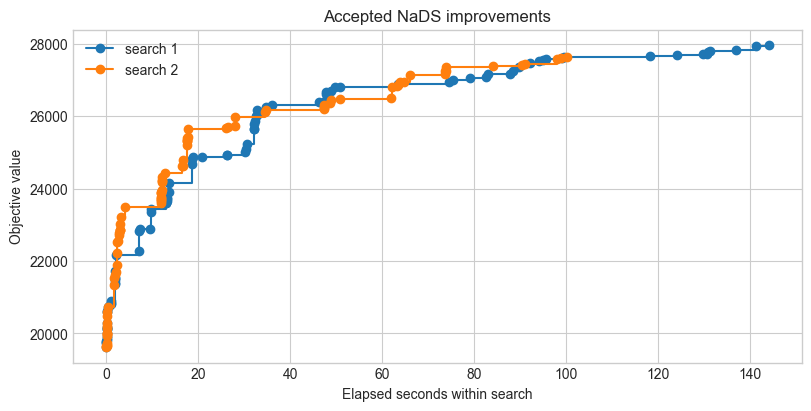

In [13]:
INSPECT_YEAR = max(YEARS)
INSPECT_ALPHA = 0.10
INSPECT_SEED_BUDGET = 20

inspect_matches = results.loc[
    results["year"].eq(INSPECT_YEAR)
    & np.isclose(results["alpha"], INSPECT_ALPHA)
    & results["seed_budget"].eq(INSPECT_SEED_BUDGET)
]
if inspect_matches.empty:
    chosen_result = results.sort_values(["year", "alpha", "seed_budget"]).iloc[-1]
    INSPECT_YEAR = int(chosen_result["year"])
    INSPECT_ALPHA = float(chosen_result["alpha"])
    INSPECT_SEED_BUDGET = int(chosen_result["seed_budget"])
    print("Preferred setting was not saved yet; using the latest available row.")
elif len(inspect_matches) > 1:
    raise ValueError("More than one row matches; filter another varied parameter as well")
else:
    chosen_result = inspect_matches.iloc[0]

CHOSEN_RESULT_INDEX = int(chosen_result.name)
start_ids = [int(value) for value in chosen_result["start_list"]]
finish_ids = [int(value) for value in chosen_result["finish_list"]]
start_set, finish_set = set(start_ids), set(finish_ids)
start_table = pd.DataFrame({
    "start_rank": range(1, len(start_ids) + 1),
    "municipality_id": start_ids,
    "municipality_name": [municipality_names.get((INSPECT_YEAR, value), "unknown") for value in start_ids],
    "status": ["retained" if value in finish_set else "removed" for value in start_ids],
})
finish_table = pd.DataFrame({
    "finish_rank": range(1, len(finish_ids) + 1),
    "municipality_id": finish_ids,
    "municipality_name": [municipality_names.get((INSPECT_YEAR, value), "unknown") for value in finish_ids],
    "status": ["retained" if value in start_set else "added" for value in finish_ids],
})
display(Markdown(f"### year={INSPECT_YEAR}, alpha={INSPECT_ALPHA:g}, seed_budget={INSPECT_SEED_BUDGET}"))
display(chosen_result[["start_spread", "finish_spread", "spread_gain_pct", "retained_seeds", "replaced_seeds"]].rename("value").to_frame())
display(Markdown("### Starting list"), start_table, Markdown("### Optimized list"), finish_table)

chosen_searches = json.loads(chosen_result["nads_history"])
chosen_history = pd.DataFrame([
    {"search_number": search["search_number"], "random_seed": search["random_seed"], **event}
    for search in chosen_searches
    for event in search["events"]
])
display(Markdown("### NaDS improvement history"), chosen_history)
fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
for search_number, group in chosen_history.groupby("search_number", sort=True):
    axis.step(group["elapsed_seconds"], group["value"], where="post", marker="o", label=f"search {search_number}")
axis.set(xlabel="Elapsed seconds within search", ylabel="Objective value", title="Accepted NaDS improvements")
if chosen_history["search_number"].nunique() > 1:
    axis.legend()
plt.show()

### Companies most involved in propagation

In [14]:
MODEL_CACHE = {}
PROPAGATION_CACHE = {}

def model_for_row(row: pd.Series) -> dict[str, object]:
    data_dir = PROJECT_ROOT / "data" / "processed"
    graph_metadata = json.loads(row["graph_metadata"])
    model_metadata = json.loads(row["model_metadata"])
    config = config_from_row(row)
    fingerprint = input_fingerprint(data_dir, int(row["year"]))
    if fingerprint != graph_metadata["input_fingerprint"]:
        raise ValueError("Saved input fingerprint differs from current data; use a newly generated result")
    key = (
        model_metadata["model_version"], fingerprint, int(row["year"]), config.min_edge_size,
        config.edge_weight_mean, config.edge_weight_beta,
        config.node_weight_mean, config.node_weight_beta,
    )
    if key not in MODEL_CACHE:
        model = load_year_model(int(row["year"]), config, data_dir=data_dir)
        model["source_key"] = key
        MODEL_CACHE[key] = model
    return MODEL_CACHE[key]

def propagation_for_row(result_index: int, row: pd.Series) -> dict[str, object]:
    model = model_for_row(row)
    config = config_from_row(row)
    seeds = validate_saved_seeds(row, model, config)["finish"]
    parameters = config.gip_parameters
    initial = seeds * np.asarray(parameters.u0)
    score_key = evaluation_cache_key(
        model["incidence"], model["edge_weights"], initial, parameters,
        node_weights=model["node_weights"], stress_level=config.stress_level,
        alpha=config.alpha, max_iter=config.max_iter,
    )
    key = (model["source_key"], score_key)
    if key in PROPAGATION_CACHE:
        return PROPAGATION_CACHE[key]
    propagation = gip(
        model["incidence"], model["edge_weights"], initial, parameters,
        node_weights=model["node_weights"], stress_level=config.stress_level,
        alpha=config.alpha, max_iter=config.max_iter,
    ).require_complete()
    activity = np.zeros(model["incidence"].shape[1])
    active_steps = np.zeros(model["incidence"].shape[1], dtype=int)
    for step, state in enumerate(propagation.states[:-1], start=1):
        pressure = np.asarray(model["incidence"]._matrix.T @ (model["node_weights"] * state)).reshape(-1)
        active_steps += (pressure > config.stress_level).astype(int)
        activity += (1 - parameters.gamma) ** step * company_activity(
            model["incidence"], model["edge_weights"], state, config.stress_level,
            node_weights=model["node_weights"],
        )
    metrics = model["edge_audit"].reset_index().copy()
    metrics["activity"] = activity
    metrics["activity_share_pct"] = 100 * activity / activity.sum() if activity.sum() else 0.0
    metrics["activity_rank"] = metrics["activity"].rank(method="min", ascending=False)
    metrics["active_steps"] = active_steps
    output = {"model": model, "seed_state": initial, "propagation": propagation,
              "metrics": metrics, "parameters": parameters, "max_iter": config.max_iter}
    PROPAGATION_CACHE[key] = output
    return output


In [15]:
activity_frames = []
reconstruction_checks = []
for result_index, row in results.iterrows():
    reconstructed = propagation_for_row(int(result_index), row)
    metrics = reconstructed["metrics"].copy()
    metrics["result_index"] = int(result_index)
    metrics["year"] = int(row["year"])
    metrics["alpha"] = float(row["alpha"])
    metrics["seed_budget"] = int(row["seed_budget"])
    activity_frames.append(metrics)
    reconstruction_checks.append({
        "result_index": int(result_index),
        "saved_finish_spread": row["finish_spread"],
        "reconstructed_finish_spread": reconstructed["propagation"].total_spread,
        "absolute_difference": abs(row["finish_spread"] - reconstructed["propagation"].total_spread),
    })
company_activities = pd.concat(activity_frames, ignore_index=True)
reconstruction_checks = pd.DataFrame(reconstruction_checks)
assert reconstruction_checks["absolute_difference"].max() < 1e-6, "Saved scores differ from current data/settings"
display(reconstruction_checks)

company_summary = (
    company_activities.groupby(["company_id", "company_name"])
    .agg(
        runs_present=("result_index", "nunique"),
        top_20_appearances=("activity_rank", lambda values: int(values.le(20).sum())),
        mean_activity_rank=("activity_rank", "mean"),
        mean_activity_share_pct=("activity_share_pct", "mean"),
        max_activity_share_pct=("activity_share_pct", "max"),
    )
    .reset_index()
    .sort_values(["top_20_appearances", "mean_activity_rank"], ascending=[False, True])
)
display(Markdown("### Companies consistently active across hyperparameter settings"))
display(company_summary.head(20).reset_index(drop=True))


,result_index,saved_finish_spread,reconstructed_finish_spread,absolute_difference
0,0,"9,436.033","9,436.033",0.000
1,1,"11,922.725","11,922.725",0.000
2,2,"13,864.828","13,864.828",0.000
3,3,"21,526.174","21,526.174",0.000
4,4,"25,496.990","25,496.990",0.000
...,...,...,...,...
121,121,"27,967.350","27,967.350",0.000
122,122,"33,248.523","33,248.523",0.000
123,123,"66,180.199","66,180.199",0.000
124,124,"74,534.375","74,534.375",0.000


### Companies consistently active across hyperparameter settings

,company_id,company_name,runs_present,top_20_appearances,mean_activity_rank,mean_activity_share_pct,max_activity_share_pct
0,3836450407,START ROMAGNA S.P.A.,126,113,10.333,0.292,0.355
1,3567090232,ACQUE VERONESI S.C.A R.L.,126,94,18.595,0.276,0.377
2,3341820276,VENEZIANA ENERGIA RISORSE IDRICHE TERRITORIO AMBIENTE SERVIZI - V.E.R.I.T.A.S. S.P.A.,126,89,19.167,0.264,0.350
3,7937540016,SOCIETA' METROPOLITANA ACQUE TORINO S.P.A. IN ALTERNATIVA SMA TORINO S.P.A. OVVERO SMAT S.P.A.,126,88,16.373,0.303,0.467
4,5264040485,CASA S.P.A.,126,84,17.944,0.278,0.413
5,337870406,ROMAGNA ACQUE - SOCIETA' DELLE FONTI S.P.A.,126,79,19.103,0.259,0.310
6,2658900366,SCUOLA INTERREGIONALE DI POLIZIA LOCALE IN FORMA ABBREVIATA SIPL,126,62,228.111,0.242,0.396
7,2106980598,CISTERNA AMBIENTE S.P.A. IN LIQUIDAZIONE,81,60,77.827,0.261,0.398
8,4855090488,QUADRIFOGLIO SERVIZI AMBIENTALI AREA FIORENTINA SPA,126,54,77.397,0.251,0.501
9,83002690275,A.S.V.O. - AMBIENTE SERVIZI VENEZIA ORIENTALE - S.P.A.,126,51,53.222,0.227,0.325


### Company propagation share across alpha — year=2023, seed_budget=20

alpha,0.050,0.100,0.200
company_name,,,
UMBRA ACQUE S.P.A.,0.492,0.456,0.430
ACQUEDOTTO DEL FIORA SOCIETA' PER AZIONI O IN FORMA ABBREVIATA ACQUEDOTTO DEL FIORA S.P.A.,0.427,0.390,0.364
GE.SE.SA. - GESTIONE SERVIZI SANNIO S.P.A.,0.371,0.335,0.311
ACQUE S.P.A.,0.347,0.323,0.305
PUBLIACQUA S.P.A.,0.326,0.307,0.292
V-RETI S.P.A.,0.325,0.305,0.290
AZIENDA GENERALE SERVIZI MUNICIPALI DI VERONA S.P.A - IN FORMA ABBREVIATA AGSM VERONA S.P.A.,0.324,0.304,0.289
ENERGIA E INFRASTRUTTURE ESCO S.R.L. IN SIGLA EN.IN. ESCO S.R.L.,0.315,0.296,0.281
"AZIENDA MULTISERVIZI DI IGIENE AMBIENTALE DI VERONA S.P.A. ABBREVIATA IN ""AMIA VERONA S.P.A.""",0.314,0.295,0.280


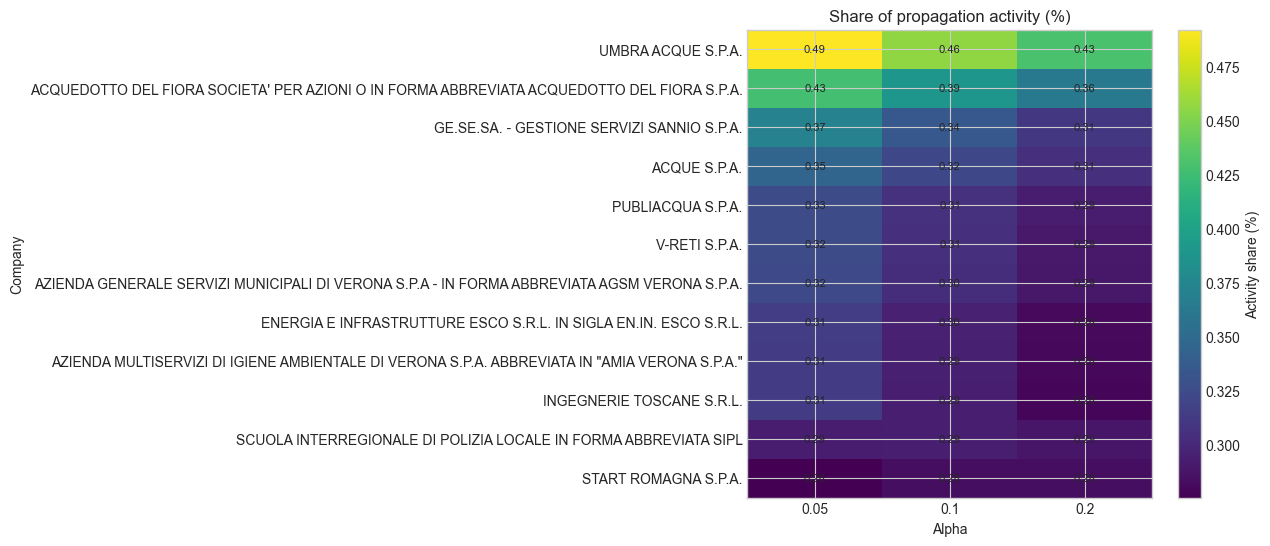

In [16]:
COMPANY_YEAR = INSPECT_YEAR
COMPANY_SEED_BUDGET = INSPECT_SEED_BUDGET
company_comparison = company_activities.loc[
    company_activities["year"].eq(COMPANY_YEAR)
    & company_activities["seed_budget"].eq(COMPANY_SEED_BUDGET)
].copy()
top_company_ids = set(
    company_comparison.sort_values("activity_rank").groupby("alpha").head(10)["company_id"]
)
activity_pivot = (
    company_comparison.loc[company_comparison["company_id"].isin(top_company_ids)]
    .pivot_table(index="company_name", columns="alpha", values="activity_share_pct", aggfunc="mean")
)
activity_pivot = activity_pivot.loc[activity_pivot.max(axis=1).sort_values(ascending=False).index]
display(Markdown(f"### Company propagation share across alpha — year={COMPANY_YEAR}, seed_budget={COMPANY_SEED_BUDGET}"))
display(activity_pivot)

fig, axis = plt.subplots(figsize=(11, max(6, 0.42 * len(activity_pivot))))
image = axis.imshow(activity_pivot.to_numpy(), aspect="auto", cmap="viridis")
axis.set_xticks(np.arange(len(activity_pivot.columns)), labels=activity_pivot.columns)
axis.set_yticks(np.arange(len(activity_pivot.index)), labels=activity_pivot.index)
axis.set(xlabel="Alpha", ylabel="Company", title="Share of propagation activity (%)")
for row_index in range(len(activity_pivot.index)):
    for column_index in range(len(activity_pivot.columns)):
        axis.text(column_index, row_index, f"{activity_pivot.iloc[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Activity share (%)")
fig.subplots_adjust(left=0.42, right=0.88, bottom=0.12, top=0.90)
plt.show()


## Starting-point sensitivity

### Summary and stability

In [17]:
STARTING_POINT_RESULTS_PATH = RESULTS_PATH.parent / "starting_point_results.csv"

def parse_seed_set(value):
    return frozenset(int(item) for item in json.loads(value))

starting_point_runs = pd.DataFrame()
starting_point_summary = pd.DataFrame()
if not STARTING_POINT_RESULTS_PATH.exists():
    print(f"No starting-point results found at {STARTING_POINT_RESULTS_PATH}.")
else:
    starting_point_runs = pd.read_csv(STARTING_POINT_RESULTS_PATH, float_precision="round_trip")
    required = {"year", "alpha", "seed_budget", "start_spread", "finish_spread", "start_list", "finish_list", "starting_point_metadata"}
    missing = sorted(required - set(starting_point_runs.columns))
    if missing:
        raise ValueError(f"Starting-point results are missing columns: {missing}")
    starting_metadata = starting_point_runs["starting_point_metadata"].map(json.loads)
    for name in ("experiment_id", "run_index", "start_type", "num_starts"):
        starting_point_runs[name] = starting_metadata.map(lambda value: value[name])
    run_metadata = starting_point_runs["run_metadata"].map(json.loads)
    starting_point_runs["search_elapsed_seconds"] = run_metadata.map(lambda value: value["search_elapsed_seconds"])
    starting_point_runs["time_limit_reached"] = run_metadata.map(lambda value: value["search_time_limit_reached"])
    starting_point_runs["improvement_pct"] = 100 * (starting_point_runs["finish_spread"] / starting_point_runs["start_spread"] - 1)
    if starting_point_runs.duplicated(["experiment_id", "run_index"]).any():
        raise ValueError("Starting-point results contain duplicate experiment/run rows")
    starting_point_runs["start_set"] = starting_point_runs["start_list"].map(parse_seed_set)
    starting_point_runs["finish_set"] = starting_point_runs["finish_list"].map(parse_seed_set)
    summary_rows = []
    for experiment_id, group in starting_point_runs.groupby("experiment_id", sort=False):
        group = group.sort_values("run_index")
        finish_sets = group["finish_set"].tolist()
        scores = group["finish_spread"].astype(float)
        unique_solutions = len(set(finish_sets))
        planned = int(group["num_starts"].iloc[0])
        time_limited = int(group["time_limit_reached"].astype(str).str.lower().eq("true").sum())
        if len(group) < planned:
            conclusion = "Incomplete experiment"
        elif unique_solutions == 1:
            conclusion = "Same final seed set from every start"
        elif np.isclose(scores.min(), scores.max(), rtol=1e-9, atol=1e-9):
            conclusion = "Different seed sets with equivalent scores"
        else:
            conclusion = "Different seed sets and different scores"
        if time_limited:
            conclusion += f" ({time_limited} time-capped run(s))"
        summary_rows.append({
            "experiment_id": experiment_id,
            "year": int(group["year"].iloc[0]),
            "alpha": float(group["alpha"].iloc[0]),
            "seed_budget": int(group["seed_budget"].iloc[0]),
            "completed_starts": len(group),
            "planned_starts": planned,
            "unique_final_seed_sets": unique_solutions,
            "finish_spread_min": scores.min(),
            "finish_spread_max": scores.max(),
            "finish_spread_range": scores.max() - scores.min(),
            "relative_range_pct": 100 * (scores.max() - scores.min()) / scores.max() if scores.max() else 0.0,
            "time_limited_runs": time_limited,
            "conclusion": conclusion,
        })
    starting_point_summary = pd.DataFrame(summary_rows).sort_values(["year", "alpha", "seed_budget", "experiment_id"])
    display(starting_point_summary)


,experiment_id,year,alpha,seed_budget,completed_starts,planned_starts,unique_final_seed_sets,finish_spread_min,finish_spread_max,finish_spread_range,relative_range_pct,time_limited_runs,conclusion
0,e9aa459d1755d6e3,2023,0.100,20,10,10,10,"25,206.157","27,500.816","2,294.659",8.344,10,Different seed sets and different scores (10 time-capped run(s))


### Selected experiment: year=2023, alpha=0.1, seed budget=20

,run_index,start_type,start_spread,finish_spread,improvement_pct,search_elapsed_seconds,time_limit_reached
0,0,degree_ranked,"19,611.251","26,815.818",36.737,60.004,True
1,1,random,"7,307.086","26,296.802",259.881,60.001,True
2,2,random,"11,563.882","25,670.468",121.988,60.002,True
3,3,random,"8,445.770","26,650.616",215.550,60.003,True
4,4,random,"9,213.515","26,728.509",190.101,60.003,True
5,5,random,"8,758.027","26,519.453",202.802,60.003,True
6,6,random,"6,729.456","26,903.406",299.786,60.001,True
7,7,random,"9,071.676","25,206.157",177.856,60.001,True
8,8,random,"6,843.166","26,550.326",287.983,60.001,True
9,9,random,"8,719.686","27,500.816",215.388,60.001,True


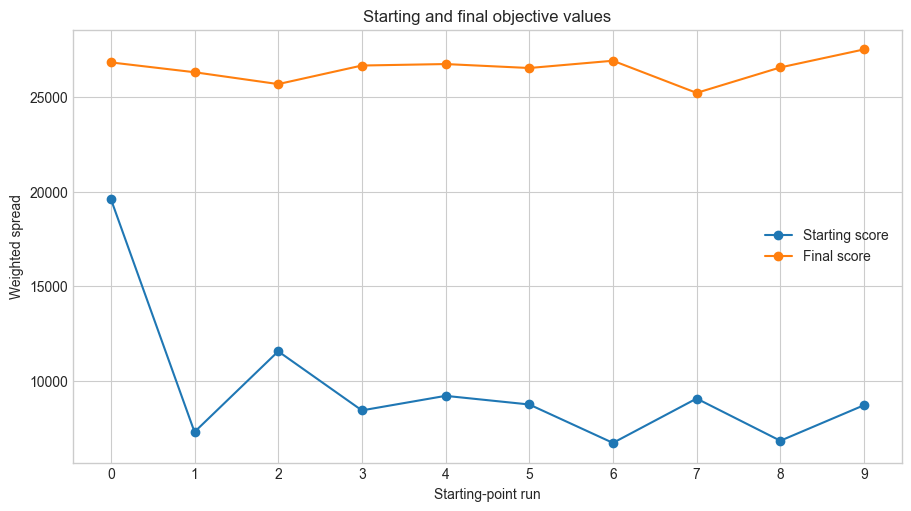

In [18]:
if not starting_point_summary.empty:
    if "STARTING_POINT_EXPERIMENT" not in globals() or STARTING_POINT_EXPERIMENT not in set(starting_point_summary["experiment_id"]):
        STARTING_POINT_EXPERIMENT = starting_point_summary.iloc[-1]["experiment_id"]
    selected_start_runs = starting_point_runs.loc[starting_point_runs["experiment_id"].eq(STARTING_POINT_EXPERIMENT)].sort_values("run_index").copy()
    selected_summary = starting_point_summary.loc[starting_point_summary["experiment_id"].eq(STARTING_POINT_EXPERIMENT)].iloc[0]
    display(Markdown(f"### Selected experiment: year={selected_summary['year']}, alpha={selected_summary['alpha']:g}, seed budget={selected_summary['seed_budget']}"))
    display(selected_start_runs[["run_index", "start_type", "start_spread", "finish_spread", "improvement_pct", "search_elapsed_seconds", "time_limit_reached"]])

    run_labels = selected_start_runs["run_index"].astype(str).tolist()
    fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
    axis.plot(run_labels, selected_start_runs["start_spread"], marker="o", label="Starting score")
    axis.plot(run_labels, selected_start_runs["finish_spread"], marker="o", label="Final score")
    axis.set(xlabel="Starting-point run", ylabel="Weighted spread", title="Starting and final objective values")
    axis.legend()
    plt.show()


,municipality_id,municipality_name,selected_runs,selection_frequency_pct
0,80002870774,COMUNE DI MATERA,10,100.000
1,2438750586,ROMA CAPITALE,10,100.000
2,1199250158,COMUNE DI MILANO,10,100.000
3,145920351,COMUNE DI REGGIO NELL'EMILIA,9,90.000
4,80015010723,COMUNE DI BARI,8,80.000
...,...,...,...,...
88,412270043,COMUNE DI CANALE,1,10.000
89,382650729,COMUNE DI BITONTO,1,10.000
90,355870221,COMUNE DI TRENTO,1,10.000
91,346630239,COMUNE DI VALEGGIO SUL MINCIO,1,10.000


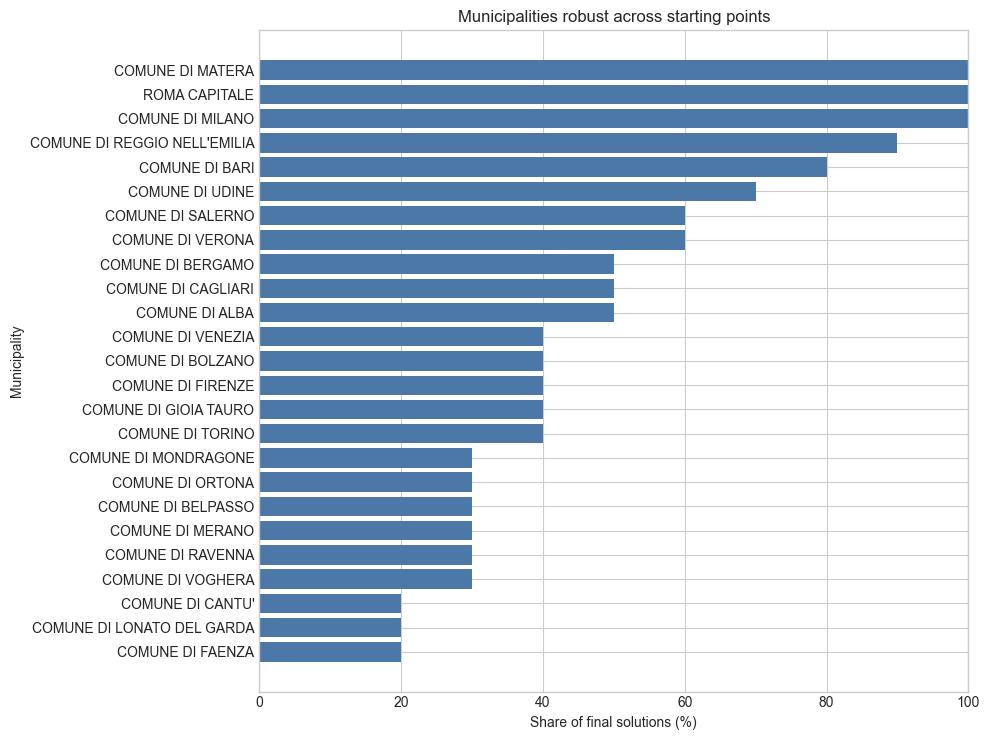

In [19]:
if not starting_point_summary.empty:
    selection_frequency = (
        selected_start_runs[["run_index", "finish_set"]]
        .explode("finish_set")
        .groupby("finish_set")["run_index"]
        .nunique()
        .rename("selected_runs")
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"finish_set": "municipality_id"})
    )
    selection_frequency["selection_frequency_pct"] = 100 * selection_frequency["selected_runs"] / len(selected_start_runs)
    selected_start_row = selected_start_runs.iloc[0]
    network_parameters = json.loads(selected_start_row["network_parameters"])
    start_config = ExperimentConfig(
        seed_budget=int(selected_start_row["seed_budget"]),
        alpha=float(selected_start_row["alpha"]),
        **network_parameters,
    )
    start_model = load_year_model(int(selected_summary["year"]), start_config)
    municipality_lookup = start_model["node_audit"].reset_index()[["municipality_id", "municipality_name"]]
    selection_frequency["municipality_id"] = selection_frequency["municipality_id"].astype(int)
    selection_frequency = selection_frequency.merge(municipality_lookup, on="municipality_id", how="left")
    display(selection_frequency[["municipality_id", "municipality_name", "selected_runs", "selection_frequency_pct"]])

    top_frequency = selection_frequency.head(25).sort_values("selection_frequency_pct")
    labels = top_frequency["municipality_name"].fillna(top_frequency["municipality_id"].astype(str))
    fig, axis = plt.subplots(figsize=(10, max(5, 0.3 * len(top_frequency))))
    axis.barh(labels, top_frequency["selection_frequency_pct"], color="#4C78A8")
    axis.set(xlabel="Share of final solutions (%)", ylabel="Municipality", title="Municipalities robust across starting points", xlim=(0, 100))
    plt.tight_layout()
    plt.show()


## ISTAT macro-area experiment

In [20]:
GEOGRAPHICAL_RESULTS_PATH = RESULTS_PATH.parent / "geographical_results.csv"
geographical_results = pd.DataFrame()

if not GEOGRAPHICAL_RESULTS_PATH.exists():
    print(f"No geographical results found at {GEOGRAPHICAL_RESULTS_PATH}.")
else:
    geographical_results = load_results(GEOGRAPHICAL_RESULTS_PATH)
    if "macro_area" not in geographical_results:
        raise ValueError("Geographical results must contain a macro_area column")

    graph_metadata = geographical_results["graph_metadata"].map(json.loads)
    geographical_results["nodes"] = graph_metadata.map(lambda value: value["nodes"])
    geographical_results["hyperedges"] = graph_metadata.map(lambda value: value["hyperedges"])
    geographical_results["incidences"] = graph_metadata.map(lambda value: value["incidences"])
    geographical_results["spread_gain"] = (
        geographical_results["finish_spread"] - geographical_results["start_spread"]
    )
    geographical_results["spread_gain_pct"] = 100 * (
        geographical_results["finish_spread"]
        / geographical_results["start_spread"]
        - 1
    )
    geographical_results["finish_spread_per_node"] = (
        geographical_results["finish_spread"] / geographical_results["nodes"]
    )
    display(
        geographical_results[[
            "year", "macro_area", "alpha", "seed_budget", "nodes", "hyperedges",
            "incidences", "start_spread", "finish_spread", "spread_gain_pct",
            "finish_spread_per_node",
        ]].sort_values(["year", "macro_area", "alpha", "seed_budget"])
    )


No geographical results found at /Users/matteobergamaschi/Desktop/rete_ipl_git/results/geographical_results.csv.


### Outcomes by macro-area

In [21]:
if not geographical_results.empty:
    GEO_YEAR = int(geographical_results["year"].max())
    available_alphas = sorted(geographical_results["alpha"].unique())
    available_budgets = sorted(geographical_results["seed_budget"].unique())
    GEO_ALPHA = 0.10 if 0.10 in available_alphas else available_alphas[0]
    GEO_SEED_BUDGET = 20 if 20 in available_budgets else available_budgets[0]

    geographical_comparison = geographical_results.loc[
        geographical_results["year"].eq(GEO_YEAR)
        & np.isclose(geographical_results["alpha"], GEO_ALPHA)
        & geographical_results["seed_budget"].eq(GEO_SEED_BUDGET)
    ].sort_values("macro_area")
    display(geographical_comparison[[
        "macro_area", "nodes", "hyperedges", "finish_spread",
        "finish_spread_per_node", "spread_gain_pct",
    ]])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    axes[0].bar(
        geographical_comparison["macro_area"],
        geographical_comparison["finish_spread_per_node"],
    )
    axes[0].set(
        title="Optimized spread per municipality",
        xlabel="ISTAT macro-area",
        ylabel="Finish spread / network nodes",
    )
    axes[1].bar(
        geographical_comparison["macro_area"],
        geographical_comparison["spread_gain_pct"],
        color="tab:orange",
    )
    axes[1].set(
        title="Optimization gain",
        xlabel="ISTAT macro-area",
        ylabel="Gain over starting seeds (%)",
    )
    for axis in axes:
        axis.tick_params(axis="x", rotation=30)
    fig.suptitle(
        f"ISTAT macro-area experiment — {GEO_YEAR}, alpha={GEO_ALPHA:g}, "
        f"k={GEO_SEED_BUDGET}"
    )
    plt.show()
